# Citation Link Prediction: From Tabular Baselines to Graph Neural Networks
**Authors: Alessio Carnevale, Manuel Cattoni, Carlo Schillaci**

## Executive Summary & Objectives
This notebook explores the task of **link prediction** for scientific papers: *For a pair of papers, predict if one will cite the other or not.*
The dataset is derived from the DBLP scientific papers dataset, featuring over 6.7 million papers. Originally in JSONL format, it has been transformed into a Parquet-based pipeline for efficient out-of-core processing using DuckDB and Polars.

### Domain Challenges
Working with scholarly data presents unique challenges:
- **Missing organizations & name variants**: These affect downstream identity mapping and collaboration features.
- **Venue normalization**: Venue prestige is one of the strongest signals in citation graphs.
- **Data Leakage**: Predicting citations requires careful temporal splitting and pair-based modeling to avoid leakage from global popularity metrics (e.g., total in-degree over the entire time span).

### Narrative of the Pipeline
Instead of immediately jumping to complex Graph Neural Networks (GNNs), this notebook frames the problem as an evolution of models:
1. **EDA & Preprocessing**: Ensuring high data quality, cleaning distributions, and plotting properties.
2. **Phase 1 (Flat Baselines)**: We build 3 standard tabular models (Random Forest, LightGBM, MLP) using basic features. 
3. **Phase 2 (Pair-Link Features)**: We revisit identical tabular architectures but feed them features constructed on *pairs of nodes* to model relation probabilities better.
4. **Phase 3 (Graph Convolutional Network - GCN)**: We finally train a node embedding model directly over the observed edges (using a message-passing GCN combined with Hard Negative Sampling for class imbalance) to capture the higher-order network topology.

## 1. Setup, Data Ingestion, and Infrastructure

The dataset consists of over 6.7 million academic paper records initially in JSONL format, stored as a Parquet file in AWS S3.
Because of the sheer scale of the data, pandas alone is insufficient. 

We utilize **DuckDB**, an in-process analytical database, as our primary query and processing engine. 
DuckDB allows us to execute complex feature engineering and aggregations directly on the out-of-core Parquet files via SQL, drastically reducing memory overhead

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from dotenv import load_dotenv
load_dotenv() 

PARQUET = "s3://data-project-supsi-bucket/data.parquet"
# PARQUET = "data.parquet"  # local import

In [4]:
# Configure S3 once
con = duckdb.connect(PARQUET)
con.sql("INSTALL httpfs; LOAD httpfs;")

# Peek at structure
con.sql(f"DESCRIBE SELECT * FROM read_parquet('{PARQUET}')").df()

,column_name,column_type,null,key,default,extra
0,id,VARCHAR,YES,None,None,None
1,title,VARCHAR,YES,None,None,None
2,abstract,VARCHAR,YES,None,None,None
3,keywords,VARCHAR[],YES,None,None,None
4,year,BIGINT,YES,None,None,None
5,authors,"STRUCT(id VARCHAR, ""name"" VARCHAR, org VARCHAR)[]",YES,None,None,None
6,references,VARCHAR[],YES,None,None,None
7,page_start,VARCHAR,YES,None,None,None
8,page_end,VARCHAR,YES,None,None,None
9,lang,VARCHAR,YES,None,None,None


In [ ]:
# --- Build papers once, reuse everywhere ---

# Ensure the httpfs extension is loaded
con.sql("INSTALL httpfs;")
con.sql("LOAD httpfs;")

# Increase timeout to 5 minutes (300000 milliseconds)
con.sql("SET http_timeout = 300000;")

# Enable retries for temporary network drops
con.sql("SET http_retries = 3;")
con.sql("SET http_retry_wait_ms = 1000;")

REBUILD_PAPERS = False  # set True only when you want to rebuild from S3

if REBUILD_PAPERS:
    con.sql("DROP TABLE IF EXISTS papers")

con.sql(f"""
CREATE TABLE IF NOT EXISTS papers AS
SELECT
    *,
    ARRAY_LENGTH(authors) AS n_authors,
    ARRAY_LENGTH(keywords) AS n_keywords,
    ARRAY_LENGTH("references") AS n_references,
    LENGTH(COALESCE(title, '')) AS title_len,
    LENGTH(COALESCE(abstract, '')) AS abstract_len,
    TRY_CAST(page_end AS BIGINT) - TRY_CAST(page_start AS BIGINT) AS page_count
FROM read_parquet('{PARQUET}')
""")

con.sql("SELECT COUNT(*) AS n_rows FROM papers").df()

,n_rows
0,6729828


In [ ]:
abstr = con.sql(f"""
SELECT abstract FROM papers
LIMIT 2
""").df()

abstr = np.array(abstr)

print(abstr[1:][0][0])

The UCI version of the Rand Message Handling System (MH) is discussed, including important extensions. MH is a powerful user agent which operates in the ARPA Internet and UUCP environments. In addition to the basic functions provided by a user agent, such as reading and sending mail, MH has several distinguishing characteristics which give the user additional message handling capabilities. In particular, MH provides mechanisms for organizing messages, tailoring its own behavior, and extending its functions. This document describes MH from several perspectives. Particular emphasis is given to: the MH user environment, advanced features of MH which have proven to be particularly useful for sophisticated users of electronic mail, MH's potential as a record manager, and MH as a part of a distributed mail environment. Although MH has been widely used since its creation in 1979, a discussion of its perspectives and functionality has not appeared in the open literature.


In [7]:
total = con.sql(f"""
    SELECT COUNT(*) AS total_papers
    FROM papers
""").df()


total = np.array(total)

print(f"Total number of papers: {total[0][0]}")

Total number of papers: 6729828


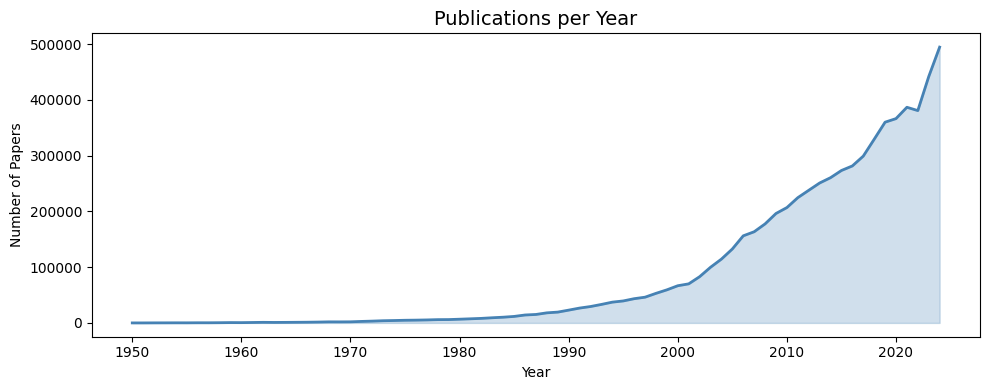

In [8]:
df_year = con.sql(f"""
    SELECT year, COUNT(*) AS papers
    FROM papers
    WHERE year BETWEEN 1950 AND 2024
    GROUP BY year
    ORDER BY year
""").df()
 
fig, ax = plt.subplots(figsize=(10,4))
ax.fill_between(df_year["year"], df_year["papers"], alpha=0.25, color="steelblue")
ax.plot(df_year["year"], df_year["papers"], color="steelblue", linewidth=2)
ax.set_title("Publications per Year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Papers")

plt.tight_layout()
plt.show()
 

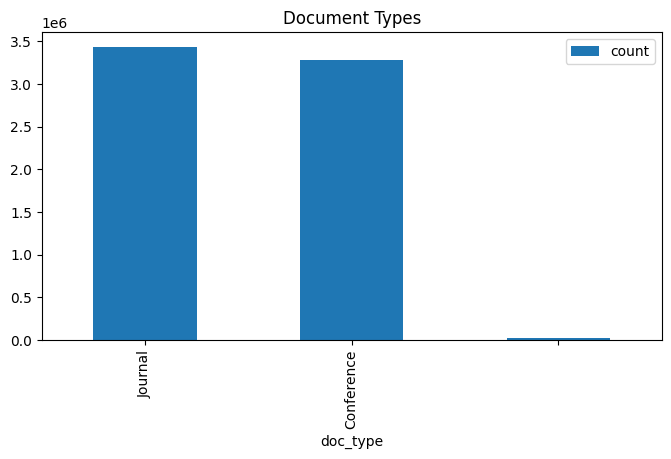

In [9]:
df = con.sql(f"""
    SELECT doc_type, COUNT(*) AS count
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE doc_type IS NOT NULL
    GROUP BY doc_type ORDER BY count DESC
""").df()

df.plot(kind="bar", x="doc_type", y="count", title="Document Types", figsize=(8,4))
plt.show()

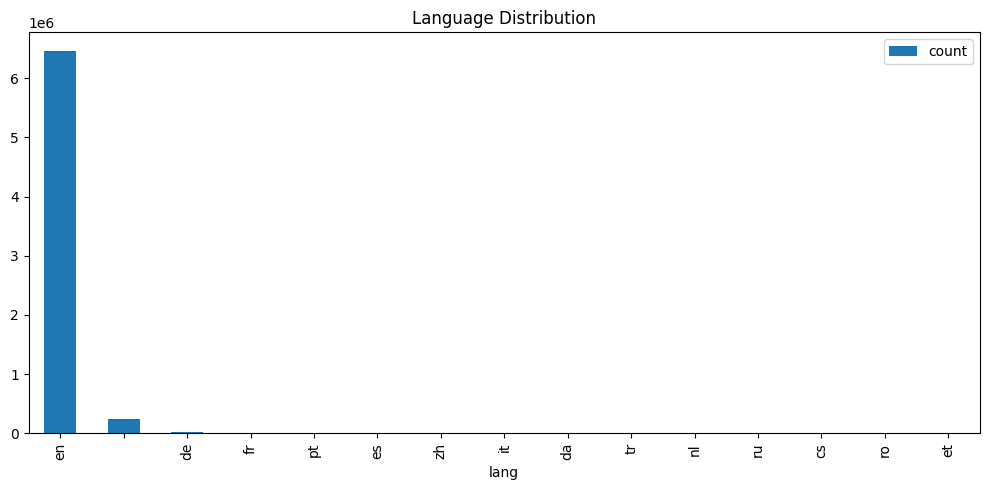

In [10]:
# Language distribution from parquet
df = con.sql(f"""
    SELECT lang, COUNT(*) AS count
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE lang IS NOT NULL
    GROUP BY lang 
    ORDER BY count DESC
    LIMIT 15
""").df()

df.plot(kind="bar", x="lang", y="count", title="Language Distribution", figsize=(10, 5))
plt.tight_layout()
plt.show()

## Citation Analysis

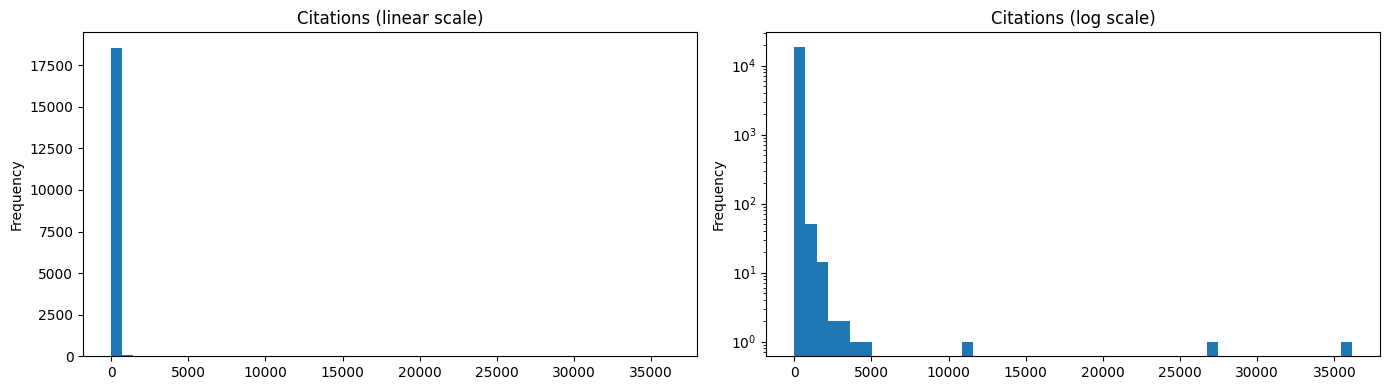

In [11]:
df = con.sql(f"""
    SELECT n_citation
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE n_citation IS NOT NULL AND n_citation > 0
    USING SAMPLE 20000
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["n_citation"].plot(kind="hist", bins=50, ax=axes[0], title="Citations (linear scale)")
df["n_citation"].apply(lambda x: x+1).plot(kind="hist", bins=50, logy=True, ax=axes[1], title="Citations (log scale)")
plt.tight_layout()
plt.show()

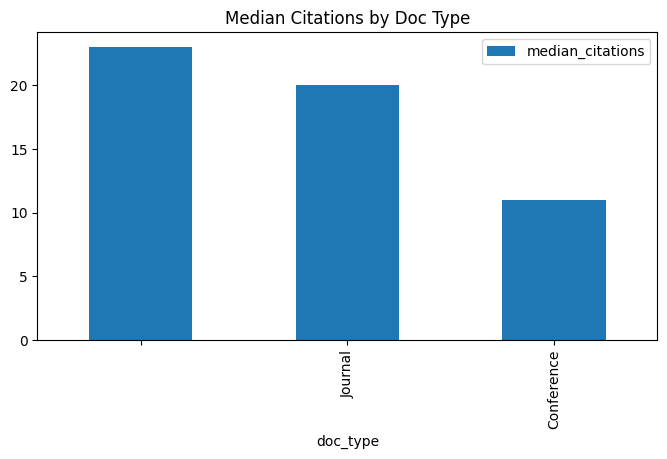

In [12]:
df = con.sql(f"""
    SELECT doc_type,
           COUNT(*) AS papers,
           AVG(n_citation) AS avg_citations,
           MEDIAN(n_citation) AS median_citations
    
    -- FROM papers         
    FROM read_parquet('{PARQUET}')
    WHERE doc_type IS NOT NULL AND n_citation IS NOT NULL
    GROUP BY doc_type ORDER BY median_citations DESC
""").df()

df.plot(kind="bar", x="doc_type", y="median_citations", title="Median Citations by Doc Type", figsize=(8,4))
plt.show()

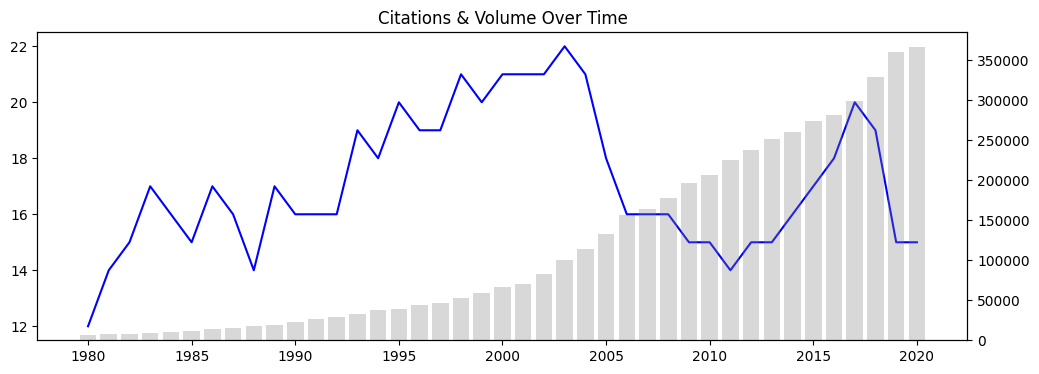

In [13]:
df = con.sql(f"""
    SELECT year,
           MEDIAN(n_citation) AS median_citations,
           COUNT(*) AS papers
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE year BETWEEN 1980 AND 2020 AND n_citation IS NOT NULL
    GROUP BY year ORDER BY year
""").df()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.plot(df["year"], df["median_citations"], color="blue", label="Median citations")
ax2.bar(df["year"], df["papers"], alpha=0.3, color="gray", label="Paper count")
ax1.set_title("Citations & Volume Over Time")
plt.show()

## Authors and Collaborations

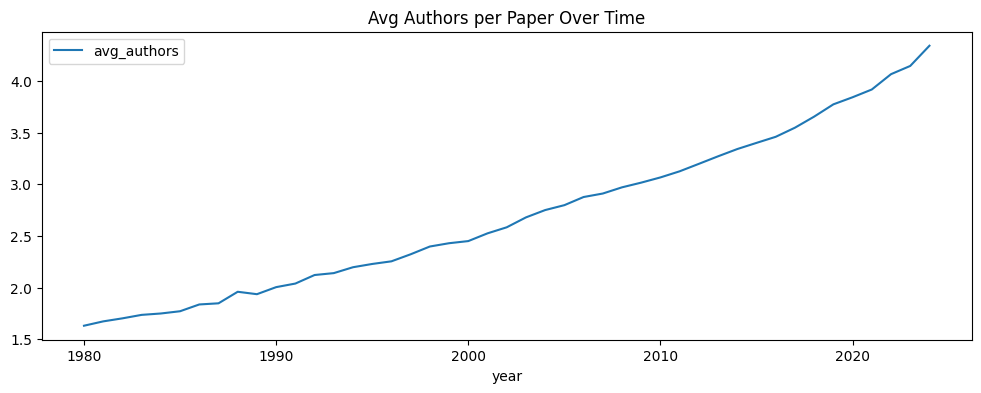

In [14]:
df = con.sql(f"""
    SELECT year,
           AVG(ARRAY_LENGTH(authors)) AS avg_authors
 -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE year BETWEEN 1980 AND 2024 AND authors IS NOT NULL
    GROUP BY year ORDER BY year
""").df()

df.plot(kind="line", x="year", y="avg_authors", title="Avg Authors per Paper Over Time", figsize=(12,4))
plt.show()

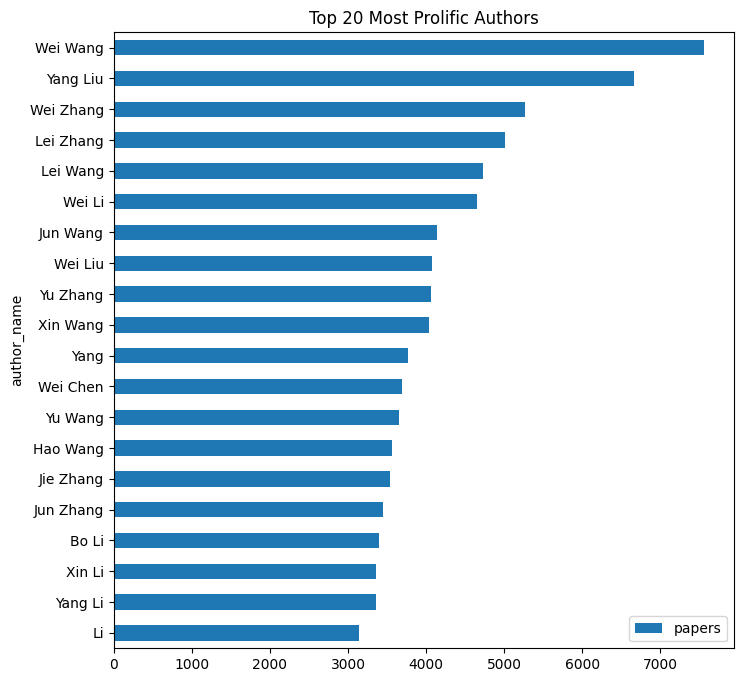

In [15]:
df = con.sql(f"""
    SELECT
        author.name AS author_name,
        COUNT(*) AS papers
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
    WHERE author.name IS NOT NULL
      AND author.name != ''
    GROUP BY 1
    ORDER BY papers DESC
    LIMIT 20
""").df()

df.plot(kind="barh", x="author_name", y="papers", title="Top 20 Most Prolific Authors", figsize=(8,8))
plt.gca().invert_yaxis()
plt.show()

## Keywords and Venues

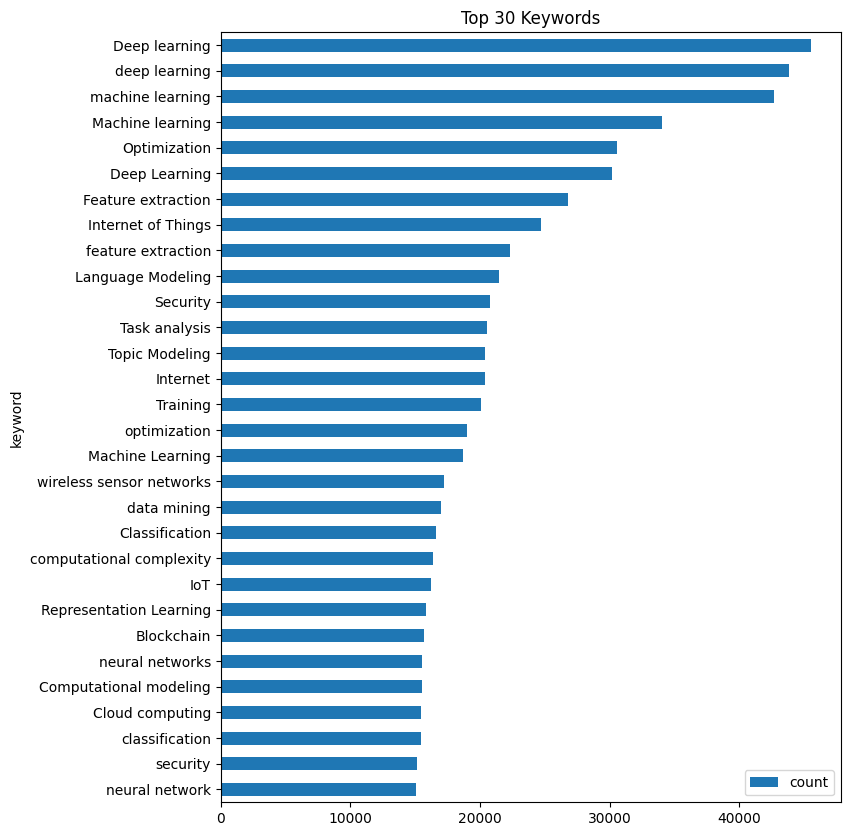

In [16]:
df = con.sql(f"""
    SELECT kw AS keyword, COUNT(*) AS count
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(keywords) AS t(kw)
    WHERE kw IS NOT NULL AND kw != ''
    GROUP BY kw
    ORDER BY count DESC
    LIMIT 30
""").df()

df.plot(kind="barh", x="keyword", y="count", title="Top 30 Keywords", figsize=(8,10))
plt.gca().invert_yaxis()
plt.show()

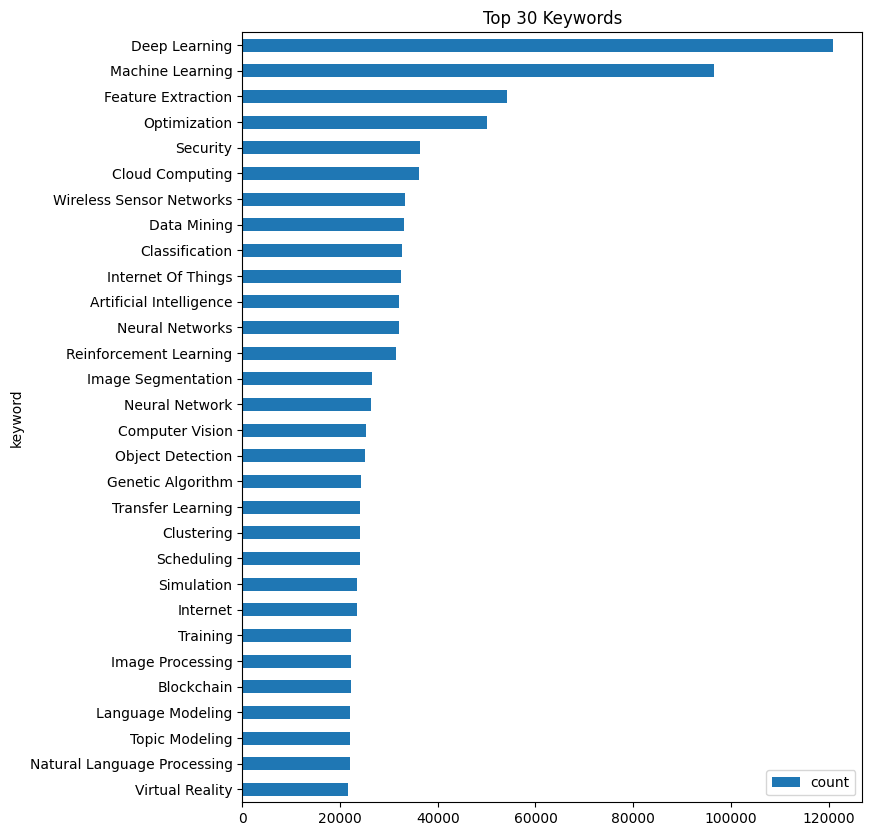

In [17]:
# merge identical keywords by case

def to_camel_case(s):
    return ' '.join(word.capitalize() for word in s.split())

raw = con.sql(f"""
    SELECT kw AS keyword
    FROM read_parquet('{PARQUET}')
    -- FROM papers
    CROSS JOIN
         UNNEST(keywords) AS t(kw)
    WHERE kw IS NOT NULL AND kw != ''
""").df()

raw['keyword'] = raw['keyword'].apply(to_camel_case)

df = (
    raw.groupby('keyword', as_index=False)
       .size()
       .rename(columns={'size': 'count'})
       .sort_values('count', ascending=False)
       .head(30)
)

df.plot(kind="barh", x="keyword", y="count", title="Top 30 Keywords", figsize=(8, 10))
plt.gca().invert_yaxis()
plt.show()

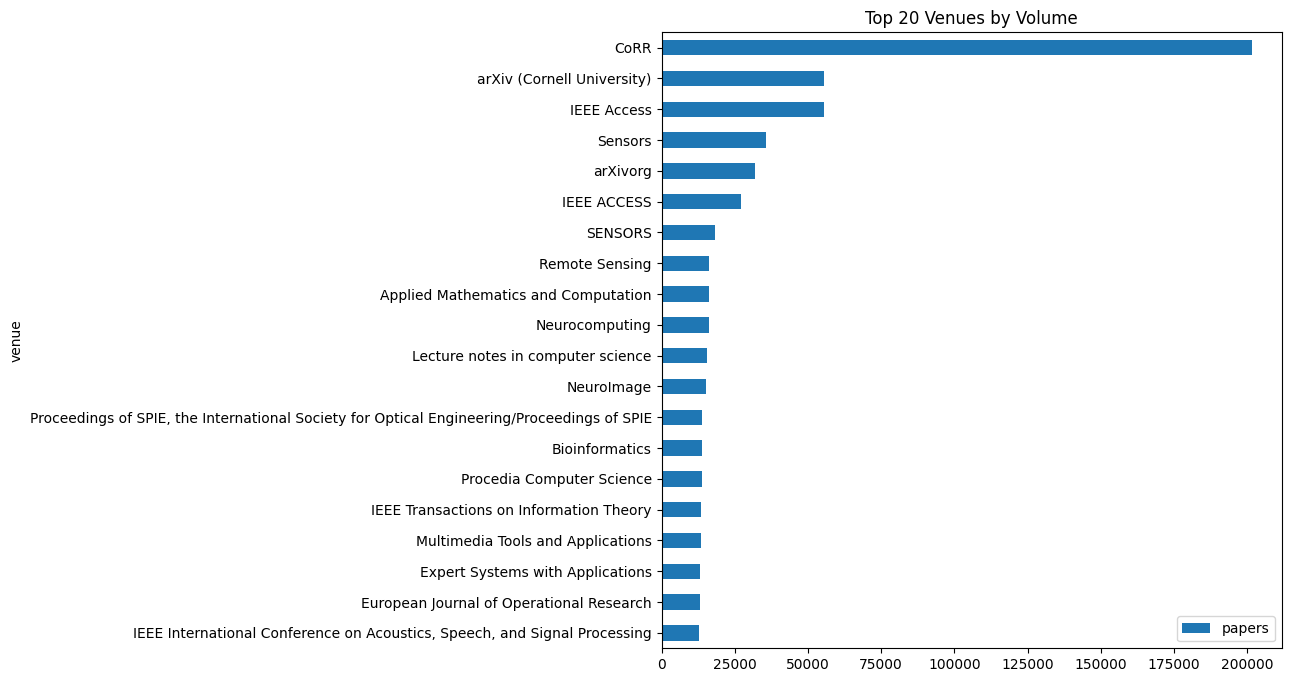

In [18]:
df = con.sql(f"""
    SELECT venue, COUNT(*) AS papers, MEDIAN(n_citation) AS median_citations
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE venue IS NOT NULL AND venue != ''
    GROUP BY venue
    ORDER BY papers DESC
    LIMIT 20
""").df()

df.plot(kind="barh", x="venue", y="papers", title="Top 20 Venues by Volume", figsize=(8,8))
plt.gca().invert_yaxis()
plt.show()

##  Missingness

In [19]:
# Missingness report (null + empty string/array) from parquet
missing_df = con.sql(f"""
WITH base AS (
    SELECT
        COUNT(*)::DOUBLE AS total_rows,
        SUM(CASE WHEN id IS NULL OR TRIM(COALESCE(id, '')) = '' THEN 1 ELSE 0 END) AS miss_id,
        SUM(CASE WHEN title IS NULL OR TRIM(COALESCE(title, '')) = '' THEN 1 ELSE 0 END) AS miss_title,
        SUM(CASE WHEN abstract IS NULL OR TRIM(COALESCE(abstract, '')) = '' THEN 1 ELSE 0 END) AS miss_abstract,
        SUM(CASE WHEN keywords IS NULL OR ARRAY_LENGTH(keywords) = 0 THEN 1 ELSE 0 END) AS miss_keywords,
        SUM(CASE WHEN year IS NULL THEN 1 ELSE 0 END) AS miss_year,
        SUM(CASE WHEN authors IS NULL OR ARRAY_LENGTH(authors) = 0 THEN 1 ELSE 0 END) AS miss_authors,
        SUM(CASE WHEN "references" IS NULL OR ARRAY_LENGTH("references") = 0 THEN 1 ELSE 0 END) AS miss_references,
        SUM(CASE WHEN lang IS NULL OR TRIM(COALESCE(lang, '')) = '' THEN 1 ELSE 0 END) AS miss_lang,
        SUM(CASE WHEN venue IS NULL OR TRIM(COALESCE(venue, '')) = '' THEN 1 ELSE 0 END) AS miss_venue,
        SUM(CASE WHEN doc_type IS NULL OR TRIM(COALESCE(doc_type, '')) = '' THEN 1 ELSE 0 END) AS miss_doc_type,
        SUM(CASE WHEN doi IS NULL OR TRIM(COALESCE(doi, '')) = '' THEN 1 ELSE 0 END) AS miss_doi,
        SUM(CASE WHEN page_start IS NULL OR TRIM(COALESCE(page_start, '')) = '' THEN 1 ELSE 0 END) AS miss_page_start,
        SUM(CASE WHEN page_end IS NULL OR TRIM(COALESCE(page_end, '')) = '' THEN 1 ELSE 0 END) AS miss_page_end,
        SUM(CASE WHEN n_citation IS NULL THEN 1 ELSE 0 END) AS miss_n_citation
    FROM read_parquet('{PARQUET}')
    -- FROM papers
)
SELECT * FROM (
    SELECT 'id' AS feature,        100.0 * miss_id / total_rows AS missing_pct FROM base
    UNION ALL SELECT 'title',      100.0 * miss_title / total_rows FROM base
    UNION ALL SELECT 'abstract',   100.0 * miss_abstract / total_rows FROM base
    UNION ALL SELECT 'keywords',   100.0 * miss_keywords / total_rows FROM base
    UNION ALL SELECT 'year',       100.0 * miss_year / total_rows FROM base
    UNION ALL SELECT 'authors',    100.0 * miss_authors / total_rows FROM base
    UNION ALL SELECT 'references', 100.0 * miss_references / total_rows FROM base
    UNION ALL SELECT 'lang',       100.0 * miss_lang / total_rows FROM base
    UNION ALL SELECT 'venue',      100.0 * miss_venue / total_rows FROM base
    UNION ALL SELECT 'doc_type',   100.0 * miss_doc_type / total_rows FROM base
    UNION ALL SELECT 'doi',        100.0 * miss_doi / total_rows FROM base
    UNION ALL SELECT 'page_start', 100.0 * miss_page_start / total_rows FROM base
    UNION ALL SELECT 'page_end',   100.0 * miss_page_end / total_rows FROM base
    UNION ALL SELECT 'n_citation', 100.0 * miss_n_citation / total_rows FROM base
)
ORDER BY missing_pct DESC
""").df()

display(missing_df)

,feature,missing_pct
0,page_end,27.977907
1,page_start,26.567752
2,keywords,16.196907
3,references,15.643282
4,doi,8.945102
5,abstract,5.377448
6,lang,3.604579
7,venue,0.667016
8,doc_type,0.312697
9,authors,0.000045


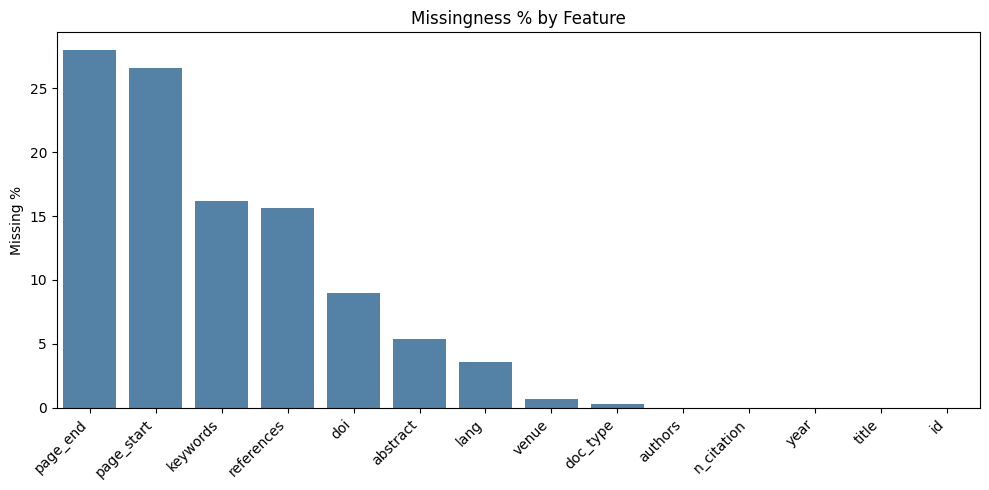

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(data=missing_df, x="feature", y="missing_pct", color="steelblue")
plt.title("Missingness % by Feature")
plt.ylabel("Missing %")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Data quality

In [22]:
df = con.sql(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(title) AS has_title,
        COUNT(abstract) AS has_abstract,
        COUNT(year) AS has_year,
        COUNT(doi) AS has_doi,
        COUNT(n_citation) AS has_citations,
        COUNT(venue) AS has_venue
    -- FROM papers
    FROM read_parquet('{PARQUET}')
""").df()

print(df.T)

                     0
total          6729828
has_title      6729828
has_abstract   6729828
has_year       6729828
has_doi        6729828
has_citations  6729828
has_venue      6703333


## What this next check does (author.id / author.org missingness)
It explodes the authors array so each author mention in each paper is one row.
Then it counts how often author.id is missing, how often author.org is missing, and how often both are missing.
Output is a table with counts and percentages.
How to read it:

- High miss_author_id_pct means many authors cannot be uniquely tracked across papers.
- High miss_author_org_pct means affiliation-based features may be weak/noisy.
- High miss_both_pct means severe metadata incompleteness for author-level modeling.

In [23]:
# Missing author.id and author.org rates (explicit)
missing_author_fields_df = con.sql(f"""
WITH a AS (
    SELECT
        author.name AS author_name,
        author.id   AS author_id,
        author.org  AS author_org
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
),
base AS (
    SELECT
        COUNT(*)::DOUBLE AS total_author_mentions,
        SUM(CASE WHEN author_id IS NULL OR TRIM(COALESCE(author_id, '')) = '' THEN 1 ELSE 0 END) AS miss_author_id,
        SUM(CASE WHEN author_org IS NULL OR TRIM(COALESCE(author_org, '')) = '' THEN 1 ELSE 0 END) AS miss_author_org,
        SUM(CASE WHEN (author_id IS NULL OR TRIM(COALESCE(author_id, '')) = '')
                  AND (author_org IS NULL OR TRIM(COALESCE(author_org, '')) = '')
                 THEN 1 ELSE 0 END) AS miss_both
    FROM a
)
SELECT
    total_author_mentions,
    miss_author_id,
    ROUND(100.0 * miss_author_id / NULLIF(total_author_mentions, 0), 4) AS miss_author_id_pct,
    miss_author_org,
    ROUND(100.0 * miss_author_org / NULLIF(total_author_mentions, 0), 4) AS miss_author_org_pct,
    miss_both,
    ROUND(100.0 * miss_both / NULLIF(total_author_mentions, 0), 4) AS miss_both_pct
FROM base;
""").df()
display(missing_author_fields_df)

,total_author_mentions,miss_author_id,miss_author_id_pct,miss_author_org,miss_author_org_pct,miss_both,miss_both_pct
0,22998013.0,2284412.0,9.9331,4208990.0,18.3015,802063.0,3.4875


author.id missing ≈ 9.94% author.org missing ≈ 18.30% both missing ≈ 3.48%

Missingness is too high for author.org; dropping would bias data

We should create missingness features. booleans like: has_author_id, has_author_org, and pair-level both_have_org.

Use author.id as primary identity, normalized name only as fallback.

With this class rate, train on sampled negatives (e.g., 1:5 or 1:10 pos:neg) and evaluate with PR-AUC / Recall@K, not accuracy.

## What this next check does (author-name variation / normalization)
It normalizes names (lowercase, remove punctuation, collapse spaces).
It groups by normalized form and finds cases where many raw spellings map to the same normalized author string.
Output shows likely spelling/format variants (for example accents, dots, extra spaces, initials).
How to read it:

- n_raw_variants = number of distinct original spellings for the same normalized name.
- mentions = total occurrences of that normalized name.
- raw_variants lists the observed spellings with counts.
Important:

This is a heuristic quality check, not true entity resolution.
Same normalized name can still refer to different people (homonyms).

In [ ]:
# Author-name variation / normalization checks 

con.sql("SET preserve_insertion_order = false;")
con.sql("SET threads = 4;")

name_variation_df = con.sql(f"""
WITH flat AS (
    SELECT TRIM(author.name) AS raw_name
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
    WHERE author.name IS NOT NULL AND TRIM(author.name) <> ''
),
norm_counts AS (
    SELECT
        LOWER(
            REGEXP_REPLACE(
                REGEXP_REPLACE(raw_name, '[^[:alnum:] ]', ' ', 'g'),
                '\\s+', ' ', 'g'
            )
        ) AS normalized_name,
        raw_name,
        COUNT(*) AS raw_mentions
    FROM flat
    GROUP BY 1, 2
),
name_stats AS (
    SELECT
        normalized_name,
        SUM(raw_mentions) AS mentions,
        COUNT(*) AS n_raw_variants
    FROM norm_counts
    GROUP BY normalized_name
    HAVING COUNT(*) > 1
    ORDER BY n_raw_variants DESC, mentions DESC
    LIMIT 30
)
SELECT
    s.normalized_name,
    s.mentions,
    s.n_raw_variants,
    STRING_AGG(
        nc.raw_name || ' (' || CAST(nc.raw_mentions AS VARCHAR) || ')',
        ' | '
        ORDER BY nc.raw_mentions DESC, nc.raw_name
    ) AS raw_variants
FROM name_stats s
JOIN norm_counts nc USING (normalized_name)
GROUP BY s.normalized_name, s.mentions, s.n_raw_variants
ORDER BY s.n_raw_variants DESC, s.mentions DESC;
""").df()

display(name_variation_df)

,normalized_name,mentions,n_raw_variants,raw_variants
0,,2018.0,1909,刘炜 (5) | 王作英 (4) | : (3) | 于炯 (3) | 刘伟 (3) | 刘...
1,c c jay kuo,605.0,14,C. -C. Jay Kuo (372) | C.-C. Jay Kuo (107) | C...
2,yang liu,6701.0,10,Yang Liu (6662) | Yang Liu (14) | Yang Liu (1...
3,xuemin sherman shen,901.0,10,Xuemin (Sherman) Shen (815) | Xuemin Sherman S...
4,wil m p van der aalst,645.0,10,Wil M. P. van der Aalst (598) | Wil M. P. Van ...
5,alex sandy pentland,98.0,10,Alex 'Sandy' Pentland (35) | Alex (Sandy) Pent...
6,max q h meng,491.0,9,Max Q. -H. Meng (251) | Max Q-H Meng (107) | M...
7,florian floyd mueller,202.0,9,Florian 'Floyd' Mueller (167) | Florian Floyd ...
8,willem jan van den heuvel,153.0,9,Willem-Jan van den Heuvel (115) | Willem-Jan V...
9,y h taguchi,37.0,9,Y-h. Taguchi (16) | Y-h Taguchi (8) | Y-H. Tag...


The name-variation table is for finding likely spelling variants; treat it as cleaning support, not truth.

We should build canonical text forms (lowercase, trim, punctuation/space cleanup, unicode normalization). Keep a small manual alias map for top recurring variants from the variation output

## What this next check does (temporal consistency of affiliations)
- It keeps authors with a valid author.id and year.
- For each author across time, it counts how many distinct non-empty organizations appear.
- It returns authors with more than one organization over their timeline.

How to read it:

- n_distinct_orgs > 1 can mean real career moves or inconsistent/dirty org strings.
- timeline_rows and year range (first_year, last_year) give context on how broad the timeline is.
- Rows at the top are the strongest candidates for manual cleaning rules (org normalization, alias mapping).

In [25]:
# Temporal consistency of author affiliations
author_org_temporal_df = con.sql(f"""
WITH author_timeline AS (
    SELECT
        author.id AS author_id,
        MIN(TRIM(author.name)) AS sample_name,
        year,
        NULLIF(TRIM(author.org), '') AS org
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    CROSS JOIN UNNEST(authors) AS t(author)
    WHERE author.id IS NOT NULL AND TRIM(author.id) <> ''
      AND year IS NOT NULL
    GROUP BY author.id, year, NULLIF(TRIM(author.org), '')
)
 ,agg AS (
    SELECT
        author_id,
        MIN(sample_name) AS sample_name,
        COUNT(*) AS timeline_rows,
        COUNT(DISTINCT org) FILTER (WHERE org IS NOT NULL) AS n_distinct_orgs,
        MIN(year) AS first_year,
        MAX(year) AS last_year
    FROM author_timeline
    GROUP BY author_id
)
SELECT
    author_id,
    sample_name,
    timeline_rows,
    n_distinct_orgs,
    first_year,
    last_year
FROM agg
WHERE n_distinct_orgs > 1
ORDER BY n_distinct_orgs DESC, timeline_rows DESC
LIMIT 30;
""").df()

display(author_org_temporal_df)

,author_id,sample_name,timeline_rows,n_distinct_orgs,first_year,last_year
0,53f6615fdabfae8dcd35b276,JIAO Li-cheng,929,599,1998,2025
1,542c458bdabfae2b4e1fb0c8,H Jin,903,537,1997,2025
2,53f48c1fdabfaea7cd1ce3f8,D. Tao,744,511,2004,2025
3,53f445bcdabfaee4dc7ce5dc,Alouini Mohamed-Slim,880,496,1997,2025
4,53f48ce5dabfaea7cd1d0893,Li Xuelong,659,441,1994,2025
5,5625051945cedb339856ec92,A Abraham,609,406,1998,2025
6,5429fd93dabfae61d494cf5d,G Wen,759,404,1990,2025
7,53f7ffb0dabfae90ec136659,N NAVAB,644,373,1989,2025
8,53f45044dabfaedf435f34cb,Benini Luca,741,371,1994,2025
9,54084ac2dabfae450f408e17,A Alimi,474,363,1993,2025


for example, the first row shows that:

The same author ID appears a lot in the dataset (786 author-year-org records). Across those records, there are 510 different organization strings. This is far too high to be realistic as true job changes, so it mostly indicates: noisy/inconsistent author.org text, variants of the same institution, possible mixed identities in the source.

What to do with it:

Keep author.id as the stable identity key. Normalize author.org (case, punctuation, spacing, abbreviations). Build an org alias map for top repeated variants. For modeling, use robust org features (has_org, normalized org match) rather than raw org string equality.

# Data Cleaning

In [26]:
import re
import unicodedata

def normalize_text(value):
    if value is None:
        return ""
    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

try:
    con.create_function("normalize_text", normalize_text, [str], str)
except Exception:
    pass

Author canonicalization layer: 'author.id' is the primary key, and normalized name is the fallback.

In [27]:
con.sql(f"""
CREATE OR REPLACE TABLE author_mentions_clean AS
SELECT
    p.id AS paper_id,
    p.year,
    CASE
        WHEN a.author.id IS NOT NULL AND TRIM(a.author.id) <> ''
            THEN TRIM(a.author.id)
        ELSE 'name:' || normalize_text(a.author.name)
    END AS author_key,
    TRIM(a.author.id) AS author_id_raw,
    normalize_text(a.author.name) AS author_name_norm,
    TRIM(a.author.name) AS author_name_raw,
    normalize_text(a.author.org) AS author_org_norm
FROM read_parquet('{PARQUET}') p
-- FROM papers p
CROSS JOIN UNNEST(p.authors) AS a(author)
WHERE a.author.name IS NOT NULL
  AND TRIM(a.author.name) <> '';
""")

In [28]:
con.sql("""
CREATE OR REPLACE TABLE author_name_canonical AS
WITH counts AS (
    SELECT
        author_key,
        author_name_norm,
        author_name_raw,
        COUNT(*) AS n_mentions
    FROM author_mentions_clean
    GROUP BY 1, 2, 3
),
ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY author_key
            ORDER BY n_mentions DESC, LENGTH(author_name_raw) DESC, author_name_raw
        ) AS rn
    FROM counts
)
SELECT
    author_key,
    author_name_raw AS canonical_author_name,
    author_name_norm AS canonical_author_name_norm,
    n_mentions
FROM ranked
WHERE rn = 1;
""")

In [29]:
display(con.sql("SELECT * FROM author_name_canonical LIMIT 10").df())

,author_key,canonical_author_name,canonical_author_name_norm,n_mentions
0,5487b409dabfae8a11fb3ca7,R UNBEHAUEN,r unbehauen,18
1,5487b8d3dabfaed7b5fa3220,Boleslaw K. Szymanski,boleslaw k szymanski,226
2,5487f79edabfaed7b5fa33bf,Oded Maler,oded maler,63
3,548839abdabfae8a11fb414e,Marcio Mello,marcio mello,1
4,5488694edabfaed7b5fa3829,T. G. Sitharam,t g sitharam,2
5,54892dc9dabfae8a11fb444d,Wallace J. Hopp,wallace j hopp,1
6,54896daedabfae9b40134a30,Michael S. Branicky,michael s branicky,23
7,54898a0bdabfaed7b5fa3ccd,O SHIRAKAWA,o shirakawa,1
8,5489a6f0dabfae9b40134bef,Tatsuo Kurihara,tatsuo kurihara,1
9,5489bbc0dabfaed7b5fa3df1,Pierre Pontarotti,pierre pontarotti,4


Use the resolved author-table cells below. The old raw-name join should not be used.

In [30]:
con.sql("""
CREATE OR REPLACE TABLE paper_authors AS
SELECT
    am.paper_id AS id,
    am.author_key,
    ac.canonical_author_name AS author_name,
    am.author_org_norm
FROM author_mentions_clean am
LEFT JOIN author_name_canonical ac
    ON am.author_key = ac.author_key;
""")

con.sql("""
CREATE OR REPLACE TABLE author_stats AS
SELECT
    author_key,
    author_name,
    COUNT(*) AS author_papers,
    MEDIAN(p.n_citation) AS author_median_citations,
    AVG(p.n_citation) AS author_avg_citations,
    MAX(p.n_citation) AS author_max_citations
FROM paper_authors pa
JOIN papers p
    ON pa.id = p.id
WHERE p.year <= 2020
GROUP BY author_key, author_name;
""")

con.sql(f"""
CREATE OR REPLACE TABLE features_author AS
SELECT
    p.id,
    COUNT(DISTINCT pa.author_key) AS n_authors,
    COALESCE(AVG(a.author_avg_citations), 0) AS avg_author_citations,
    COALESCE(MAX(a.author_max_citations), 0) AS max_author_citations,
    CASE WHEN COUNT(DISTINCT pa.author_key) > 1 THEN 1 ELSE 0 END AS multi_authored
FROM read_parquet('{PARQUET}') p
-- FROM papers p
LEFT JOIN paper_authors pa
    ON p.id = pa.id
LEFT JOIN author_stats a
    ON pa.author_key = a.author_key
GROUP BY p.id;
""")

display(con.sql("SELECT * FROM paper_authors LIMIT 10").df())

,id,author_key,author_name,author_org_norm
0,5390881720f70186a0d809f3,53f4b5b9dabfaeb22f576e1b,Miguel Castro,mit cambridge ma
1,5390882d20f70186a0d8dbb6,5405d6acdabfae450f3d84f3,Pavel A. Pevzner,university of california at san diego usa
2,5390882d20f70186a0d8de96,53f469c1dabfaee4dc85b911,Hartmut Ritter,freie universitat berlin 14195 berlin
3,5390893e20f70186a0d93040,6623837a2173360a69136fa2,Roberto F. Santos Filho,None
4,5390893e20f70186a0d9366d,560374d345cedb3396194b14,Robert Bridson,stanford univ sccm gates 2b stanford ca 94305 usa
5,539089ab20f70186a0d94ff1,53f46079dabfaedf4362ef02,Shiby Thomas,ibm almaden research center san jose usa
6,539089ab20f70186a0d956d8,53f45ad8dabfaedf4361c25b,Nikos C. Tsourveloudis,department of production engineering and manag...
7,539089ab20f70186a0d962ac,53f44cefdabfaee43ec97c38,David J. Allcroft,department of mathematics and statistics unive...
8,539089ab20f70186a0d96c34,53f45b2adabfaedd74e3fbe9,Tom Mens,None
9,539089ab20f70186a0d972c6,53f46350dabfaeee22a4830c,Dieter Rautenbach,None


In [31]:
con.sql(f"""
CREATE OR REPLACE TABLE papers_clean AS
WITH base AS (
    SELECT
        p.*,
        normalize_text(p.title) AS title_norm,
        normalize_text(p.abstract) AS abstract_norm,
        normalize_text(p.venue) AS venue_norm,
        normalize_text(p.doc_type) AS doc_type_norm,
        CASE
            WHEN p.id IS NULL OR TRIM(p.id) = '' THEN
                'paper_' || md5(
                    COALESCE(p.title, '') || '|' ||
                    COALESCE(p.abstract, '') || '|' ||
                    COALESCE(CAST(p.year AS VARCHAR), '') || '|' ||
                    COALESCE(p.venue, '')
                )
            ELSE TRIM(p.id)
        END AS id_clean,
        CASE WHEN p.id IS NULL OR TRIM(p.id) = '' THEN 1 ELSE 0 END AS was_missing_id
    -- FROM papers p
    FROM read_parquet('{PARQUET}') p
)
SELECT
    id_clean AS id,
    NULLIF(title_norm, '') AS title,
    NULLIF(abstract_norm, '') AS abstract,
    year,
    authors,
    keywords,
    "references",
    NULLIF(venue_norm, '') AS venue,
    CASE
        WHEN regexp_matches(COALESCE(venue_norm, ''), '(conference|symposium|workshop|proceedings|meeting)') THEN 'conference'
        WHEN regexp_matches(COALESCE(venue_norm, ''), '(journal|transactions|letters)') THEN 'journal'
        WHEN regexp_matches(COALESCE(venue_norm, ''), '(book|chapter|lecture notes)') THEN 'book'
        WHEN doc_type_norm IN ('article', 'journal article') THEN 'journal'
        WHEN doc_type_norm IN ('inproceedings', 'conference paper', 'conference') THEN 'conference'
        WHEN doc_type_norm = '' THEN 'unknown'
        ELSE doc_type_norm
    END AS doc_type,
    doi,
    page_start,
    page_end,
    n_citation,
    ARRAY_LENGTH(authors) AS n_authors,
    ARRAY_LENGTH(keywords) AS n_keywords,
    ARRAY_LENGTH("references") AS n_references,
    LENGTH(COALESCE(NULLIF(title_norm, ''), '')) AS title_len,
    LENGTH(COALESCE(NULLIF(abstract_norm, ''), '')) AS abstract_len,
    TRY_CAST(page_end AS BIGINT) - TRY_CAST(page_start AS BIGINT) AS page_count,
    was_missing_id
FROM base;
""")

con.sql("CREATE OR REPLACE TABLE papers AS SELECT * FROM papers_clean")

display(con.sql("SELECT id, title, venue, doc_type, was_missing_id FROM papers LIMIT 5").df())

,id,title,venue,doc_type,was_missing_id
0,555041b645ce0a409eb3d4ad,shift outliers in linear inference,journal of multivariate analysis,journal,0
1,555041bb45ce0a409eb3d6fb,applying machine learning to analyse teachers ...,international journal of advanced intelligence...,journal,0
2,555041db45ce0a409eb3e285,cyclic codes over the ring z p u v u 2 v 2 u v...,finite fields and their applications,journal,0
3,555041ea45ce0a409eb3e882,algorithms for multiplayer multicommodity flow...,central european journal of operations research,journal,0
4,555041f545ce0a409eb3ef14,a synthesis framework for robust gain scheduli...,automatica,journal,0


# Target Focused Exploration

In [ ]:
# Class balance: citation links (positive) vs non-links (negative)

# Assumptions:
## - `papers.id` is the paper identifier
## - `papers.references` is an array of cited paper ids
## - we only keep references that point to ids present in `papers`

balance_df = con.sql(f"""
WITH ids AS (
    SELECT DISTINCT id
    -- FROM papers
    FROM read_parquet('{PARQUET}')
    WHERE id IS NOT NULL AND TRIM(id) <> ''
)
 ,pos AS (
    SELECT DISTINCT
        p.id AS src_id,
        ref AS dst_id
    -- FROM papers p
    FROM read_parquet('{PARQUET}') p
    CROSS JOIN UNNEST(p."references") AS t(ref)
    INNER JOIN ids i ON i.id = ref
    WHERE p.id IS NOT NULL
      AND TRIM(p.id) <> ''
      AND ref IS NOT NULL
      AND TRIM(ref) <> ''
      AND p.id <> ref
)
 ,counts AS (
    SELECT
        (SELECT COUNT(*) FROM ids) AS n_nodes,
        (SELECT COUNT(*) FROM pos) AS n_positive_links
)
SELECT
    n_nodes,
    n_positive_links,
    (n_nodes * (n_nodes - 1) - n_positive_links) AS n_non_links,
    ROUND(100.0 * n_positive_links / NULLIF(n_nodes * (n_nodes - 1), 0), 6) AS positive_rate_pct,
    ROUND(100.0 * (n_nodes * (n_nodes - 1) - n_positive_links) / NULLIF(n_nodes * (n_nodes - 1), 0), 6) AS non_link_rate_pct
FROM counts;
""").df()

display(balance_df)

,n_nodes,n_positive_links,n_non_links,positive_rate_pct,non_link_rate_pct
0,6729828,73640521,45290504539235,0.000163,99.999837


In [33]:
# ratio as "1 positive : X negatives"
pos = float(balance_df.loc[0, "n_positive_links"])
neg = float(balance_df.loc[0, "n_non_links"])
print(f"Positive link rate: {balance_df.loc[0, 'positive_rate_pct']:.6f}%")
print(f"Non-link rate: {balance_df.loc[0, 'non_link_rate_pct']:.6f}%")

Positive link rate: 0.000163%
Non-link rate: 99.999837%


# Pair Level Analysis

### Correlation Matrix

In [34]:
# df = con.sql(f"""
#     SELECT
#         ARRAY_LENGTH(authors) AS n_authors,
#         ARRAY_LENGTH(keywords) AS n_keywords,
#         ARRAY_LENGTH("references") AS n_references,
#         TRY_CAST(page_end AS INT) - TRY_CAST(page_start AS INT) AS page_count,
#         LENGTH(abstract) AS abstract_length,
#         n_citation
#     FROM read_parquet('{PARQUET}')
#     WHERE n_citation IS NOT NULL
#     USING SAMPLE 20000
# """).df().dropna()

# sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
# plt.title("Feature Correlations")
# plt.tight_layout()
# plt.show()

There are no correlated features in the original dataset, only a little correlation between n_references and abstract_lenght.

# Feature Selection

### 1 TEXT-BASED FEATURES

Features da **titolo** e **abstract** per catturare complessità e specificità:
- `title_word_count` → Lunghezza titolo
- `abstract_word_count` → Lunghezza abstract  
- `title_complexity` → Media parole nel titolo (linguaggio tecnico)
- `abstract_complexity` → Media parole nell'abstract
- `has_numbers_*` → Presenza numeri (specificità)

In [35]:
text_sql = """
CREATE OR REPLACE TABLE features_text AS
SELECT 
    id,
    CASE WHEN title IS NULL THEN 0 
         ELSE ARRAY_LENGTH(STRING_SPLIT(TRIM(title), ' '))
    END AS title_word_count,
    
    CASE WHEN abstract IS NULL THEN 0 
         ELSE ARRAY_LENGTH(STRING_SPLIT(TRIM(abstract), ' '))
    END AS abstract_word_count,
    
    CASE WHEN LENGTH(COALESCE(abstract, '')) = 0 THEN 0
         ELSE CAST(LENGTH(COALESCE(title, '')) AS FLOAT) / LENGTH(COALESCE(abstract, ''))
    END AS title_abstract_ratio,
    
    CASE WHEN title IS NULL OR ARRAY_LENGTH(STRING_SPLIT(TRIM(title), ' ')) = 0 THEN 0
         ELSE CAST(LENGTH(COALESCE(title, '')) AS FLOAT) / ARRAY_LENGTH(STRING_SPLIT(TRIM(title), ' '))
    END AS title_complexity,
    
    CASE WHEN abstract IS NULL OR ARRAY_LENGTH(STRING_SPLIT(TRIM(abstract), ' ')) = 0 THEN 0
         ELSE CAST(LENGTH(COALESCE(abstract, '')) AS FLOAT) / ARRAY_LENGTH(STRING_SPLIT(TRIM(abstract), ' '))
    END AS abstract_complexity,
    
    CASE WHEN title ~ '[0-9]' THEN 1 ELSE 0 END AS has_numbers_in_title,
    CASE WHEN abstract ~ '[0-9]' THEN 1 ELSE 0 END AS has_numbers_in_abstract
    
FROM read_parquet('{PARQUET}')
""".format(PARQUET=PARQUET)

con.sql(text_sql)
print("DONE")

DONE


### 2️ AUTHOR-BASED FEATURES

Features che catturano **reputazione** e **collaborazione**:
- `n_authors` → Numero autori  
- `first_author_avg_citations` → Media cit. primo autore (star lead researcher)
- `avg_author_citations` → Media cit. aggregato autori
- `max_author_citations` → Max cit. tra autori (presenza di star)
- `multi_authored` → Flag collaborazione (>1 autore)

In [36]:
# Compute author statistics
author_stats_sql = """
CREATE OR REPLACE TABLE author_stats AS
SELECT 
    author.name AS author_name,
    COUNT(*) AS author_papers,
    MEDIAN(n_citation) AS author_median_citations,
    AVG(n_citation) AS author_avg_citations,
    MAX(n_citation) AS author_max_citations
FROM read_parquet('{PARQUET}') 
CROSS JOIN UNNEST(authors) AS t(author)
WHERE author.name IS NOT NULL AND author.name != '' AND year <= 2020
GROUP BY author.name
""".format(PARQUET=PARQUET)

con.sql(author_stats_sql)
print("Author statistics DONE")

# Create paper-author links
paper_author_sql = """
CREATE OR REPLACE TABLE paper_authors AS
SELECT 
    p.id,
    author.name AS author_name
FROM read_parquet('{PARQUET}') AS p
CROSS JOIN UNNEST(p.authors) AS t(author)
WHERE author.name IS NOT NULL AND author.name != ''
""".format(PARQUET=PARQUET)

con.sql(paper_author_sql)
print("Paper-author links DONE")

# Join with author stats
author_features_sql = """
CREATE OR REPLACE TABLE features_author AS
SELECT 
    p.id,
    ARRAY_LENGTH(p.authors) AS n_authors,
    
    COALESCE(AVG(a.author_avg_citations), 0) AS avg_author_citations,
    COALESCE(MAX(a.author_max_citations), 0) AS max_author_citations,
    
    CASE WHEN ARRAY_LENGTH(p.authors) > 1 THEN 1 ELSE 0 END AS multi_authored

FROM read_parquet('{PARQUET}') AS p
LEFT JOIN paper_authors pa ON p.id = pa.id
LEFT JOIN author_stats a ON pa.author_name = a.author_name
GROUP BY p.id, ARRAY_LENGTH(p.authors)
""".format(PARQUET=PARQUET)

con.sql(author_features_sql)
print("AUTHOR-BASED FEATURES DONE")

Author statistics DONE
Paper-author links DONE
AUTHOR-BASED FEATURES DONE


### 3 NETWORK & REFERENCE FEATURES

- `n_references` → Numero di riferimenti citati  
- `references_author_ratio` → Riferimenti per autore
- `citation_richness` → Densità riferimenti rispetto abstract
- `has_high_ref_count` → Flag papers che sono review/comprehensive (>50 ref)

In [37]:
network_sql = """
CREATE OR REPLACE TABLE features_network AS
SELECT 
    id,
    ARRAY_LENGTH("references") AS n_references,
    
    CASE WHEN ARRAY_LENGTH(authors) = 0 THEN 0
         ELSE CAST(ARRAY_LENGTH("references") AS FLOAT) / ARRAY_LENGTH(authors)
    END AS references_author_ratio,
    
    CASE WHEN LENGTH(abstract) = 0 THEN 0
         ELSE CAST(ARRAY_LENGTH("references") AS FLOAT) / (LENGTH(abstract) / 100.0)
    END AS citation_richness,
    
    CASE WHEN ARRAY_LENGTH("references") > 50 THEN 1 ELSE 0 END AS has_high_ref_count

FROM read_parquet('{PARQUET}')
""".format(PARQUET=PARQUET)

con.sql(network_sql)
print("NETWORK & REFERENCE FEATURES DONE")

NETWORK & REFERENCE FEATURES DONE


### 4 TEMPORAL FEATURES

Features che catturano **recency** e **stagionalità**:
- `years_since_publication` → Anni dalla pubblicazione (non usare lineare!)
- `publication_era` → Era storica (pre-2000, 2000-2009, 2010-2019, 2020+)
- `decade` → Decennio della pubblicazione
- `is_recent` → Flag se pubblicato negli ultimi 5 anni

In [38]:
temporal_sql = """
CREATE OR REPLACE TABLE features_temporal AS
SELECT 
    id,
    year,
    (2024 - year) AS years_since_publication,
    
    CASE 
        WHEN year < 2000 THEN 'pre-2000'
        WHEN year < 2010 THEN '2000-2009'
        WHEN year < 2020 THEN '2010-2019'
        ELSE '2020+'
    END AS publication_era,
    
    CAST(year / 10 * 10 AS INT) AS decade,
    
    CASE WHEN year >= 2019 THEN 1 ELSE 0 END AS is_recent

FROM read_parquet('{PARQUET}')
WHERE year IS NOT NULL
""".format(PARQUET=PARQUET)

con.sql(temporal_sql)
print("TEMPORAL FEATURES DONE")

TEMPORAL FEATURES DONE


### 5 QUALITY & IMPACT FEATURES

Features che rappresentano **qualità e impatto** normalizzati nel tempo:
- `citation_per_year` → Velocità accumulo citazioni (normalizzato per recency)  
- `is_highly_cited_for_year` → Flag se sopra mediana dell'anno
- `impact_score` → Composito: (cit/years × ln(peers per year)) **BEST predictor**

In [39]:
# Compute year statistics for normalization
con.sql("""
CREATE OR REPLACE TABLE year_citation_stats AS
SELECT 
    year,
    MEDIAN(n_citation) AS median_citations_per_year,
    AVG(n_citation) AS avg_citations_per_year,
    COUNT(*) AS papers_per_year
FROM read_parquet('{PARQUET}')
WHERE year IS NOT NULL AND n_citation IS NOT NULL
GROUP BY year
""".format(PARQUET=PARQUET))

quality_sql = """
CREATE OR REPLACE TABLE features_quality AS
SELECT 
    p.id,
    p.year,
    p.n_citation,
    
    CASE 
        WHEN (2024 - p.year) = 0 THEN CAST(p.n_citation AS FLOAT)
        WHEN p.n_citation = 0 THEN 0.0
        ELSE CAST(p.n_citation AS FLOAT) / CAST((2024 - p.year) AS FLOAT)
    END AS citation_per_year,
    
    CASE 
        WHEN p.n_citation >= COALESCE(ycs.median_citations_per_year, 0) THEN 1 
        ELSE 0 
    END AS is_highly_cited_for_year,
    
    (CAST(p.n_citation AS FLOAT) / CAST((2024 - p.year + 1) AS FLOAT)) * 
    (1 + LN(CAST(COALESCE(ycs.papers_per_year, 1) AS FLOAT))) AS impact_score
    
FROM read_parquet('{PARQUET}') AS p
LEFT JOIN year_citation_stats AS ycs ON p.year = ycs.year
WHERE p.n_citation IS NOT NULL
""".format(PARQUET=PARQUET)

con.sql(quality_sql)
print("QUALITY & IMPACT FEATURES DONE")

QUALITY & IMPACT FEATURES DONE


### 6 VENUE & DOMAIN FEATURES

Features che catturano **prestigio del venue** e **accessibility**:
- `venue_median_citations` → Prestigi proxy del venue (STRONGEST PREDICTOR)
- `venue_volume` → Numero papers nel venue (importance marker)
- `is_top_venue` → Flag se venue è nei top 50
- `is_english` → Flag lingua inglese (global reach)
- `venue_tier` → Ordinale categorico (elite → high → medium → low)

In [40]:
# Compute venue statistics
venue_stats_sql = """
CREATE OR REPLACE TABLE venue_stats AS
SELECT 
    venue,
    COUNT(*) AS venue_papers,
    MEDIAN(n_citation) AS venue_median_citations,
    AVG(n_citation) AS venue_avg_citations
FROM read_parquet('{PARQUET}')
WHERE venue IS NOT NULL AND venue != '' AND n_citation IS NOT NULL AND year <= 2020
GROUP BY venue
""".format(PARQUET=PARQUET)

con.sql(venue_stats_sql)

# Get top 50 venues
con.sql("CREATE OR REPLACE TABLE top_venues AS SELECT venue FROM venue_stats ORDER BY venue_median_citations DESC LIMIT 50")

# Create venue features
venue_features_sql = """
CREATE OR REPLACE TABLE features_venue AS
SELECT 
    p.id,
    p.venue,
    p.lang,
    
    COALESCE(vs.venue_median_citations, 0) AS venue_median_citations,
    COALESCE(vs.venue_papers, 0) AS venue_volume,
    
    CASE WHEN p.venue IN (SELECT venue FROM top_venues) THEN 1 ELSE 0 END AS is_top_venue,
    
    CASE WHEN UPPER(p.lang) IN ('EN', 'ENGLISH') THEN 1 ELSE 0 END AS is_english,
    
    CASE 
        WHEN COALESCE(vs.venue_median_citations, 0) > 100 THEN 'elite'
        WHEN COALESCE(vs.venue_median_citations, 0) > 50 THEN 'high'
        WHEN COALESCE(vs.venue_median_citations, 0) > 10 THEN 'medium'
        ELSE 'low'
    END AS venue_tier

FROM read_parquet('{PARQUET}') AS p
LEFT JOIN venue_stats AS vs ON p.venue = vs.venue
""".format(PARQUET=PARQUET)

con.sql(venue_features_sql)
print("VENUE & DOMAIN FEATURES DONE")

VENUE & DOMAIN FEATURES DONE


### 7 GRAPH-BASED FEATURES (Network Topology)

To capture the structural importance of papers within the citation network, we compute global graph metrics using `NetworkX`. 
To strictly prevent **data leakage**, we build the graph using only historical citation data (published in or before 2020), mirroring the approach used for venue prestige.

We extract three core graph-based features to fulfill the structural feature requirement:
- `pagerank`: Measures a paper's importance based on the quantity and quality of its incoming citations.
- `hub_score`: Identifies "Hubs" (e.g., comprehensive review papers) that cite many authoritative sources.
- `authority_score`: Identifies "Authorities" (highly influential core papers) that are cited by many hubs.

In [41]:
import networkx as nx
import pandas as pd

print("1. Extracting historical edges for the citation graph...")
edges_df = con.sql("""
    SELECT p.id AS src_id, ref AS dst_id
    FROM papers p
    CROSS JOIN UNNEST(p."references") AS t(ref)
    WHERE p.year <= 2020 
      AND ref IS NOT NULL 
      AND ref != ''
""").df()

print("2. Building the NetworkX DiGraph...")
G = nx.DiGraph()
G.add_edges_from(edges_df[['src_id', 'dst_id']].values)
print(f"Graph created: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

print("3. Computing PageRank, HITS, in/out degree (this might take a minute)...")
pagerank_scores = nx.pagerank(G)
hubs, authorities = nx.hits(G, max_iter=200, tol=1e-06)
in_degree_map  = dict(G.in_degree())
out_degree_map = dict(G.out_degree())

print("4. Saving graph features to DuckDB...")
graph_features_df = pd.DataFrame({
    'id':              list(G.nodes()),
    'pagerank':        [pagerank_scores.get(n, 0.0) for n in G.nodes()],
    'hub_score':       [hubs.get(n, 0.0)            for n in G.nodes()],
    'authority_score': [authorities.get(n, 0.0)     for n in G.nodes()],
    'in_degree':       [in_degree_map.get(n, 0)     for n in G.nodes()],
    'out_degree':      [out_degree_map.get(n, 0)    for n in G.nodes()],
})

con.register("graph_features_temp", graph_features_df)
con.sql("""
    CREATE OR REPLACE TABLE features_graph AS 
    SELECT * FROM graph_features_temp
""")
print("DONE! 'features_graph' table created successfully.")

# 5. Build lookup dict for pair-level feature construction
graph_feat_lookup = {
    row.id: {
        "pagerank":        row.pagerank,
        "hub_score":       row.hub_score,
        "authority_score": row.authority_score,
        "in_degree":       row.in_degree,
        "out_degree":      row.out_degree,
    }
    for row in graph_features_df.itertuples(index=False)
}
_default_graph = {"pagerank": 0.0, "hub_score": 0.0, "authority_score": 0.0, "in_degree": 0, "out_degree": 0}
print(f"Graph lookup ready for {len(graph_feat_lookup):,} papers")

1. Extracting historical edges for the citation graph...
2. Building the NetworkX DiGraph...
Graph created: 4,463,204 nodes, 46,237,465 edges
3. Computing PageRank, HITS, in/out degree (this might take a minute)...
4. Saving graph features to DuckDB...
DONE! 'features_graph' table created successfully.
Graph lookup ready for 4,463,204 papers


###  CONSOLIDATE: Master Features Table

In [ ]:
TABLE_NAME = "papers_with_features"

master_sql = f"""
CREATE OR REPLACE TABLE {TABLE_NAME} AS
SELECT 
    p.id,
    p.title,
    p.references,       
    p.year,
    p.n_citation AS target_variable,
    
    -- Text features
    ft.title_word_count,
    ft.abstract_word_count,
    ft.title_abstract_ratio,
    ft.title_complexity,
    ft.abstract_complexity,
    ft.has_numbers_in_title,
    ft.has_numbers_in_abstract,
    
    -- Author features
    fa.n_authors,
    fa.avg_author_citations,
    fa.max_author_citations,
    fa.multi_authored,
    
    -- Network features
    fn.n_references,
    fn.references_author_ratio,
    fn.citation_richness,
    fn.has_high_ref_count,
    
    -- Temporal features
    ft2.years_since_publication,
    ft2.publication_era,
    ft2.decade,
    ft2.is_recent,
    
    -- Quality features
    fq.citation_per_year,
    fq.is_highly_cited_for_year,
    fq.impact_score,
    
    -- Venue features
    fv.venue,
    fv.venue_median_citations,
    fv.venue_volume,
    fv.is_top_venue,
    fv.is_english,
    fv.venue_tier,
    
    -- Graph features
    COALESCE(fg.pagerank, 0.0) AS pagerank,
    COALESCE(fg.hub_score, 0.0) AS hub_score,
    COALESCE(fg.authority_score, 0.0) AS authority_score

FROM read_parquet('{PARQUET}') AS p
LEFT JOIN features_text ft ON p.id = ft.id
LEFT JOIN features_author fa ON p.id = fa.id
LEFT JOIN features_network fn ON p.id = fn.id
LEFT JOIN features_temporal ft2 ON p.id = ft2.id
LEFT JOIN features_quality fq ON p.id = fq.id
LEFT JOIN features_venue fv ON p.id = fv.id
LEFT JOIN features_graph fg ON p.id = fg.id

WHERE p.n_citation IS NOT NULL
"""

con.sql(master_sql)

# Check
row_count = con.sql(f"SELECT COUNT(*) FROM {TABLE_NAME}").df().iloc[0, 0]
col_count = len(con.sql(f"SELECT * FROM {TABLE_NAME} LIMIT 1").df().columns)

print(f"\nDONE MASTER FEATURES TABLE CREATED!")
print(f"   • Rows: {row_count:,} papers")
print(f"   • Columns: {col_count} features + metadata")

# Save parquet with DuckDB 
con.sql(f"COPY (SELECT * FROM {TABLE_NAME}) TO '{TABLE_NAME}.parquet' (FORMAT PARQUET)")
print(f"   • Saved: {TABLE_NAME}.parquet")


DONE MASTER FEATURES TABLE CREATED!
   • Rows: 6,729,828 papers
   • Columns: 36 features + metadata
   • Saved: papers_with_features.parquet


##  CORRELATION ANALYSIS WITH n_citations AS TARGET

Loaded 46,651 papers for analysis

TOP 15 MOST CORRELATED FEATURES WITH CITATIONS (SPEARMAN):
                Feature  Correlation
           n_references     0.520943
      citation_richness     0.470476
references_author_ratio     0.462539
    abstract_word_count     0.181859
   title_abstract_ratio    -0.160633
    abstract_complexity     0.097775
             is_english     0.095880
       title_complexity     0.085791
              n_authors     0.081291
years_since_publication     0.070009
       title_word_count    -0.040408


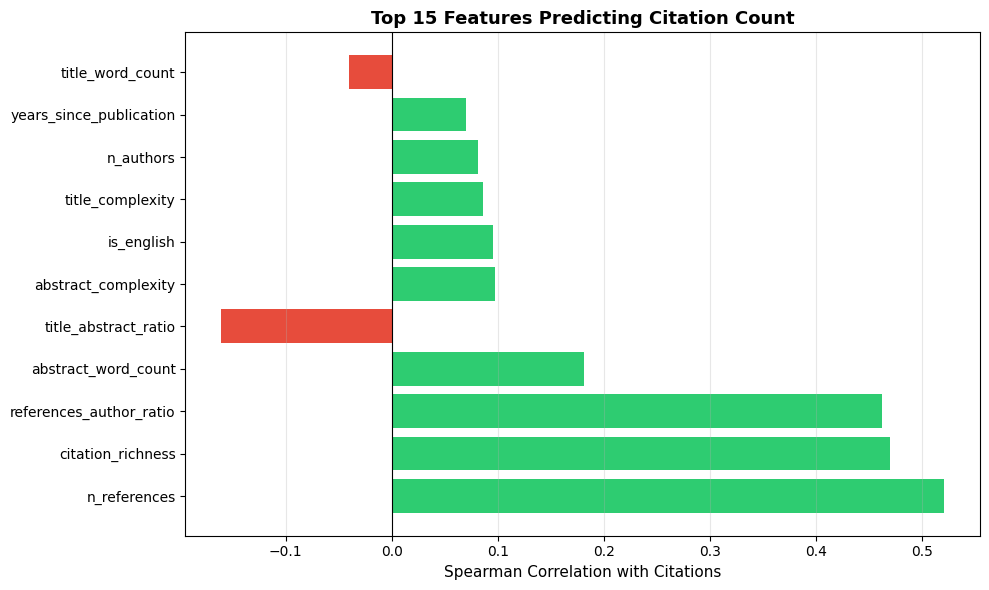


 FEATURE CORRELATION SUMMARY:
   Strong predictors (|corr| > 0.4): 3
   Moderate predictors (0.2 < |corr| <= 0.4): 0
   Weak predictors (|corr| <= 0.2): 8


In [ ]:
# Load features into pandas for correlation analysis
df_features = con.sql("""
SELECT *
FROM papers_with_features
USING SAMPLE 50000
""").df()

# Filter where target > 0
df_features = df_features[df_features['target_variable'] > 0]

print(f"Loaded {len(df_features):,} papers for analysis")

# Add graph features 
numeric_features = [
    'title_word_count', 'abstract_word_count', 'title_abstract_ratio',
    'title_complexity', 'abstract_complexity',
    'n_authors',
    'n_references', 'references_author_ratio', 'citation_richness',
    'years_since_publication', 
    'is_english',
]

# Compute correlations
correlations = {}
for feat in numeric_features:
    if feat in df_features.columns:
        # Add spearman method for outliers 
        corr = df_features[[feat, 'target_variable']].corr(method='spearman').iloc[0, 1]
        correlations[feat] = corr

# Create dataframe and sort
corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
corr_df = corr_df.sort_values('Correlation', key=abs, ascending=False)

print("\nTOP 15 MOST CORRELATED FEATURES WITH CITATIONS (SPEARMAN):")
print(corr_df.head(15).to_string(index=False))

# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 6))
top_corr = corr_df.head(15)
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_corr['Correlation']]
bars = ax.barh(range(len(top_corr)), top_corr['Correlation'], color=colors)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['Feature'], fontsize=10)
ax.set_xlabel('Spearman Correlation with Citations', fontsize=11)
ax.set_title('Top 15 Features Predicting Citation Count', fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance summary
print("\n FEATURE CORRELATION SUMMARY:")
print(f"   Strong predictors (|corr| > 0.4): {len(corr_df[abs(corr_df['Correlation']) > 0.4])}")
print(f"   Moderate predictors (0.2 < |corr| <= 0.4): {len(corr_df[(abs(corr_df['Correlation']) > 0.2) & (abs(corr_df['Correlation']) <= 0.4)])}")
print(f"   Weak predictors (|corr| <= 0.2): {len(corr_df[abs(corr_df['Correlation']) <= 0.2])}")

##  FEATURE INTERACTIONS & SEGMENTATION

 VENUE TIER ANALYSIS
           target_variable                         citation_per_year  \
                     count    mean median      std              mean   
venue_tier                                                             
elite                  229  418.21  144.0  1721.26         55.310001   
high                  1771  135.21   52.0   443.44         17.250000   
low                  14067   16.35    8.0   129.36          4.560000   
medium               30584   39.95   22.0   290.94          6.350000   

           n_references  
                   mean  
venue_tier               
elite             29.69  
high              20.08  
low                8.09  
medium            12.88  


C:\Users\Alessio\AppData\Local\Temp\ipykernel_29168\3719595087.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features_sorted, x='venue_tier', y='target_variable', ax=axes[0], palette='Set2')
C:\Users\Alessio\AppData\Local\Temp\ipykernel_29168\3719595087.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_features_sorted, x='venue_tier', y='citation_per_year', ax=axes[1], palette='Set3')


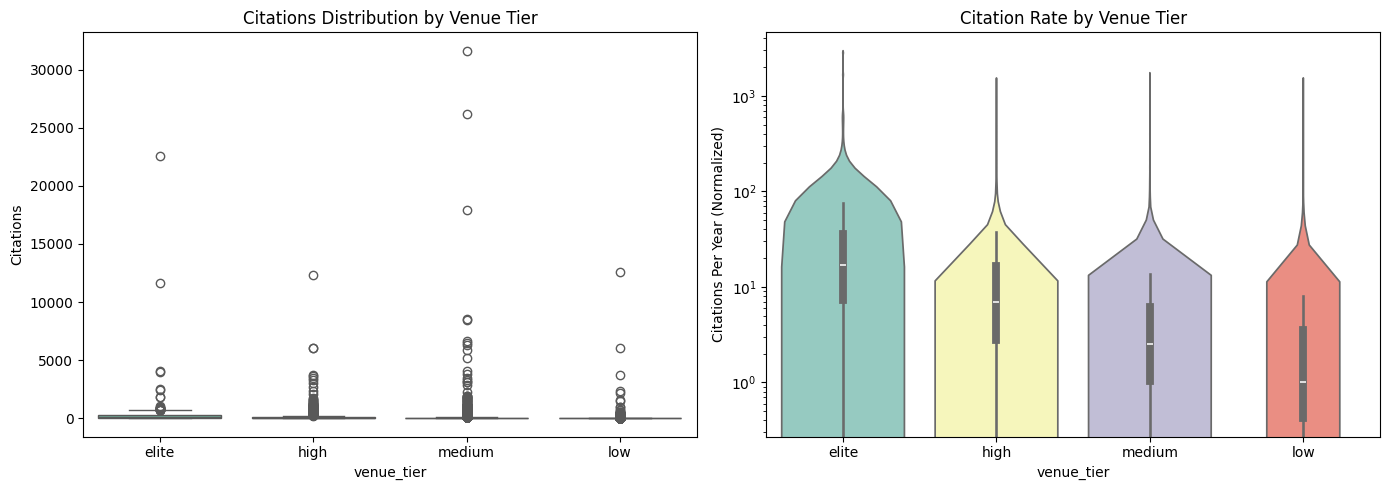


👥 AUTHOR REPUTATION TIERS
            target_variable               n_authors
                      count   mean median      mean
author_tier                                        
Emerging                765   3.39    3.0      1.99
Mid-Career             1735   9.05    8.0      2.32
Established           10772  17.79   14.0      2.71
Star                  31945  42.04   20.0      3.75


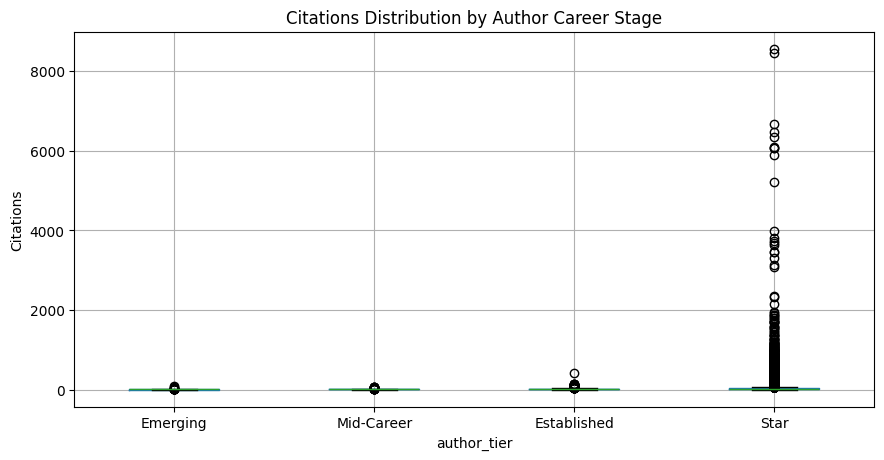


TEMPORAL TRENDS
                target_variable               citation_per_year
                          count   mean median              mean
publication_era                                                
2000-2009                  9007  55.38   19.0              3.05
2010-2019                 19743  35.71   17.0              4.41
2020+                     13961  23.28   15.0             12.85
pre-2000                   3940  65.58   20.0              1.98


C:\Users\Alessio\AppData\Local\Temp\ipykernel_29168\3719595087.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp, x='publication_era', y='target_variable', ax=ax1, palette='Set1')
C:\Users\Alessio\AppData\Local\Temp\ipykernel_29168\3719595087.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_temp_norm, x='publication_era', y='citation_per_year', ax=ax2, palette='Set2')


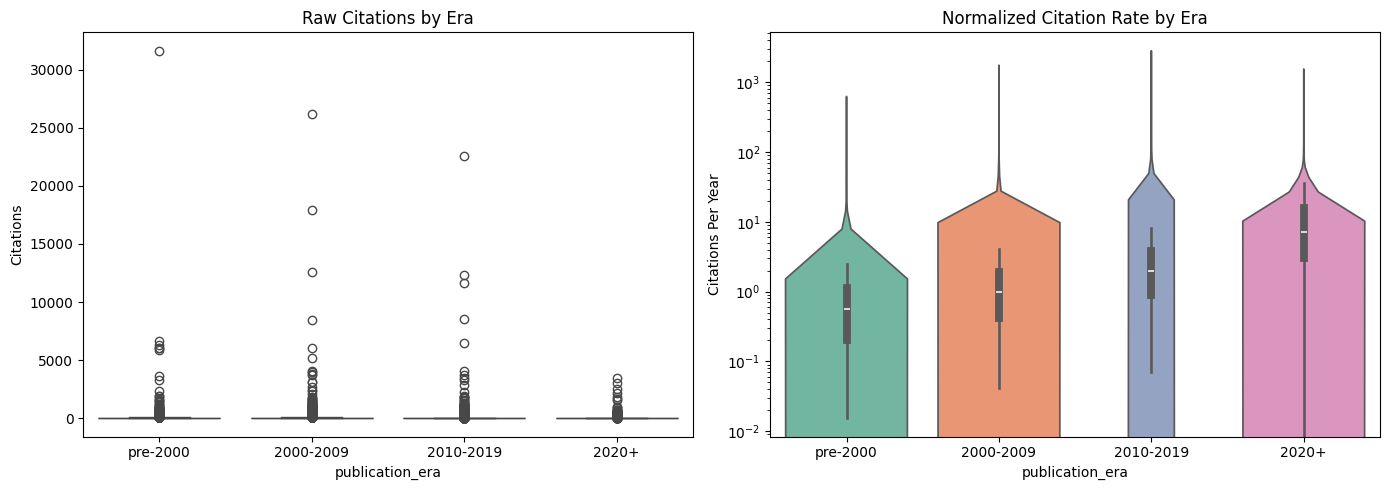


 VENUE x AUTHOR INTERACTION
                        count   mean
venue_tier author_tier              
elite      Mid-Career       1    1.0
           Established      8   38.1
           Star           188  232.5
high       Emerging         5    6.4
           Mid-Career      22   14.1
           Established    163   39.1
           Star          1494  130.3
low        Emerging       441    3.0
           Mid-Career     813    7.1
           Established   3795   10.8
           Star          8591   18.7
medium     Emerging       319    3.9
           Mid-Career     899   10.7
           Established   6806   21.2
           Star         21672   43.6

PAGERANK TOPOLOGY TIERS
              target_variable                 pagerank
                        count     mean median     mean
pagerank_tier                                         
Q1 (Low)                23348  18.0071   12.0      0.0
Q2                      11640  20.0875   14.0      0.0
Q3                      11663  97.1389   3

C:\Users\Alessio\AppData\Local\Temp\ipykernel_29168\3719595087.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_features, x='pagerank_tier', y='target_variable', palette='magma')


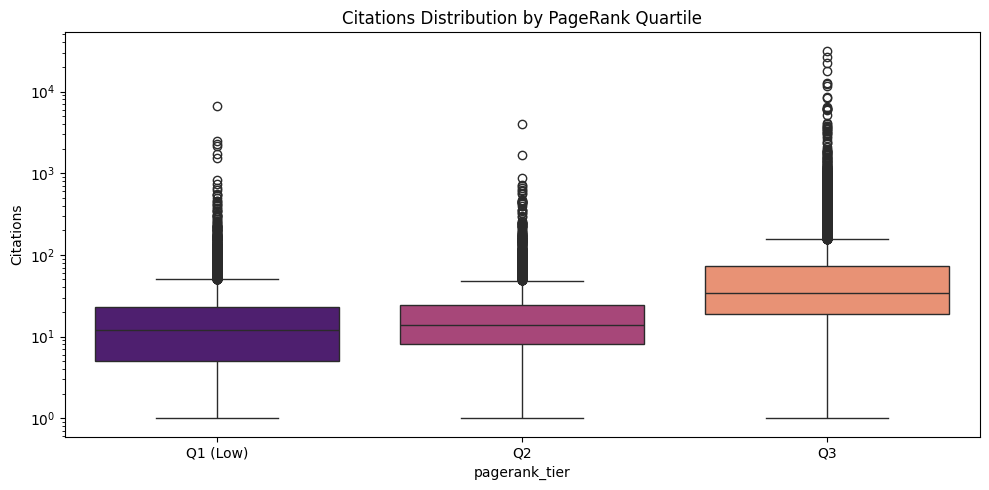

In [ ]:
# Venue Tier Impact
print(" VENUE TIER ANALYSIS")
venue_analysis = df_features.groupby('venue_tier').agg({
    'target_variable': ['count', 'mean', 'median', 'std'],
    'citation_per_year': 'mean',
    'n_references': 'mean'
}).round(2)
print(venue_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
venue_order = ['elite', 'high', 'medium', 'low']
df_features_sorted = df_features.copy()
df_features_sorted['venue_tier'] = pd.Categorical(df_features_sorted['venue_tier'], categories=venue_order, ordered=True)

sns.boxplot(data=df_features_sorted, x='venue_tier', y='target_variable', ax=axes[0], palette='Set2')
axes[0].set_ylabel('Citations')
axes[0].set_title('Citations Distribution by Venue Tier')

sns.violinplot(data=df_features_sorted, x='venue_tier', y='citation_per_year', ax=axes[1], palette='Set3')
axes[1].set_ylabel('Citations Per Year (Normalized)')
axes[1].set_title('Citation Rate by Venue Tier')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# Author Reputation Impact
print("\n👥 AUTHOR REPUTATION TIERS")
df_features['author_tier'] = pd.cut(df_features['max_author_citations'], 
                                     bins=[0, 5, 20, 100, 10000],
                                     labels=['Emerging', 'Mid-Career', 'Established', 'Star'])

author_analysis = df_features.groupby('author_tier', observed=True).agg({
    'target_variable': ['count', 'mean', 'median'],
    'n_authors': 'mean'
}).round(2)
print(author_analysis)

df_features.boxplot(column='target_variable', by='author_tier', figsize=(10, 5))
plt.suptitle('')
plt.title('Citations Distribution by Author Career Stage')
plt.ylabel('Citations')
plt.show()

# Era Analysis
print("\nTEMPORAL TRENDS")
era_analysis = df_features.groupby('publication_era').agg({
    'target_variable': ['count', 'mean', 'median'],
    'citation_per_year': 'mean'
}).round(2)
print(era_analysis)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

era_order = ['pre-2000', '2000-2009', '2010-2019', '2020+']
df_temp = df_features.copy()
df_temp['publication_era'] = pd.Categorical(df_temp['publication_era'], categories=era_order, ordered=True)
df_temp = df_temp.sort_values('publication_era')

sns.boxplot(data=df_temp, x='publication_era', y='target_variable', ax=ax1, palette='Set1')
ax1.set_ylabel('Citations')
ax1.set_title('Raw Citations by Era')

df_temp_norm = df_temp[df_temp['citation_per_year'].notna()]
sns.violinplot(data=df_temp_norm, x='publication_era', y='citation_per_year', ax=ax2, palette='Set2')
ax2.set_ylabel('Citations Per Year')
ax2.set_title('Normalized Citation Rate by Era')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

# Complex Interactions
print("\n VENUE x AUTHOR INTERACTION")
interaction = df_features.groupby(['venue_tier', 'author_tier'], observed=True)['target_variable'].agg(['count', 'mean']).round(1)
print(interaction)

# Graph Topology Impact
if 'pagerank' in df_features.columns:
    print("\nPAGERANK TOPOLOGY TIERS")
    
    # Divide the pagerank in 4 quantiles (Q1 low, Q4 high)
    pagerank_cut, pagerank_bins = pd.qcut(
    df_features['pagerank'], q=4, retbins=True, duplicates='drop'
    )
    
    n_bins = len(pagerank_bins) - 1
    tier_labels = ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'][:n_bins]

    df_features['pagerank_tier'] = pd.qcut(
        df_features['pagerank'], q=4,
        labels=tier_labels,
        duplicates='drop'
    )
    
    pagerank_analysis = df_features.groupby('pagerank_tier', observed=True).agg({
        'target_variable': ['count', 'mean', 'median'],
        'pagerank': 'mean'
    }).round(4)
    print(pagerank_analysis)
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_features, x='pagerank_tier', y='target_variable', palette='magma')
    plt.title('Citations Distribution by PageRank Quartile')
    plt.ylabel('Citations')
    plt.yscale('log')   # log scale
    plt.tight_layout()
    plt.show()

Building comprehensive correlation matrix with ALL features...
Combined dataset shape: (33095, 25)
Features included: ['title_word_count', 'abstract_word_count', 'title_abstract_ratio', 'title_complexity', 'abstract_complexity', 'n_authors', 'avg_author_citations', 'max_author_citations', 'n_references', 'references_author_ratio', 'citation_richness', 'years_since_publication', 'citation_per_year', 'impact_score', 'venue_median_citations', 'venue_volume', 'is_top_venue', 'is_english', 'pagerank', 'hub_score', 'authority_score', 'target_variable', 'n_keywords', 'page_count', 'abstract_length']


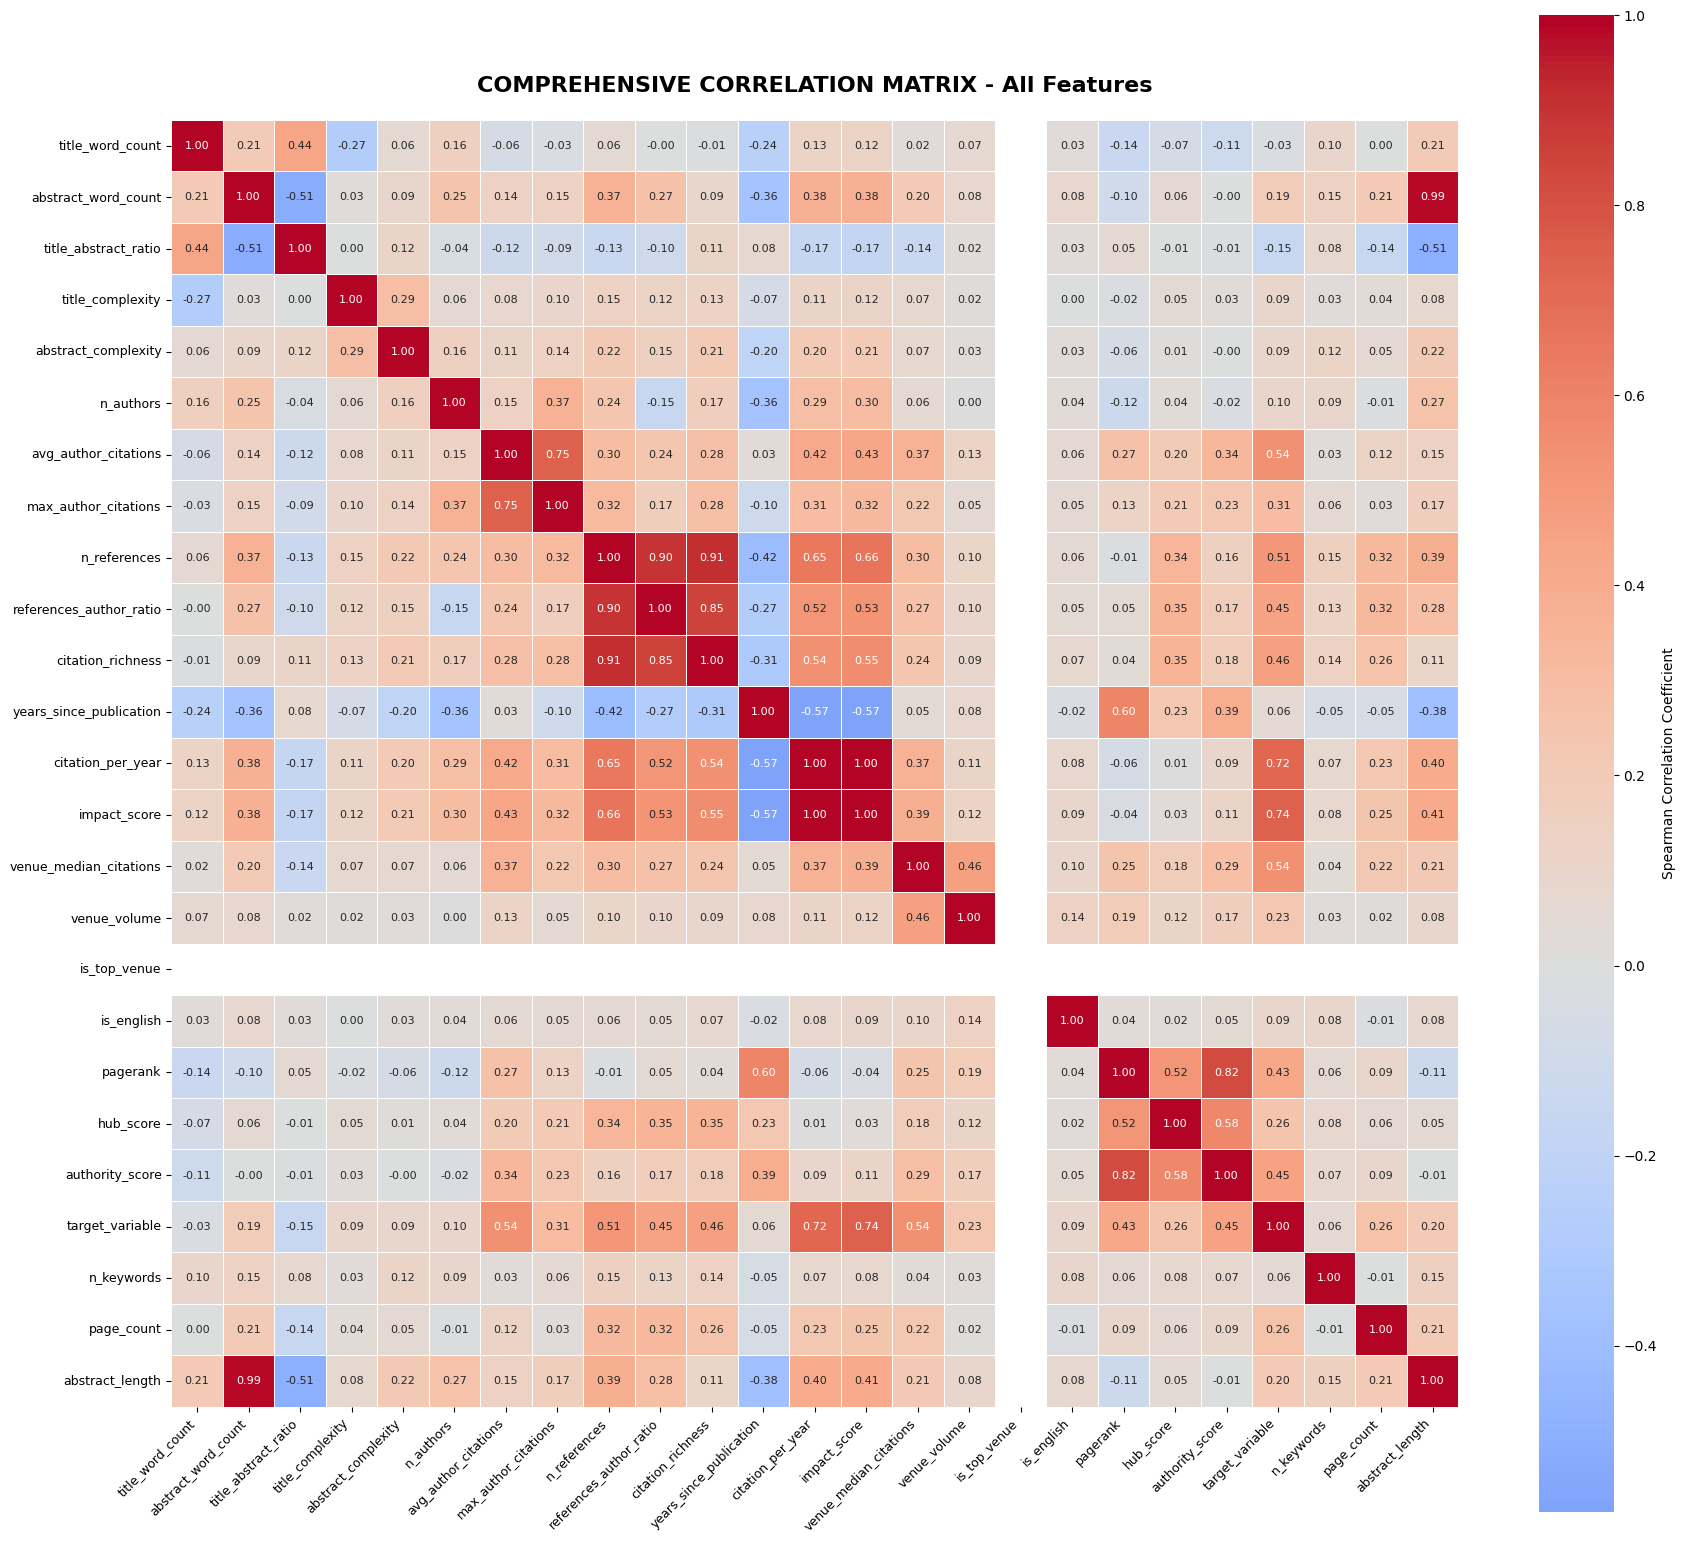


CORRELATION WITH TARGET VARIABLE (n_citation) - SPEARMAN

All features ranked by correlation strength with citations:
  ★★★ impact_score                   +0.7425
  ★★★ citation_per_year              +0.7194
  ★★★ avg_author_citations           +0.5438
  ★★★ venue_median_citations         +0.5391
  ★★★ n_references                   +0.5092
  ★★★ citation_richness              +0.4595
  ★★★ authority_score                +0.4529
  ★★★ references_author_ratio        +0.4523
  ★★★ pagerank                       +0.4271
  ★★ max_author_citations           +0.3069
  ★★ page_count                     +0.2645
  ★★ hub_score                      +0.2555
  ★★ venue_volume                   +0.2294
  ★★ abstract_length                +0.2032
  ★ abstract_word_count            +0.1914
  ★ title_abstract_ratio           -0.1547
  ★ n_authors                      +0.0984
  ★ abstract_complexity            +0.0947
  ★ title_complexity               +0.0906
  ★ is_english                     +0.089

In [ ]:
# Comprehensive correlation matrix - all features combined
print("Building comprehensive correlation matrix with ALL features...")

# One query to have all features aligned 
df_combined = con.sql(f"""
    SELECT 
        pwf.title_word_count,
        pwf.abstract_word_count,
        pwf.title_abstract_ratio,
        pwf.title_complexity,
        pwf.abstract_complexity,
        pwf.n_authors,
        pwf.avg_author_citations,
        pwf.max_author_citations,
        pwf.n_references,
        pwf.references_author_ratio,
        pwf.citation_richness,
        pwf.years_since_publication,
        pwf.citation_per_year,
        pwf.impact_score,
        pwf.venue_median_citations,
        pwf.venue_volume,
        pwf.is_top_venue,
        pwf.is_english,
        pwf.pagerank,               
        pwf.hub_score,              
        pwf.authority_score,        
        pwf.target_variable,
        
        -- Feature aggiuntive estratte direttamente dal parquet originale
        ARRAY_LENGTH(p.keywords) AS n_keywords,
        TRY_CAST(p.page_end AS INT) - TRY_CAST(p.page_start AS INT) AS page_count,
        LENGTH(p.abstract) AS abstract_length
        
    FROM papers_with_features pwf
    JOIN read_parquet('{PARQUET}') p ON pwf.id = p.id
    WHERE pwf.target_variable IS NOT NULL 
      AND pwf.target_variable > 0
    USING SAMPLE 50000
""").df().dropna()

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Features included: {list(df_combined.columns)}")

# === FINAL COMPREHENSIVE CORRELATION MATRIX ===
correlation_matrix = df_combined.corr(method='spearman')

# Create large heatmap
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Spearman Correlation Coefficient'},
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title('COMPREHENSIVE CORRELATION MATRIX - All Features', 
             fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Correlation with Target
print("\n" + "="*80)
print("CORRELATION WITH TARGET VARIABLE (n_citation) - SPEARMAN")
print("="*80)

target_corr = correlation_matrix['target_variable'].drop('target_variable').sort_values(key=abs, ascending=False)
print("\nAll features ranked by correlation strength with citations:")
for feat, corr_val in target_corr.items():
    stars = "★★★" if abs(corr_val) > 0.4 else "★★" if abs(corr_val) > 0.2 else "★"
    print(f"  {stars} {feat:30} {corr_val:+.4f}")

# Feature Grouping Insights 
print("\n" + "="*80)
print("FEATURE STRENGTH SUMMARY")
print("="*80)
strong = len(target_corr[abs(target_corr) > 0.4])
moderate = len(target_corr[(abs(target_corr) > 0.2) & (abs(target_corr) <= 0.4)])
weak = len(target_corr[abs(target_corr) <= 0.2])

print(f"Strong predictors (|r| > 0.40):      {strong:2d} features")
print(f"Moderate predictors (0.2 < |r| ≤ 0.40): {moderate:2d} features")
print(f"Weak predictors (|r| ≤ 0.20):        {weak:2d} features")
print(f"Total features analyzed:             {len(target_corr):2d} features")

# Inter-Feature Correlations
print("\n" + "="*80)
print("HIGH INTER-FEATURE CORRELATIONS (|r| > 0.7) - Potential Multicollinearity")
print("="*80)

# Find highly correlated feature pairs (excluding diagonal and duplicates)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            feat1 = correlation_matrix.columns[i]
            feat2 = correlation_matrix.columns[j]
            corr_pairs.append((feat1, feat2, corr_val))

corr_pairs = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

if corr_pairs:
    for f1, f2, corr in corr_pairs[:15]:  # Top 15
        print(f"  {f1:25} <-> {f2:25} | r = {corr:+.4f}")
else:
    print("  No highly correlated feature pairs found (r > 0.7)")

print("\n" + "="*80)

## EXPORT & SUMMARY

Esportiamo i risultati del feature engineering per uso in modeling:

In [ ]:
# Export complete feature set
con.sql("COPY papers_with_features TO 'papers_with_features.parquet' (FORMAT PARQUET)")
print(" Exported: papers_with_features.parquet")

# Export top cited papers
con.sql("""
COPY (
    SELECT * FROM papers_with_features
    ORDER BY target_variable DESC
    LIMIT 100
) TO 'top_cited_papers_features.parquet' (FORMAT PARQUET)
""")
print("Exported: top_cited_papers_features.parquet")

# Insights calculations on the whole dataset using DuckDB
total_papers = con.sql("SELECT COUNT(*) FROM papers_with_features").fetchone()[0]

elite_mean    = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE venue_tier = 'elite'").fetchone()[0] or 0
weak_mean     = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE venue_tier = 'low'").fetchone()[0] or 0

star_mean     = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE max_author_citations > 100").fetchone()[0] or 0
emerging_mean = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE max_author_citations <= 5").fetchone()[0] or 0

mature_mean   = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE year < 2000").fetchone()[0] or 0
recent_mean   = con.sql("SELECT AVG(target_variable) FROM papers_with_features WHERE year >= 2020").fetchone()[0] or 0

# Generate summary report
print("\n" + "="*80)
print("FEATURE ENGINEERING FINAL REPORT")
print("="*80)

print(f"\nTotal Papers with Features: {total_papers:,}")
print(f"Total Features Created: {len(numeric_features)} numeric + 5 categorical")

print(f"\n TOP 5 PREDICTIVE FEATURES (Spearman):")
for i, row in corr_df.head(5).iterrows():
    print(f"   {i+1}. {row['Feature']:30} | Corr: {row['Correlation']:+.4f}")

print(f"\n KEY INSIGHTS (Computed on the FULL dataset):")
print(f"   • Strong venues get {elite_mean:.0f} citations vs {weak_mean:.0f} for weak")
print(f"   • Papers with star authors: {star_mean:.0f} cit. vs {emerging_mean:.0f} for emerging")
print(f"   • Pre-2000 papers: {mature_mean:.0f} citations (mature)")
print(f"   • 2020+ papers: {recent_mean:.0f} citations (incomplete)")

if 'pagerank' in corr_df['Feature'].values:
    pr_corr = corr_df[corr_df['Feature'] == 'pagerank']['Correlation'].iloc[0]
    print(f"   • Graph Topology: PageRank correlation with citations is {pr_corr:+.4f}!")

print("\n" + "="*80)

 Exported: papers_with_features.parquet
Exported: top_cited_papers_features.parquet

FEATURE ENGINEERING FINAL REPORT

Total Papers with Features: 6,729,828
Total Features Created: 11 numeric + 5 categorical

 TOP 5 PREDICTIVE FEATURES (Spearman):
   7. n_references                   | Corr: +0.5209
   9. citation_richness              | Corr: +0.4705
   8. references_author_ratio        | Corr: +0.4625
   2. abstract_word_count            | Corr: +0.1819
   3. title_abstract_ratio           | Corr: -0.1606

 KEY INSIGHTS (Computed on the FULL dataset):
   • Strong venues get 328 citations vs 14 for weak
   • Papers with star authors: 44 cit. vs 6 for emerging
   • Pre-2000 papers: 58 citations (mature)
   • 2020+ papers: 20 citations (incomplete)



# TRAINING

## SPLIT

In [3]:
import pyarrow.parquet as pq
import pandas as pd

INPUT_FILE = "papers_with_features.parquet"

# Read schema without loading data
pf = pq.read_schema(INPUT_FILE)
print(f"Total columns: {len(pf.names)}\n")
print(f"{'Column':<45} {'Type':<20}")
print("-" * 65)
for name in pf.names:
    print(f"{name:<45} {str(pf.field(name).type):<20}")

# Load only first 3 rows to see actual values
print("\n--- Sample values (3 rows) ---")
sample = pd.read_parquet(INPUT_FILE).head(3)
for col in sample.columns:
    print(f"\n{col}: {sample[col].tolist()}")

Total columns: 36

Column                                        Type                
-----------------------------------------------------------------
id                                            string              
title                                         string              
references                                    list<element: string>
year                                          int64               
target_variable                               int64               
title_word_count                              int64               
abstract_word_count                           int64               
title_abstract_ratio                          float               
title_complexity                              float               
abstract_complexity                           float               
has_numbers_in_title                          int32               
has_numbers_in_abstract                       int32               
n_authors                                  

KeyboardInterrupt: 

In [ ]:
leaky_features = [
    # --- QUALITY & IMPACT ---
    "citation_per_year",
    "impact_score",
    "is_highly_cited_for_year",
    
    # --- AUTHOR METRICS ---
    "avg_author_citations",
    "max_author_citations",
    
    # --- VENUE METRICS ---
    "venue_median_citations",
    "venue_volume",         
    "is_top_venue",
    "venue_tier",
    
    # --- GRAPH METRICS ---
    "pagerank",             
    "hub_score",            
    "authority_score",      
]


In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

# CONFIGURATION

INPUT_FILE = "papers_with_features.parquet"
OUTPUT_DIR = "model_splits"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Check if split files already exist
split_files_exist = all([
    os.path.exists(f"{OUTPUT_DIR}/train.parquet"),
    os.path.exists(f"{OUTPUT_DIR}/val.parquet"),
    os.path.exists(f"{OUTPUT_DIR}/test.parquet")
])

if split_files_exist:
    print(f"Split files already exist in '{OUTPUT_DIR}'. Skipping creation.")
else:
    print("Loading dataset...")
    df = pd.read_parquet(INPUT_FILE)

    # 1. Temporal sorting 
    df = df.dropna(subset=["year"]).copy()
    df = df.sort_values("year").reset_index(drop=True)

    # Sequential node_idx 0..N-1 (required by PyTorch Geometric)
    df["node_idx"] = np.arange(len(df), dtype=np.int32)

    # 2. Feature definition
    

    # Features that do not need to be scaled
    non_feature_cols = [
        "id",
        "n_citation",
        "node_idx",
        "split",
        "year",
        "title",
        "abstract",
        "venue",
        "publication_era",
        "venue_tier",
        "references",       # (edge_index)
        "target_variable"   
    ]

    exclude_cols = set(non_feature_cols + list(leaky_features))

    # Select only valid numerical columns
    safe_numeric_features = [
        col for col in df.columns
        if col not in exclude_cols
        and pd.api.types.is_numeric_dtype(df[col])
    ]

    print(f"\nSafe numeric features selected ({len(safe_numeric_features)}):")
    for f in safe_numeric_features[:5]:
        print(f"  ✓  {f}")
    if len(safe_numeric_features) > 5:
        print("  ... e altre")

    # 3. Temporal splitting (Train <= 2020, Val 2021-2022, Test >= 2023) 
    df["split"] = ""
    
    df.loc[df["year"] <= 2020, "split"] = "train"
    df.loc[(df["year"] >= 2021) & (df["year"] <= 2022), "split"] = "val"
    df.loc[df["year"] >= 2023, "split"] = "test"

    print("\nSplit distribution:")
    print(df["split"].value_counts().reindex(["train", "val", "test"]))
    print(f"  Train years : {df.loc[df['split']=='train', 'year'].min()} – "
          f"{df.loc[df['split']=='train', 'year'].max()}")
    print(f"  Val years   : {df.loc[df['split']=='val',   'year'].min()} – "
          f"{df.loc[df['split']=='val',   'year'].max()}")
    print(f"  Test years  : {df.loc[df['split']=='test',  'year'].min()} – "
          f"{df.loc[df['split']=='test',  'year'].max()}")

    # 4. Strict scaling (fit ONLY on train, transform val/test)
    X_train = df.loc[df["split"] == "train", safe_numeric_features].to_numpy()
    X_val   = df.loc[df["split"] == "val",   safe_numeric_features].to_numpy()
    X_test  = df.loc[df["split"] == "test",  safe_numeric_features].to_numpy()

    X_train = np.nan_to_num(X_train, nan=-999.0, posinf=0.0, neginf=0.0)
    X_val   = np.nan_to_num(X_val,   nan=-999.0, posinf=0.0, neginf=0.0)
    X_test  = np.nan_to_num(X_test,  nan=-999.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)

    # Cast a float64 per sicurezza e assegnazione
    for col in safe_numeric_features:
        df[col] = df[col].astype("float64")

    df.loc[df["split"] == "train", safe_numeric_features] = X_train_scaled
    df.loc[df["split"] == "val",   safe_numeric_features] = X_val_scaled
    df.loc[df["split"] == "test",  safe_numeric_features] = X_test_scaled

    # 5. Save files
    
    # Columns to keep in the files
    keep_cols = safe_numeric_features + [
        "id",
        "node_idx",
        "split",
        "year",
        "references",      
    ]

    # Remove duplicate columns (if any)
    keep_cols = list(dict.fromkeys(keep_cols))

    print("\nSaving split files...")
    df.loc[df["split"] == "train", keep_cols].to_parquet(
        f"{OUTPUT_DIR}/train.parquet", index=False)
    df.loc[df["split"] == "val",   keep_cols].to_parquet(
        f"{OUTPUT_DIR}/val.parquet",   index=False)
    df.loc[df["split"] == "test",  keep_cols].to_parquet(
        f"{OUTPUT_DIR}/test.parquet",  index=False)

    np.save(f"{OUTPUT_DIR}/scaler_mean.npy",  scaler.mean_)
    np.save(f"{OUTPUT_DIR}/scaler_scale.npy", scaler.scale_)

    print(f"\n✓ Done. Files saved in '{OUTPUT_DIR}/'")
    print(f"   Node Features        : {len(safe_numeric_features)}")
    print(f"   Structural columns   : id, node_idx, split, year")
    print(f"   Graph Edges column   : references")
    print(f"   Scaler saved         : scaler_mean.npy, scaler_scale.npy")

Loading dataset...

Safe numeric features selected (17):
  ✓  title_word_count
  ✓  abstract_word_count
  ✓  title_abstract_ratio
  ✓  title_complexity
  ✓  abstract_complexity
  ... e altre

Split distribution:
split
train    4920858
val       767458
test     1041512
Name: count, dtype: int64
  Train years : 0 – 2020
  Val years   : 2021 – 2022
  Test years  : 2023 – 2027

Saving split files...

✓ Done. Files saved in 'model_splits/'
   Node Features        : 17
   Structural columns   : id, node_idx, split, year
   Graph Edges column   : references
   Scaler saved         : scaler_mean.npy, scaler_scale.npy


# Load Splits and Train Models

In [ ]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import lightgbm as lgb
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

In [ ]:
import polars as pl

# Load the parquet files as polars dataframe
train_df = pl.read_parquet('model_splits/train.parquet')
val_df = pl.read_parquet('model_splits/val.parquet')
test_df = pl.read_parquet('model_splits/test.parquet')

train_df

title_word_count,abstract_word_count,title_abstract_ratio,title_complexity,abstract_complexity,has_numbers_in_title,has_numbers_in_abstract,n_authors,multi_authored,n_references,references_author_ratio,citation_richness,has_high_ref_count,years_since_publication,decade,is_recent,is_english,id,node_idx,split,year,references
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i32,str,i64,list[str]
-0.508538,0.041884,-0.201839,0.280981,0.149465,0.0,0.0,0.713545,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,183.645458,-183.645458,-0.416134,-5.182193,"""5e4d083f3a55ac8cfd770a60""",0,"""train""",0,[]
1.888819,0.969553,-0.095596,-1.158931,-0.017807,0.0,0.0,0.32935,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,183.645458,-183.645458,-0.416134,-5.182193,"""60376557d3485cfff1d91b49""",1,"""train""",0,[]
-2.373149,-0.479135,-0.658446,-1.445718,0.207225,0.0,0.0,-0.439039,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,183.645458,-183.645458,-0.416134,-5.182193,"""62b132115aee126c0f9c1c6e""",2,"""train""",0,[]
-1.041284,-0.542674,-0.348037,-1.716573,0.293953,0.0,0.0,0.713545,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,183.645458,-183.645458,-0.416134,-5.182193,"""5e79da3b91e0115bb11579c1""",3,"""train""",0,[]
-0.774911,0.52478,-0.349099,0.411572,0.109915,0.0,0.0,-0.054845,0.422567,-0.804686,-0.653377,-0.584823,-0.092192,183.645458,-183.645458,-0.416134,-5.182193,"""60741fbae4510cd7c8721d18""",4,"""train""",0,[]
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.508538,-0.593505,0.032441,-0.02373,0.187376,0.0,0.0,-0.054845,0.422567,0.394265,0.200946,0.652971,-0.092192,-0.905639,0.905639,2.403072,0.192969,"""5c7574baf56def9798979c9f""",4920853,"""train""",2020,"[""5390aefc20f70186a0ecd7c8"", ""53e9a407b7602d9702d1ea1e"", … ""5843772fac44360f10831458""]"
1.888819,0.52478,0.003072,-0.680951,0.199908,0.0,0.0,1.097739,0.422567,1.593215,0.200946,0.665435,-0.092192,-0.905639,0.905639,2.403072,0.192969,"""5c6fcf59e1cd8e59a74f322a""",4920854,"""train""",2020,"[""5d78ccaf47c8f76646d1fd02"", ""558c048c84ae6766fdf093c6"", … ""573f18f60cf2435a6d70b31a""]"
-0.774911,-0.16144,-0.204951,0.527653,0.205112,0.0,0.0,-0.439039,0.422567,0.394265,0.628108,0.307922,-0.092192,-0.905639,0.905639,2.403072,0.192969,"""5bbacb9e17c44aecc4eafffc""",4920855,"""train""",2020,"[""5390994d20f70186a0e1352e"", ""5736960f6e3b12023e521832"", … ""573696ce6e3b12023e5cecd8""]"


## Preparation for LGBM and XGBoost

In [ ]:
# Shared data construction

import polars as pl

# Fraction of edges to sample per split
FRACTION_TRAIN = 0.20   
FRACTION_VAL   = 0.40  
FRACTION_TEST  = 0.50   

leaky_features = [
    # --- QUALITY & IMPACT ---
    "citation_per_year",
    "impact_score",
    "is_highly_cited_for_year",
    
    # --- AUTHOR METRICS ---
    "avg_author_citations",
    "max_author_citations",
    
    # --- VENUE METRICS ---
    "venue_median_citations",
    "venue_volume",         
    "is_top_venue",
    "venue_tier",
    
    # --- GRAPH METRICS ---
    "pagerank",             
    "hub_score",            
    "authority_score",      
]

# Load pre-processed parquet splits 

all_df = pl.concat([train_df, val_df, test_df]).sort("node_idx")

num_train_nodes = int(train_df["node_idx"].max()) + 1
num_val_nodes   = int(max(train_df["node_idx"].max(), val_df["node_idx"].max())) + 1
num_total_nodes = int(all_df["node_idx"].max()) + 1

print(f"  Train nodes: {num_train_nodes:,}")
print(f"  Val nodes  : {num_val_nodes:,}")
print(f"  Total nodes: {num_total_nodes:,}")

id_to_idx = all_df.select(["id", "node_idx"])


# Section 1: Node feature matrix 
# Each split only sees features of nodes that exist at that point in time.
exclude_cols = ["id", "node_idx", "split", "year", "references", "target_variable"]
exclude_cols = list(dict.fromkeys(exclude_cols + leaky_features))
feature_cols = [c for c in all_df.columns if c not in exclude_cols]

print(f"\nBuilding feature matrix: {num_total_nodes:,} nodes × {len(feature_cols)} features...")
node_feats_full = all_df.select(feature_cols).to_numpy()
node_feats_full = np.nan_to_num(
    node_feats_full, posinf=0.0, neginf=0.0
).astype(np.float32)

node_feats_train = node_feats_full[:num_train_nodes]
node_feats_val   = node_feats_full[:num_val_nodes]
node_feats_test  = node_feats_full[:num_total_nodes]


# Section 2: Positive edge extraction 
# Edge (src → dst) means "paper src cites paper dst".
# Edges pointing to future nodes are filtered out to prevent leakage.
def get_edge_index(split_df, max_dst_node):
    edges = (
        split_df.select(["node_idx", "references"])
        .explode("references")
        .drop_nulls()
        .rename({"node_idx": "src", "references": "target_id"})
    )
    edges = edges.join(id_to_idx, left_on="target_id", right_on="id", how="inner")
    edges = edges.rename({"node_idx": "dst"})
    edges = edges.filter(pl.col("dst") < max_dst_node)
    src_np = edges["src"].to_numpy()
    dst_np = edges["dst"].to_numpy()
    return torch.tensor(np.vstack([src_np, dst_np]), dtype=torch.long)


def subsample_edges(edge_index, fraction):
    if fraction >= 1.0:
        return edge_index
    n = max(1, int(edge_index.size(1) * fraction))
    return edge_index[:, torch.randperm(edge_index.size(1))[:n]]


print("Extracting positive edges...")
train_pos_full = get_edge_index(train_df, max_dst_node=num_train_nodes)
val_pos_full   = get_edge_index(val_df,   max_dst_node=num_val_nodes)
test_pos_full  = get_edge_index(test_df,  max_dst_node=num_total_nodes)

print("Applying subsampling...")
torch.manual_seed(42)
train_pos = subsample_edges(train_pos_full, FRACTION_TRAIN)
val_pos   = subsample_edges(val_pos_full,   FRACTION_VAL)
test_pos  = subsample_edges(test_pos_full,  FRACTION_TEST)

print(f"  Train: {train_pos.size(1):,} edges (out of {train_pos_full.size(1):,})")
print(f"  Val  : {val_pos.size(1):,} edges (out of {val_pos_full.size(1):,})")
print(f"  Test : {test_pos.size(1):,} edges (out of {test_pos_full.size(1):,})")


# Section 3: Temporal negative sampling 
# For each positive edge we sample one fake pair → balanced 50/50 dataset.
# Train negatives are guaranteed not to appear in val/test edge sets.
# Pairs are encoded as src * num_nodes + dst for O(1) lookup.

def sample_negatives_hard(known_edge_index, num_nodes, target_count, years_array, max_gap=10, oversample=5.0, seed=42):
    rng = np.random.default_rng(seed)
    src_k = known_edge_index[0].numpy().astype(np.int64)
    dst_k = known_edge_index[1].numpy().astype(np.int64)
    known_codes = set((src_k * num_nodes + dst_k).tolist())

    collected_src, collected_dst = [], []
    remaining = target_count

    while remaining > 0:
        n_sample = int(remaining * oversample)
        # 1. Randomly pick source and destination nodes
        src_rand = rng.integers(0, num_nodes, size=n_sample, dtype=np.int64)
        dst_rand = rng.integers(0, num_nodes, size=n_sample, dtype=np.int64)
        
        # 2. HARD NEGATIVE CONSTRAINT: Ensure temporal validity and closeness
        src_years = years_array[src_rand]
        dst_years = years_array[dst_rand]
        valid_time = (dst_years <= src_years) & ((src_years - dst_years) <= max_gap)
        
        # 3. Remove self-loops
        valid = valid_time & (src_rand != dst_rand)
        src_rand, dst_rand = src_rand[valid], dst_rand[valid]
        
        # 4. Remove pairs that are actually real citations
        codes = (src_rand * num_nodes + dst_rand).tolist()
        mask = np.array([c not in known_codes for c in codes], dtype=bool)
        src_rand, dst_rand = src_rand[mask], dst_rand[mask]
        
        take = min(remaining, len(src_rand))
        collected_src.append(src_rand[:take])
        collected_dst.append(dst_rand[:take])
        remaining -= take

    src_out = np.concatenate(collected_src).astype(np.int64)
    dst_out = np.concatenate(collected_dst).astype(np.int64)
    return torch.tensor(np.vstack([src_out, dst_out]), dtype=torch.long)

# Extract the year array for fast numpy lookups during sampling
years_array = all_df["year"].to_numpy()

print("\nGenerating HARD negative samples (Max Gap: 10 years)...")

neg_train = sample_negatives_hard(
    train_pos_full, num_nodes=num_train_nodes,
    target_count=train_pos.size(1), years_array=years_array, seed=42
)
print(f"  neg_train: {neg_train.size(1):,}")

neg_val = sample_negatives_hard(
    torch.cat([train_pos_full, val_pos_full], dim=1),
    num_nodes=num_val_nodes,
    target_count=val_pos.size(1), years_array=years_array, seed=43
)
print(f"  neg_val  : {neg_val.size(1):,}")

neg_test = sample_negatives_hard(
    torch.cat([train_pos_full, val_pos_full, test_pos_full], dim=1),
    num_nodes=num_total_nodes,
    target_count=test_pos.size(1), years_array=years_array, seed=44
)
print(f"  neg_test : {neg_test.size(1):,}")



# Section 4: Tabular matrix construction 
# Each edge (src → dst) becomes a row of 50 values:
#   [feat_1_src ... feat_25_src | feat_1_dst ... feat_25_dst]
# Label 1 = real citation, 0 = fake pair.
def pairs_to_matrix(edge_index, node_feats):
    src = edge_index[0].cpu().numpy()
    dst = edge_index[1].cpu().numpy()
    return np.hstack([node_feats[src], node_feats[dst]])


print("\nCreating tabular datasets...")

X_train_xgb = np.vstack([
    pairs_to_matrix(train_pos, node_feats_train),
    pairs_to_matrix(neg_train, node_feats_train),
])
y_train_xgb = np.concatenate([
    np.ones(train_pos.size(1),  dtype=np.int32),
    np.zeros(neg_train.size(1), dtype=np.int32),
])

X_val_xgb = np.vstack([
    pairs_to_matrix(val_pos, node_feats_val),
    pairs_to_matrix(neg_val, node_feats_val),
])
y_val_xgb = np.concatenate([
    np.ones(val_pos.size(1),  dtype=np.int32),
    np.zeros(neg_val.size(1), dtype=np.int32),
])

X_test_xgb = np.vstack([
    pairs_to_matrix(test_pos, node_feats_test),
    pairs_to_matrix(neg_test, node_feats_test),
])
y_test_xgb = np.concatenate([
    np.ones(test_pos.size(1),  dtype=np.int32),
    np.zeros(neg_test.size(1), dtype=np.int32),
])

feature_names_xgb = [f"src_{c}" for c in feature_cols] + [f"dst_{c}" for c in feature_cols]

print(f"  X_train : {X_train_xgb.shape}  ← {train_pos.size(1):,} positives + {neg_train.size(1):,} negatives")
print(f"  X_val   : {X_val_xgb.shape}  ← {val_pos.size(1):,} positives + {neg_val.size(1):,} negatives")
print(f"  X_test  : {X_test_xgb.shape}  ← {test_pos.size(1):,} positives + {neg_test.size(1):,} negatives")

  Train nodes: 4,920,858
  Val nodes  : 5,688,316
  Total nodes: 6,729,828

Building feature matrix: 6,729,828 nodes × 17 features...
Extracting positive edges...
Applying subsampling...
  Train: 9,223,809 edges (out of 46,119,048)
  Val  : 5,165,524 edges (out of 12,913,811)
  Test : 7,239,049 edges (out of 14,478,099)

Generating HARD negative samples (Max Gap: 10 years)...
  neg_train: 9,223,809
  neg_val  : 5,165,524
  neg_test : 7,239,049

Creating tabular datasets...
  X_train : (18447618, 34)  ← 9,223,809 positives + 9,223,809 negatives
  X_val   : (10331048, 34)  ← 5,165,524 positives + 5,165,524 negatives
  X_test  : (14478098, 34)  ← 7,239,049 positives + 7,239,049 negatives


# MODEL 1 --> LGBM

Training LightGBM with Early Stopping on Validation Set...
Training stopped at iteration : 99
Training time                 : 62.7s

Evaluating on the Test Set...


c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- LightGBM Link Prediction (Test Split) ---
ROC-AUC : 0.8580
PR-AUC  : 0.8589
Brier   : 0.1551

Classification report:
              precision    recall  f1-score   support

           0     0.7467    0.8095    0.7769   7239049
           1     0.7920    0.7254    0.7573   7239049

    accuracy                         0.7675  14478098
   macro avg     0.7694    0.7675    0.7671  14478098
weighted avg     0.7694    0.7675    0.7671  14478098



c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


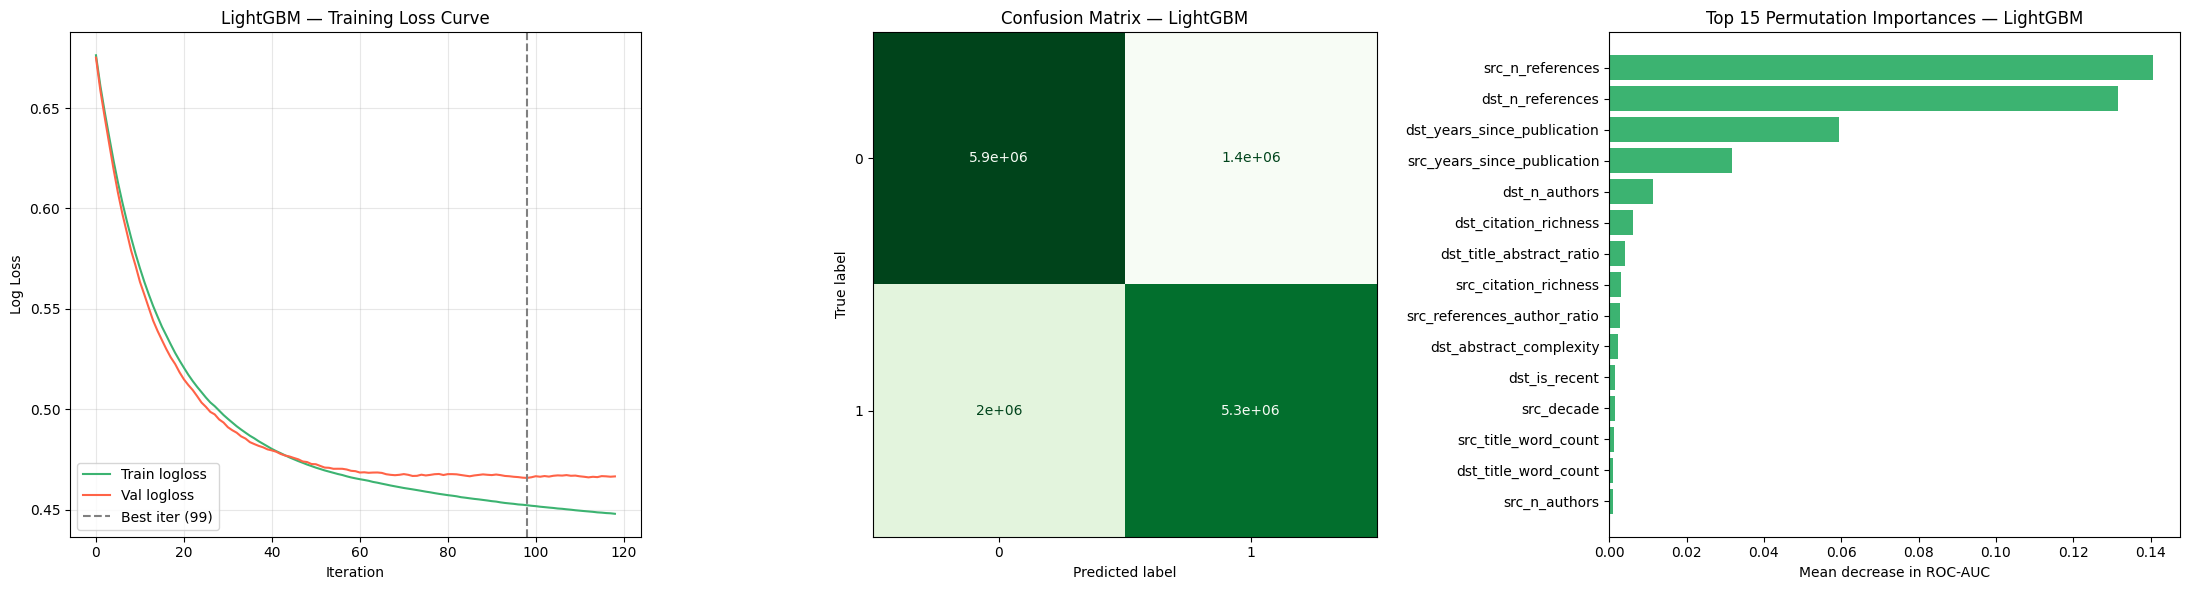

,feature,importance
9,src_n_references,0.14058
26,dst_n_references,0.13164
30,dst_years_since_publication,0.05944
13,src_years_since_publication,0.03184
24,dst_n_authors,0.01122
28,dst_citation_richness,0.00604
19,dst_title_abstract_ratio,0.00408
11,src_citation_richness,0.00312
10,src_references_author_ratio,0.00278
21,dst_abstract_complexity,0.00218


In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# LIGHTGBM — LINK PREDICTION                            

print("Training LightGBM with Early Stopping on Validation Set...")
scale_pos_weight_lgbm = (y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.9,
    min_child_samples=20,
    reg_lambda=1.0,
    objective="binary",
    metric="binary_logloss",
    scale_pos_weight=scale_pos_weight_lgbm,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# Callback to save the loss during training
lgbm_evals_result = {}

t0 = time.time()
lgbm_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_val_xgb, y_val_xgb)],
    eval_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=0),
        lgb.record_evaluation(lgbm_evals_result),
    ],
)
lgbm_train_time = time.time() - t0
print(f"Training stopped at iteration : {lgbm_model.best_iteration_}")
print(f"Training time                 : {lgbm_train_time:.1f}s")


# Evaluation 
print("\nEvaluating on the Test Set...")
lgbm_probs = lgbm_model.predict_proba(X_test_xgb)[:, 1]
lgbm_preds = (lgbm_probs >= 0.5).astype(int)

print("\n--- LightGBM Link Prediction (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb, lgbm_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, lgbm_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, lgbm_probs):.4f}")
print("\nClassification report:")
print(classification_report(y_test_xgb, lgbm_preds, digits=4))


# Plot: Loss curve + Confusion Matrix + Feature Importance 
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Subplot 1: Loss curve
train_loss = lgbm_evals_result["train"]["binary_logloss"]
val_loss   = lgbm_evals_result["val"]["binary_logloss"]
axes[0].plot(train_loss, label="Train logloss", color="mediumseagreen", linewidth=1.5)
axes[0].plot(val_loss,   label="Val logloss",   color="tomato",         linewidth=1.5)
axes[0].axvline(lgbm_model.best_iteration_ - 1, color="gray", linestyle="--", label=f"Best iter ({lgbm_model.best_iteration_})")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Log Loss")
axes[0].set_title("LightGBM — Training Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Confusion Matrix
cm_lgbm = confusion_matrix(y_test_xgb, lgbm_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_lgbm).plot(cmap="Greens", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — LightGBM")

# Subplot 3: Permutation importance 
N_IMP = min(5000, len(X_test_xgb))
idx_imp = np.random.default_rng(42).choice(len(X_test_xgb), N_IMP, replace=False)
lgbm_perm = permutation_importance(
    lgbm_model, X_test_xgb[idx_imp], y_test_xgb[idx_imp],
    n_repeats=10, random_state=42, n_jobs=-1
)
lgbm_importance_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": lgbm_perm.importances_mean,
}).sort_values("importance", ascending=False).head(15)

axes[2].barh(lgbm_importance_df["feature"][::-1], lgbm_importance_df["importance"][::-1], color="mediumseagreen")
axes[2].set_title("Top 15 Permutation Importances — LightGBM")
axes[2].set_xlabel("Mean decrease in ROC-AUC")


plt.tight_layout()
plt.show()

display(lgbm_importance_df.head(15))

# MODEL 2 --> Random Forest

Training Random Forest...
Training completed in : 971.8s

Evaluating on the Test Set...

--- Random Forest Link Prediction (Test Split) ---
ROC-AUC : 0.8563
PR-AUC  : 0.8557
Brier   : 0.1564

Classification report:
              precision    recall  f1-score   support

           0     0.7434    0.8098    0.7752   7239049
           1     0.7911    0.7205    0.7542   7239049

    accuracy                         0.7652  14478098
   macro avg     0.7673    0.7652    0.7647  14478098
weighted avg     0.7673    0.7652    0.7647  14478098



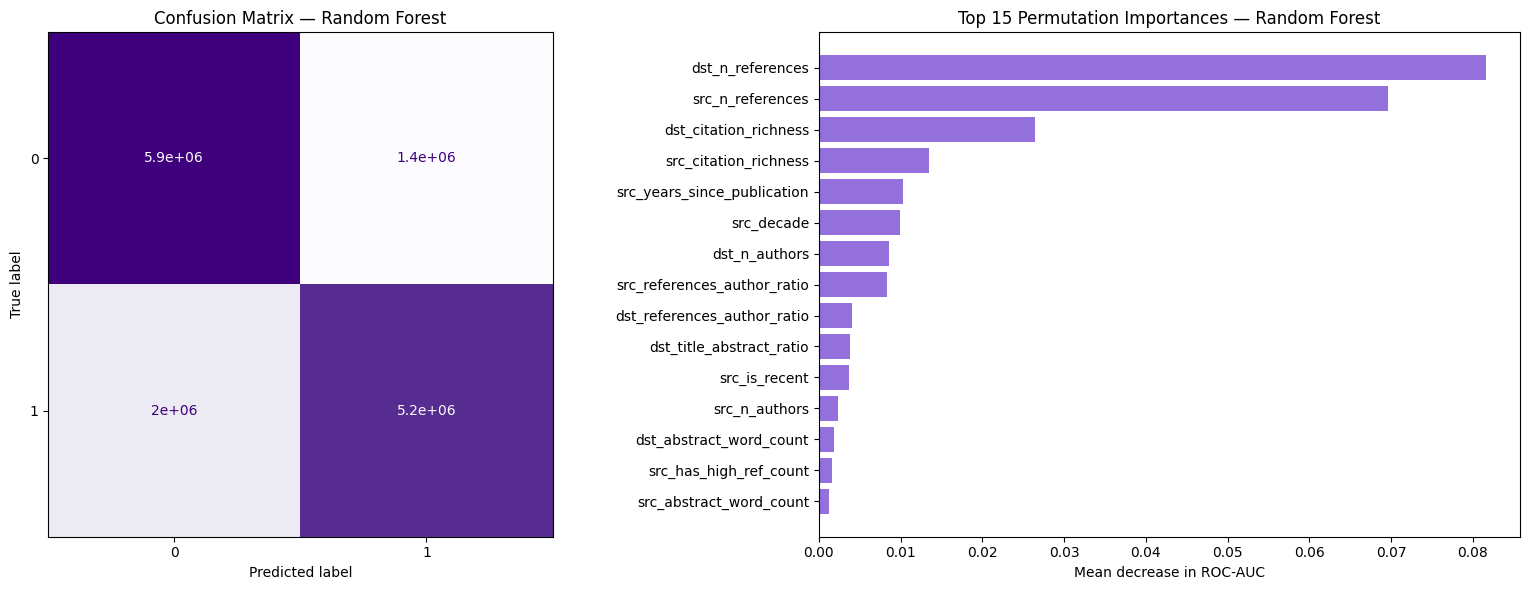

,feature,importance
26,dst_n_references,0.08168
9,src_n_references,0.06968
28,dst_citation_richness,0.02648
11,src_citation_richness,0.01350
13,src_years_since_publication,0.01030
14,src_decade,0.00992
24,dst_n_authors,0.00856
10,src_references_author_ratio,0.00838
27,dst_references_author_ratio,0.00410
19,dst_title_abstract_ratio,0.00378


In [ ]:



# RANDOM FOREST — LINK PREDICTION                      

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=500,          
    max_depth=15,              
    min_samples_leaf=2,
    max_features="sqrt",
    max_samples=0.15,        
    random_state=42,
    n_jobs=-1,                 
)

# train on train+val to match data seen by LGBM/MLP
t0 = time.time()
rf_model.fit(X_train_xgb, y_train_xgb)
rf_train_time = time.time() - t0


print(f"Training completed in : {rf_train_time:.1f}s")


# Evaluation 
print("\nEvaluating on the Test Set...")
rf_probs = rf_model.predict_proba(X_test_xgb)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)

print("\n--- Random Forest Link Prediction (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb, rf_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, rf_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, rf_probs):.4f}")
print("\nClassification report:")
print(classification_report(y_test_xgb, rf_preds, digits=4))


# Plot: Confusion Matrix + Feature Importance 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Confusion Matrix
cm_rf = confusion_matrix(y_test_xgb, rf_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot(cmap="Purples", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix — Random Forest")

# Subplot 2: Feature Importance
N_IMP = min(5000, len(X_test_xgb))
idx_imp = np.random.default_rng(42).choice(len(X_test_xgb), N_IMP, replace=False)
rf_perm = permutation_importance(
    rf_model, X_test_xgb[idx_imp], y_test_xgb[idx_imp],
    n_repeats=10, random_state=42, n_jobs=-1
)
rf_importance_df = pd.DataFrame({
    "feature": feature_names_xgb,
    "importance": rf_perm.importances_mean,
}).sort_values("importance", ascending=False).head(15)

axes[1].barh(rf_importance_df["feature"][::-1], rf_importance_df["importance"][::-1], color="mediumpurple")
axes[1].set_title("Top 15 Permutation Importances — Random Forest")
axes[1].set_xlabel("Mean decrease in ROC-AUC")


plt.tight_layout()
plt.show()

display(rf_importance_df.head(15))

# MODEL 3 --> MLP

Using device: cuda
Training MLP with Early Stopping on Validation Set...
  Epoch  1 | train=0.4471  val=0.4503 ✓
  Epoch  2 | train=0.4339  val=0.4390 ✓
  Epoch  3 | train=0.4321  val=0.4456
  Epoch  4 | train=0.4316  val=0.4644
  Epoch  5 | train=0.4311  val=0.4440
  Epoch  6 | train=0.4282  val=0.4422
  Epoch  7 | train=0.4277  val=0.4435
Early stopping at epoch 7.
Best epoch: 2  |  Training time: 1546.4s

--- MLP Link Prediction (Test Split) ---
ROC-AUC : 0.8793
PR-AUC  : 0.8729
Brier   : 0.1446

Classification report:
              precision    recall  f1-score   support

           0     0.8311    0.7557    0.7916   7239049
           1     0.7760    0.8464    0.8097   7239049

    accuracy                         0.8010  14478098
   macro avg     0.8035    0.8010    0.8006  14478098
weighted avg     0.8035    0.8010    0.8006  14478098

Computing permutation importance (subsample)...


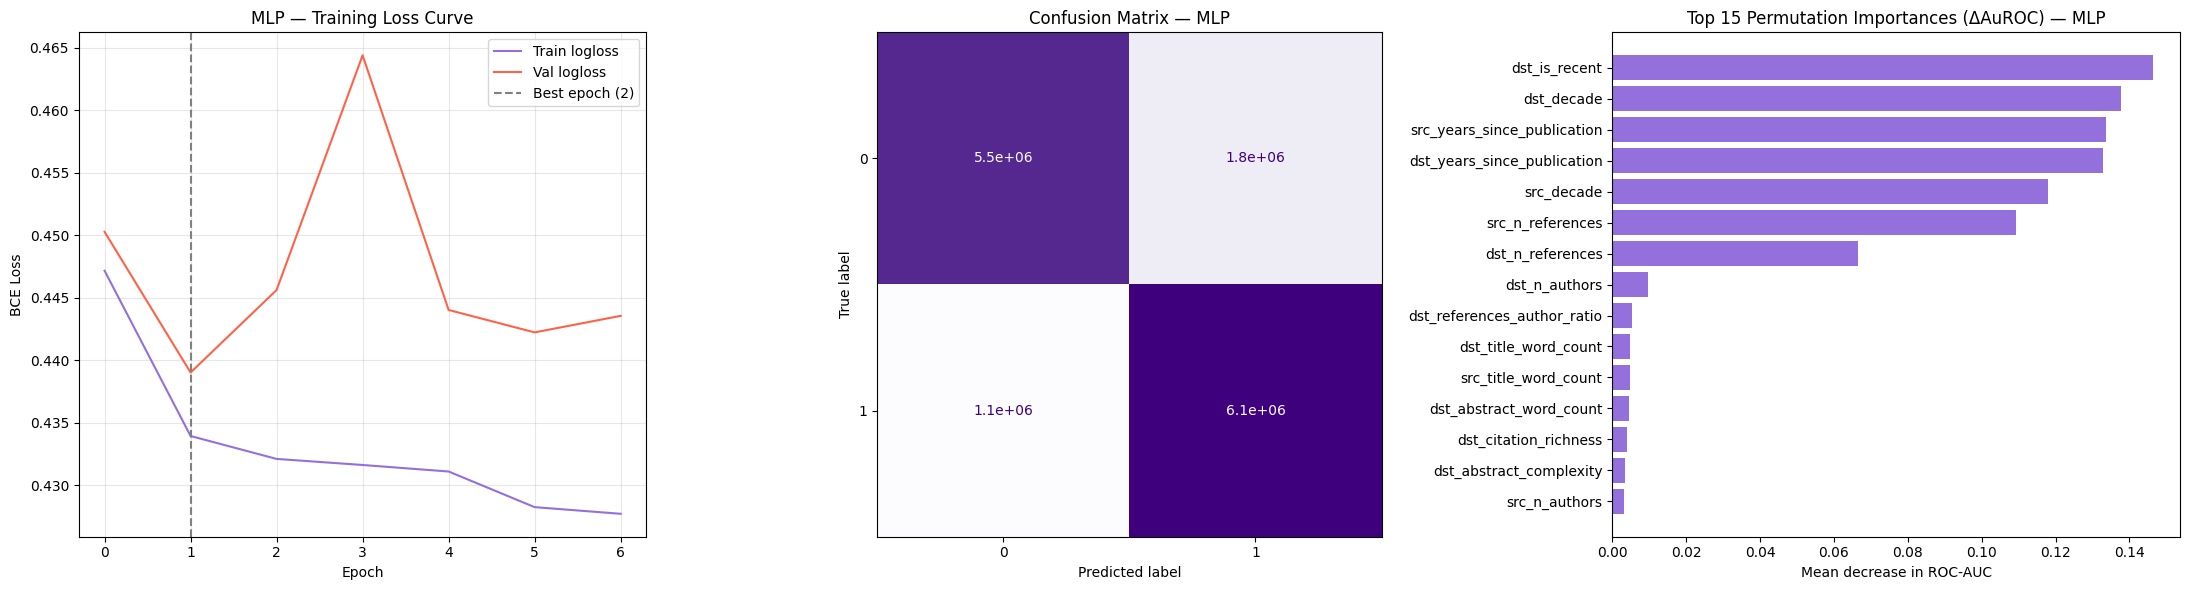

,feature,importance
32,dst_is_recent,0.146357
31,dst_decade,0.137691
13,src_years_since_publication,0.133588
30,dst_years_since_publication,0.132697
14,src_decade,0.117810
9,src_n_references,0.109179
26,dst_n_references,0.066480
24,dst_n_authors,0.009767
27,dst_references_author_ratio,0.005201
17,dst_title_word_count,0.004810


In [7]:
# MLP — LINK PREDICTION 

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 4096
MAX_EPOCHS = 50
PATIENCE   = 5
LR         = 1e-3
print(f"Using device: {DEVICE}")


# 1. Model definition 
class LinkMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# 2. DataLoaders
def make_loader(X, y, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

train_loader = make_loader(X_train_xgb, y_train_xgb, shuffle=True)
val_loader   = make_loader(X_val_xgb,   y_val_xgb,   shuffle=False)
test_loader  = make_loader(X_test_xgb,  y_test_xgb,  shuffle=False)


# 3. Training loop 
in_dim    = X_train_xgb.shape[1]
mlp_model = LinkMLP(in_dim).to(DEVICE)

pos_weight = torch.tensor(
    [(y_train_xgb == 0).sum() / max((y_train_xgb == 1).sum(), 1)],
    dtype=torch.float32,
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

mlp_train_losses, mlp_val_losses = [], []
best_val_loss  = float("inf")
best_state     = None
epochs_no_improve = 0

print("Training MLP with Early Stopping on Validation Set...")
t0 = time.time()

for epoch in range(1, MAX_EPOCHS + 1):

    # train 
    mlp_model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(yb)
    train_loss = epoch_loss / len(y_train_xgb)

    # validate 
    mlp_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(mlp_model(xb), yb).item() * len(yb)
    val_loss /= len(y_val_xgb)

    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.cpu().clone() for k, v in mlp_model.state_dict().items()}
        epochs_no_improve = 0
        tag = " ✓"
    else:
        epochs_no_improve += 1
        tag = ""

    print(f"  Epoch {epoch:>2} | train={train_loss:.4f}  val={val_loss:.4f}{tag}")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

mlp_train_time_pair = time.time() - t0
best_epoch     = epoch - epochs_no_improve
print(f"Best epoch: {best_epoch}  |  Training time: {mlp_train_time_pair:.1f}s")

# Restore best weights
mlp_model.load_state_dict(best_state)


# 4. Inference
def predict_proba(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(DEVICE))
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)

mlp_probs_pair = predict_proba(mlp_model, test_loader)
mlp_preds = (mlp_probs_pair >= 0.5).astype(int)


# 5. Evaluation 
print("\n--- MLP Link Prediction (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_test_xgb,  mlp_probs_pair):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test_xgb, mlp_probs_pair):.4f}")
print(f"Brier   : {brier_score_loss(y_test_xgb, mlp_probs_pair):.4f}")
print("\nClassification report:")
print(classification_report(y_test_xgb, mlp_preds, digits=4))


# 6. Permutation importance (on a 5k subsample)
print("Computing permutation importance (subsample)...")
N_IMP = min(5000, len(X_test_xgb))
rng   = np.random.default_rng(42)
idx   = rng.choice(len(X_test_xgb), size=N_IMP, replace=False)
X_sub, y_sub = X_test_xgb[idx], y_test_xgb[idx]

# Wrap MLP as a sklearn-compatible scorer
def mlp_roc_score(X, y):
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    p = predict_proba(mlp_model, loader)
    return roc_auc_score(y, p)

base_score = mlp_roc_score(X_sub, y_sub)
n_features = X_sub.shape[1]
imp_scores  = np.zeros(n_features)

for i in range(n_features):
    X_perm        = X_sub.copy()
    X_perm[:, i]  = rng.permutation(X_perm[:, i])
    imp_scores[i] = base_score - mlp_roc_score(X_perm, y_sub)

mlp_importance_df = (
    pd.DataFrame({"feature": feature_names_xgb, "importance": imp_scores})
    .sort_values("importance", ascending=False)
    .head(15)
)


# 7. Plots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Loss curve
axes[0].plot(mlp_train_losses, label="Train logloss", color="mediumpurple", linewidth=1.5)
axes[0].plot(mlp_val_losses,   label="Val logloss",   color="tomato",       linewidth=1.5)
axes[0].axvline(best_epoch - 1, color="gray", linestyle="--",
                label=f"Best epoch ({best_epoch})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("MLP — Training Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confusion matrix
cm_mlp = confusion_matrix(y_test_xgb, mlp_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_mlp).plot(
    cmap="Purples", ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — MLP")

# Feature importance
axes[2].barh(
    mlp_importance_df["feature"][::-1],
    mlp_importance_df["importance"][::-1],
    color="mediumpurple",
)
axes[2].set_title("Top 15 Permutation Importances (ΔAuROC) — MLP")
axes[2].set_xlabel("Mean decrease in ROC-AUC")

plt.tight_layout()
plt.show()

display(mlp_importance_df)


# COMPARISON FOR CLASSIC FEATURES


═════════════════════════════════════════════════════════════════════════════════════
                              ULTIMATE FAIR COMPARISON                               
═════════════════════════════════════════════════════════════════════════════════════
Metric          | Random Forest |   LightGBM    |  MLP (Pair)  
─────────────────────────────────────────────────────────────────────────────────────
ROC-AUC         |        0.8563 |        0.8580 |        0.8793
PR-AUC          |        0.8557 |        0.8589 |        0.8729
Brier           |        0.1564 |        0.1551 |        0.1446
Train time (s)  |         971.8 |          62.7 |        1546.4
═════════════════════════════════════════════════════════════════════════════════════



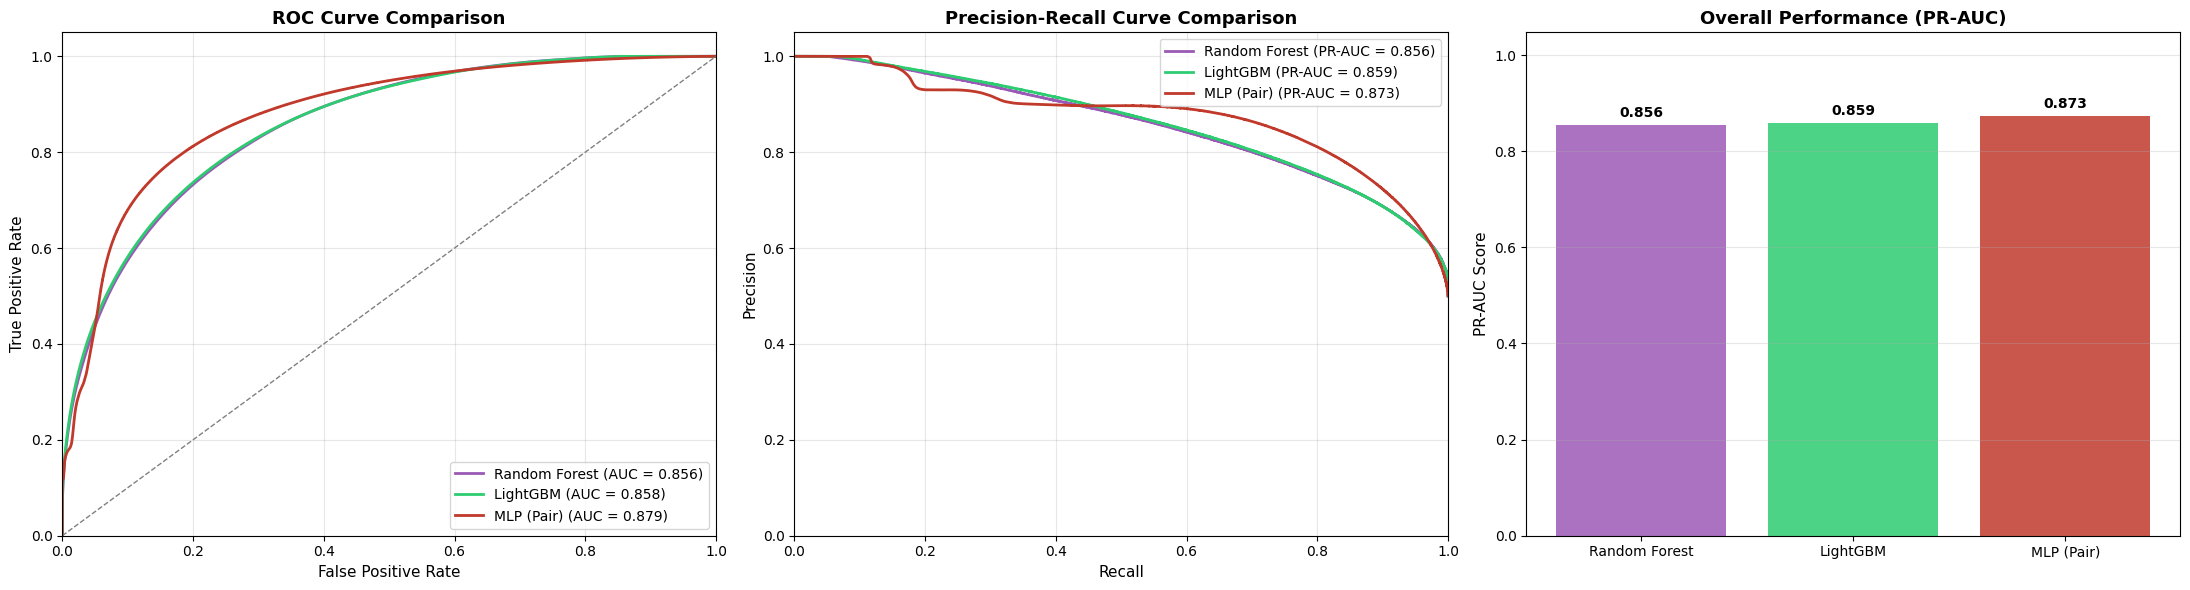


═════════════════════════════════════════════════════════════════════════════════════
                       SHAP EXPLAINABILITY (Tree-Based Models)                       
═════════════════════════════════════════════════════════════════════════════════════
Computing SHAP values on a 1k sample to optimize performance...

>> Generating SHAP plot for LightGBM...


c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


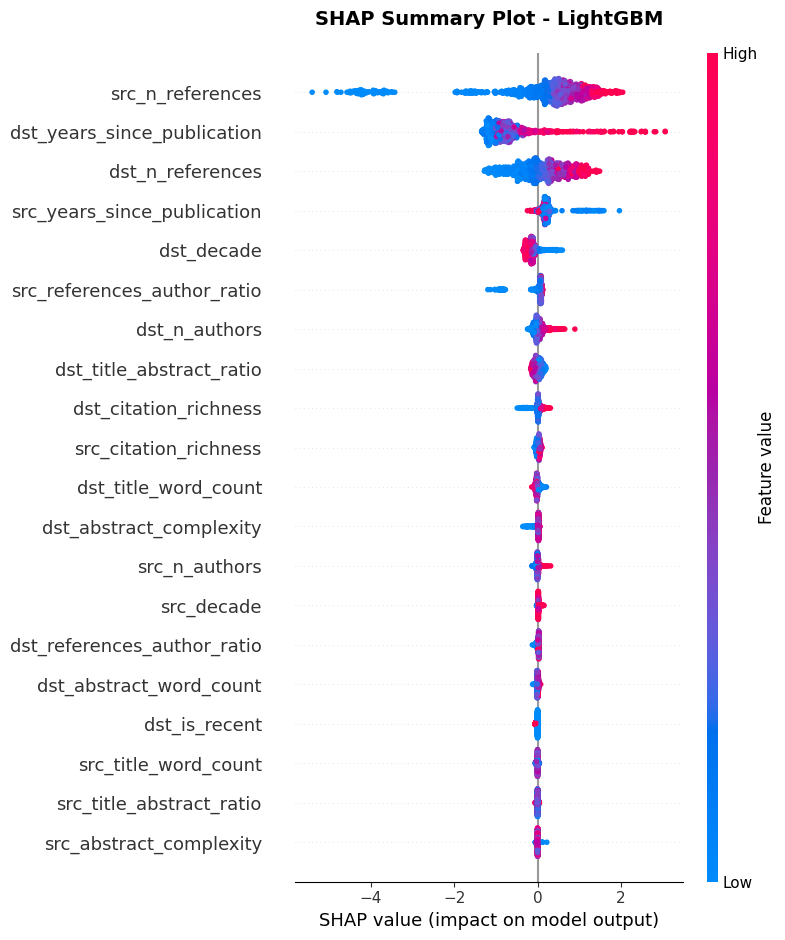

>> Generating SHAP plot for Random Forest...


In [ ]:
import shap

# ULTIMATE MODEL COMPARISON & SHAP EXPLAINABILITY         

# Dynamically gather available models
models_info = {}

if 'rf_probs' in globals():
    models_info['Random Forest'] = {'probs': rf_probs, 'time': rf_train_time, 'color': '#9b59b6'}
if 'lgbm_probs' in globals():
    models_info['LightGBM'] = {'probs': lgbm_probs, 'time': lgbm_train_time, 'color': '#2ecc71'}
if 'mlp_probs_pair' in globals():
    models_info['MLP (Pair)'] = {'probs': mlp_probs_pair, 'time': mlp_train_time_pair, 'color': '#c0392b'}

if not models_info:
    print("No models found in memory! Please run the training cells first.")
else:
    # 1. TEXT SUMMARY TABLE 
    print("\n" + "═"*85)
    print(f"{'ULTIMATE FAIR COMPARISON':^85}")
    print("═"*85)
    print(f"{'Metric':<15} | " + " | ".join([f"{name:^13}" for name in models_info.keys()]))
    print("─"*85)
    
    metrics_calc = {'ROC-AUC': [], 'PR-AUC': [], 'Brier': [], 'Train Time': []}
    
    for name, data in models_info.items():
        metrics_calc['ROC-AUC'].append(roc_auc_score(y_test_xgb, data['probs']))
        metrics_calc['PR-AUC'].append(average_precision_score(y_test_xgb, data['probs']))
        metrics_calc['Brier'].append(brier_score_loss(y_test_xgb, data['probs']))
        metrics_calc['Train Time'].append(data['time'])
        
    print(f"{'ROC-AUC':<15} | " + " | ".join([f"{v:>13.4f}" for v in metrics_calc['ROC-AUC']]))
    print(f"{'PR-AUC':<15} | " + " | ".join([f"{v:>13.4f}" for v in metrics_calc['PR-AUC']]))
    print(f"{'Brier':<15} | " + " | ".join([f"{v:>13.4f}" for v in metrics_calc['Brier']]))
    print(f"{'Train time (s)':<15} | " + " | ".join([f"{v:>13.1f}" for v in metrics_calc['Train Time']]))
    print("═"*85 + "\n")

    # 2. COMPARISON PLOTS 
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    
    # ROC Curve
    for name, data in models_info.items():
        fpr, tpr, _ = roc_curve(y_test_xgb, data['probs'])
        auc_val = metrics_calc['ROC-AUC'][list(models_info.keys()).index(name)]
        axes[0].plot(fpr, tpr, color=data['color'], lw=2, label=f"{name} (AUC = {auc_val:.3f})")
    
    axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=11)
    axes[0].set_ylabel('True Positive Rate', fontsize=11)
    axes[0].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # Precision-Recall Curve
    for name, data in models_info.items():
        precision, recall, _ = precision_recall_curve(y_test_xgb, data['probs'])
        pr_auc_val = metrics_calc['PR-AUC'][list(models_info.keys()).index(name)]
        axes[1].plot(recall, precision, color=data['color'], lw=2, label=f"{name} (PR-AUC = {pr_auc_val:.3f})")
    
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall', fontsize=11)
    axes[1].set_ylabel('Precision', fontsize=11)
    axes[1].set_title('Precision-Recall Curve Comparison', fontsize=13, fontweight='bold')
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)

    # PR-AUC Bar Chart
    names = list(models_info.keys())
    pr_scores = metrics_calc['PR-AUC']
    colors = [models_info[n]['color'] for n in names]
    
    bars = axes[2].bar(names, pr_scores, color=colors, alpha=0.85)
    axes[2].set_ylim([0, max(pr_scores) * 1.2])
    axes[2].set_ylabel('PR-AUC Score', fontsize=11)
    axes[2].set_title('Overall Performance (PR-AUC)', fontsize=13, fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)
    
    for bar in bars:
        yval = bar.get_height()
        axes[2].text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 3. SHAP EXPLAINABILITY 
    
    print("\n" + "═"*85)
    print(f"{'SHAP EXPLAINABILITY (Tree-Based Models)':^85}")
    print("═"*85)
    print("Computing SHAP values on a 1k sample to optimize performance...\n")

    # Convert test array to DataFrame for SHAP feature names, sample 1000 rows
    X_shap = pd.DataFrame(X_test_xgb, columns=feature_names_xgb).sample(n=min(1000, len(X_test_xgb)), random_state=42)

    # 3a. LightGBM SHAP
    if 'lgbm_model' in globals():
        print(">> Generating SHAP plot for LightGBM...")
        explainer_lgb = shap.TreeExplainer(lgbm_model)
        shap_values_lgb = explainer_lgb.shap_values(X_shap)
        # Handle binary classification output formats
        shap_vals = shap_values_lgb[1] if isinstance(shap_values_lgb, list) else shap_values_lgb
        
        plt.figure(figsize=(10, 6))
        plt.title("SHAP Summary Plot - LightGBM", fontsize=14, fontweight='bold', pad=20)
        shap.summary_plot(shap_vals, X_shap, show=False)
        plt.tight_layout()
        plt.show()
        
    # 3b. Random Forest SHAP
    if 'rf_model' in globals():
        print(">> Generating SHAP plot for Random Forest...")
        explainer_rf = shap.TreeExplainer(rf_model)
        shap_values_rf = explainer_rf.shap_values(X_shap)
        shap_vals = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf
        
        plt.figure(figsize=(10, 6))
        plt.title("SHAP Summary Plot - Random Forest", fontsize=14, fontweight='bold', pad=20)
        shap.summary_plot(shap_vals, X_shap, show=False)
        plt.tight_layout()
        plt.show()

# MODEL 4 -> Random Forest, using pair-level features

## Pair-Level Baseline for Citation Link Prediction

The GCN section models the citation graph directly. For this target, the supervised example is a **paper pair**: source paper $A$ and candidate target paper $B$, with label $y=1$ if $A$ cites $B$ and $y=0$ otherwise.

That means the right tabular baseline should:
- build one row per paper pair,
- use only metadata available before the link decision,
- avoid citation-count leakage such as `n_citation` or `impact_score`,
- stay interpretable so the team can explain the result with SHAP and uncertainty.

Below, the notebook builds pair-level features from what is already in the dataset: authors, keywords, titles, abstracts, venue, year, and reference lists.

In [ ]:
import re
import random
from bisect import bisect_right

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import shap

random.seed(42)
np.random.seed(42)


In [ ]:
def as_list(value):
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, list):
        return value
    if isinstance(value, tuple):
        return list(value)
    return [value]


def normalize_scalar(value):
    if value is None:
        return ""
    if isinstance(value, float) and np.isnan(value):
        return ""
    text = str(value).strip().lower()
    return re.sub(r"\s+", " ", text)


def extract_author_names(authors):
    names = set()
    for item in as_list(authors):
        if isinstance(item, dict):
            name = item.get("name")
        elif hasattr(item, "get"):
            name = item.get("name")
        else:
            name = item
        name = normalize_scalar(name)
        if name:
            names.add(name)
    return names


def extract_strings(values):
    items = set()
    for item in as_list(values):
        token = normalize_scalar(item)
        if token:
            items.add(token)
    return items


def safe_int(value):
    if value is None:
        return 0
    if isinstance(value, float) and np.isnan(value):
        return 0
    return int(value)


def tokenize_text(text):
    text = normalize_scalar(text)
    if not text:
        return set()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return {tok for tok in text.split() if tok}


def jaccard(left, right):
    union = left | right
    if not union:
        return 0.0
    return len(left & right) / len(union)


Up to this point, our Exploratory Data Analysis (EDA) focused on **Node-Level Features**—metrics describing individual papers (e.g., `impact_score`, `citation_per_year`, `venue_tier`). While these are excellent for understanding global trends, our ultimate machine learning goal is **Link Prediction**: determining whether Paper A cites Paper B.

To predict links, we cannot look at papers in isolation. We must evaluate the *relationship* between them. 

If we try to predict a citation by feeding the model Paper B's total `impact_score` or `n_citation`, the model will suffer from **Target Leakage**. It would simply learn to predict that "highly cited papers get cited," effectively using future knowledge (citations accumulated up to 2024) to predict a past event. 

Instead, we force the model to rely purely on information available at the exact moment of publication. We do this by calculating **Pair-Level Features**:
1. **Jaccard Similarities:** We measure the mathematical overlap between the two papers' metadata (Authors, Keywords, References, Titles, and Abstracts). A higher Jaccard index implies stronger topical or social proximity.
2. **Temporal Features:** We calculate `year_gap` to understand the age difference between the citing and cited paper, and boolean flags like `same_decade` to capture chronological clustering.
3. **Venue & Overlap Flags:** Simple binary indicators (e.g., `same_venue`, `author_overlap_any`) to capture direct matches.

By constructing a balanced dataset of 10,000 pairs (50% actual citations, 50% random non-citations), we frame the link prediction task as a binary classification problem based purely on relational similarity.

In [ ]:
print("Building pair-level dataset from paper metadata and reference links...")

all_ids_years = con.sql("""
SELECT id, year
FROM papers
WHERE id IS NOT NULL AND TRIM(id) <> '' AND year IS NOT NULL
""").df()

print(f"Indexed {len(all_ids_years):,} paper ids with year metadata")

Building pair-level dataset from paper metadata and reference links...
Indexed 6,729,828 paper ids with year metadata


In [ ]:

positive_pairs = con.sql("""
SELECT DISTINCT
    p.id AS src_id,
    ref AS dst_id
FROM papers p
CROSS JOIN UNNEST(p."references") AS t(ref)
JOIN papers d ON d.id = ref
WHERE p.id IS NOT NULL
  AND d.id IS NOT NULL
  AND TRIM(p.id) <> ''
  AND TRIM(ref) <> ''
  AND p.id <> ref
  AND p.year IS NOT NULL
  AND d.year IS NOT NULL
""").df()

if positive_pairs.empty:
    raise RuntimeError("No citation edges were found in the dataset.")

In [ ]:
sample_n = min(50000, len(positive_pairs))
positive_pairs = positive_pairs.sample(n=sample_n, random_state=42).reset_index(drop=True)

# Build a full paper-id/year index for negative sampling.
all_id_to_year = dict(zip(all_ids_years["id"], all_ids_years["year"]))
all_years_sorted = sorted(all_ids_years["year"].dropna().astype(int).unique().tolist())
all_ids_by_year = {year: all_ids_years.loc[all_ids_years["year"] == year, "id"].tolist() for year in all_years_sorted}
all_prefix_ids = {}
running_ids = []
for year in all_years_sorted:
    running_ids.extend(all_ids_by_year[year])
    all_prefix_ids[year] = running_ids.copy()

# Only fetch the reference lists for the sampled source papers.
source_ids_df = pd.DataFrame({"id": positive_pairs["src_id"].unique()})
con.register("source_ids", source_ids_df)
source_refs_df = con.sql("""
SELECT p.id, p."references" AS refs
FROM papers p
JOIN source_ids s ON p.id = s.id
""").df()
source_ref_lookup = {row.id: extract_strings(row.refs) for row in source_refs_df.itertuples(index=False)}

# Alias names used by the following cell.
id_to_year = all_id_to_year
years_sorted = all_years_sorted
prefix_ids = all_prefix_ids
id_to_refs = source_ref_lookup

# Sample negatives from all papers that are not already cited by the source.
def sample_negative_target(src_id):
    src_year = id_to_year[src_id]
    idx = bisect_right(years_sorted, src_year) - 1
    if idx < 0:
        return None
    pool_year = years_sorted[idx]
    pool = prefix_ids[pool_year]
    banned = id_to_refs.get(src_id, set()) | {src_id}
    if len(pool) <= len(banned):
        return None
    for _ in range(50):
        candidate = random.choice(pool)
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    for candidate in random.sample(pool, min(len(pool), 200)):
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    return None

negative_rows = []
for src_id in positive_pairs["src_id"].tolist():
    dst_id = sample_negative_target(src_id)
    if dst_id is not None:
        negative_rows.append((src_id, dst_id))

negative_pairs = pd.DataFrame(negative_rows, columns=["src_id", "dst_id"])
if negative_pairs.empty:
    raise RuntimeError("Failed to sample negative pairs.")

positive_pairs = positive_pairs.iloc[: len(negative_pairs)].copy()
positive_pairs["label"] = 1
negative_pairs["label"] = 0
pair_df = pd.concat([positive_pairs, negative_pairs], ignore_index=True)
pair_df = pair_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Fetch only the paper metadata that actually appears in the sampled pairs.
pair_ids_df = pd.DataFrame({"id": pd.unique(pd.concat([pair_df["src_id"], pair_df["dst_id"]], ignore_index=True))})
con.register("pair_ids", pair_ids_df)
papers_df = con.sql("""
SELECT
    id,
    year,
    venue,
    title,
    abstract,
    authors,
    keywords,
    "references" AS refs,
    n_authors,
    n_keywords,
    n_references,
    title_len,
    abstract_len
FROM papers
WHERE id IN (SELECT id FROM pair_ids)
""").df()

paper_lookup = papers_df.set_index("id").to_dict(orient="index")

print(f"Sampled positive pairs: {len(positive_pairs):,}")
print(f"Sampled negative pairs: {len(negative_pairs):,}")
print(f"Fetched metadata for {len(papers_df):,} unique papers involved in the sampled pairs.")

Sampled positive pairs: 49,998
Sampled negative pairs: 49,998
Fetched metadata for 143,505 unique papers involved in the sampled pairs.


In [ ]:
def sample_negative_target(src_id):
    src_year = id_to_year[src_id]
    idx = bisect_right(years_sorted, src_year) - 1
    if idx < 0:
        return None
    pool_year = years_sorted[idx]
    pool = prefix_ids[pool_year]
    banned = id_to_refs.get(src_id, set()) | {src_id}
    if len(pool) <= len(banned):
        return None
    for _ in range(50):
        candidate = random.choice(pool)
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    for candidate in random.sample(pool, min(len(pool), 200)):
        if candidate not in banned and id_to_year.get(candidate, src_year) <= src_year:
            return candidate
    return None

In [ ]:
print(f"Pair table ready: {len(pair_df):,} rows")
display(pair_df.head())

Pair table ready: 99,996 rows


,src_id,dst_id,label
0,64a638fbd68f896efae9a4bb,53e9be1ab7602d9704ad5b1a,1
1,6363316f90e50fcafd4fbd6b,5eede0b091e0116a23aafb82,1
2,64af72f53fda6d7f06446074,53e9b316b7602d9703ddcc38,1
3,599c7d64601a182cd281f83e,55465d7d0cf2939c2fee7464,1
4,64f561663fda6d7f06f1c6f0,639c912e90e50fcafd4ccf3e,1


## The Tabular Supervised Baseline (Random Forest)

### The Objective
Before deploying a complex, graph-native approach (like a Graph Convolutional Network), it is best practice to establish a robust **Supervised Tabular Baseline**. We use a Random Forest Classifier for this task because it handles non-linear relationships well, is robust to outliers in our text similarities, and provides excellent interpretability without requiring feature scaling.

### Feature Selection
Notice the `feature_cols` list below. **We strictly exclude all individual quality metrics** (`impact_score`, `venue_tier`, `n_citation`). The model is only allowed to see:
* Jaccard similarities (Text, Authors, References)
* Temporal distances (`year_gap`, `same_year`)
* Absolute lengths (Number of authors, abstract length)

This ensures our model genuinely learns *why* citations happen based on content and context, rather than "cheating" by looking at global popularity metrics.

### Model Configuration & Evaluation Strategy
1. **Stratified Splitting:** We use an 80/20 train-test split, stratified on our target `label` to ensure perfectly balanced classes in both sets.
2. **Hyperparameters:** We configure the Random Forest with `n_estimators=300` for stability, `min_samples_leaf=2` to prevent overfitting on highly specific paper pairs, and `class_weight="balanced_subsample"` to handle bootstrap-level imbalances.
3. **Interpretability:** Beyond standard metrics (ROC-AUC, PR-AUC, F1-Score), we prioritize interpretability. We utilize **Permutation Importance** (and SHAP values, if available) to explicitly rank which pair-level signals drive citation decisions, and we calculate the **Brier Score** to ensure our predicted citation probabilities are well-calibrated.

In [ ]:
def build_pair_features(src_id, dst_id, label):
    src = paper_lookup[src_id]
    dst = paper_lookup[dst_id]

    src_authors  = extract_author_names(src["authors"])
    dst_authors  = extract_author_names(dst["authors"])
    src_keywords = extract_strings(src["keywords"])
    dst_keywords = extract_strings(dst["keywords"])
    src_refs     = extract_strings(src["refs"])
    dst_refs     = extract_strings(dst["refs"])
    src_title    = tokenize_text(src["title"])
    dst_title    = tokenize_text(dst["title"])
    src_abstract = tokenize_text(src["abstract"])
    dst_abstract = tokenize_text(dst["abstract"])

    src_venue = normalize_scalar(src["venue"])
    dst_venue = normalize_scalar(dst["venue"])
    src_year  = int(src["year"])
    dst_year  = int(dst["year"])

    author_overlap  = len(src_authors & dst_authors)
    keyword_overlap = len(src_keywords & dst_keywords)
    ref_overlap     = len(src_refs & dst_refs)

    year_gap        = src_year - dst_year
    keyword_jaccard = jaccard(src_keywords, dst_keywords)

    return {
        "src_id":  src_id,
        "dst_id":  dst_id,
        "label":   label,

        # --- Temporal ---
        "year_gap":           year_gap,
        "src_year":           src_year,
        "dst_year":           dst_year,
        "same_year":          int(src_year == dst_year),
        "same_decade":        int(src_year // 10 == dst_year // 10),
        "source_not_earlier": int(src_year >= dst_year),

        # --- Venue ---
        "same_venue": int(src_venue != "" and src_venue == dst_venue),

        # --- Author ---
        "author_overlap":     author_overlap,
        "author_overlap_any": int(author_overlap > 0),
        "author_jaccard":     jaccard(src_authors, dst_authors),

        # --- Textual ---
        "keyword_overlap":     keyword_overlap,
        "keyword_overlap_any": int(keyword_overlap > 0),
        "keyword_jaccard":     keyword_jaccard,
        "title_jaccard":       jaccard(src_title, dst_title),
        "abstract_jaccard":    jaccard(src_abstract, dst_abstract),

        # --- Bibliographic coupling ---
        "bibliographic_coupling":     ref_overlap,
        "bibliographic_coupling_any": int(ref_overlap > 0),
        "reference_jaccard":          jaccard(src_refs, dst_refs),

        # --- Node-level counts (static metadata) ---
        "source_n_authors":    safe_int(src["n_authors"]),
        "dst_n_authors":       safe_int(dst["n_authors"]),
        "source_n_keywords":   safe_int(src["n_keywords"]),
        "dst_n_keywords":      safe_int(dst["n_keywords"]),
        "source_n_references": safe_int(src["n_references"]),
        "dst_n_references":    safe_int(dst["n_references"]),
        "source_title_len":    safe_int(src["title_len"]),
        "dst_title_len":       safe_int(dst["title_len"]),
        "source_abstract_len": safe_int(src["abstract_len"]),
        "dst_abstract_len":    safe_int(dst["abstract_len"]),
    }


In [ ]:
pair_feature_rows = [build_pair_features(row.src_id, row.dst_id, int(row.label)) for row in pair_df.itertuples(index=False)]
pair_features_df = pd.DataFrame(pair_feature_rows)

In [ ]:

print(f"Pair rows built: {len(pair_features_df):,}")
display(pair_features_df.head())


Pair rows built: 99,996


,src_id,dst_id,label,year_gap,src_year,dst_year,same_year,same_decade,source_not_earlier,same_venue,...,source_n_authors,dst_n_authors,source_n_keywords,dst_n_keywords,source_n_references,dst_n_references,source_title_len,dst_title_len,source_abstract_len,dst_abstract_len
0,64a638fbd68f896efae9a4bb,53e9be1ab7602d9704ad5b1a,1,8,2020,2012,0,0,1,0,...,3,2,1,19,14,9,62,61,489,786
1,6363316f90e50fcafd4fbd6b,5eede0b091e0116a23aafb82,1,3,2023,2020,0,1,1,0,...,3,6,4,3,53,53,24,75,1406,1484
2,64af72f53fda6d7f06446074,53e9b316b7602d9703ddcc38,1,10,2023,2013,0,0,1,1,...,3,6,4,4,17,30,74,48,1374,1035
3,599c7d64601a182cd281f83e,55465d7d0cf2939c2fee7464,1,1,2015,2014,0,1,1,0,...,4,3,12,4,9,13,65,73,1175,1388
4,64f561663fda6d7f06f1c6f0,639c912e90e50fcafd4ccf3e,1,1,2023,2022,0,1,1,0,...,2,5,4,5,12,11,86,66,1522,1290


In [ ]:
feature_cols = [
    "year_gap",
    "src_year",
    "dst_year",
    "same_year",
    "source_not_earlier",
    "same_venue",
    "author_overlap",
    "author_overlap_any",
    "author_jaccard",
    "keyword_overlap",
    "keyword_overlap_any",
    "keyword_jaccard",
    "title_jaccard",
    "abstract_jaccard",
    "bibliographic_coupling",
    "bibliographic_coupling_any",
    "reference_jaccard",
    "source_n_authors",
    "dst_n_authors",
    "source_n_keywords",
    "dst_n_keywords",
    "source_n_references",
    "dst_n_references",
    "source_title_len",
    "dst_title_len",
    "source_abstract_len",
    "dst_abstract_len",
]

# Strict chronological split by publication year
pair_features_df = pair_features_df.sort_values("src_year").reset_index(drop=True)

train_df = pair_features_df[pair_features_df["src_year"] <= 2020]
val_df   = pair_features_df[(pair_features_df["src_year"] >= 2021) & (pair_features_df["src_year"] <= 2022)]
test_df  = pair_features_df[pair_features_df["src_year"] >= 2023]



X_train = train_df[feature_cols].fillna(0)
X_val   = val_df[feature_cols].fillna(0)
X_test  = test_df[feature_cols].fillna(0)
y_train = train_df["label"].astype(int)
y_val   = val_df["label"].astype(int)
y_test  = test_df["label"].astype(int)

print(f"Train : {len(X_train):,} pairs  (up to year {train_df['src_year'].max()})")
print(f"Val   : {len(X_val):,} pairs   (up to year {val_df['src_year'].max()})")
print(f"Test  : {len(X_test):,} pairs   (up to year {test_df['src_year'].max()})")

Train : 62,406 pairs  (up to year 2020)
Val   : 17,758 pairs   (up to year 2022)
Test  : 19,832 pairs   (up to year 2025)


Train : (62406, 27)  Val : (17758, 27)  Test : (19832, 27)
Pair features used (27): ['year_gap', 'src_year', 'dst_year', 'same_year', 'source_not_earlier', 'same_venue', 'author_overlap', 'author_overlap_any', 'author_jaccard', 'keyword_overlap', 'keyword_overlap_any', 'keyword_jaccard', 'title_jaccard', 'abstract_jaccard', 'bibliographic_coupling', 'bibliographic_coupling_any', 'reference_jaccard', 'source_n_authors', 'dst_n_authors', 'source_n_keywords', 'dst_n_keywords', 'source_n_references', 'dst_n_references', 'source_title_len', 'dst_title_len', 'source_abstract_len', 'dst_abstract_len']

Training Random Forest...
Training time : 9.3s

--- Random Forest (Test Split) ---
ROC-AUC : 0.9552
PR-AUC  : 0.9639
Brier   : 0.0800
              precision    recall  f1-score   support

           0     0.8497    0.9519    0.8979      9916
           1     0.9453    0.8316    0.8848      9916

    accuracy                         0.8917     19832
   macro avg     0.8975    0.8917    0.8913  

c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best iteration : 416  |  Training time: 1.2s

--- LightGBM (Test Split) ---
ROC-AUC : 0.9583
PR-AUC  : 0.9666
Brier   : 0.0750
              precision    recall  f1-score   support

           0     0.8710    0.9316    0.9003      9916
           1     0.9265    0.8620    0.8931      9916

    accuracy                         0.8968     19832
   macro avg     0.8988    0.8968    0.8967     19832
weighted avg     0.8988    0.8968    0.8967     19832


Training MLP...
  Epoch   1 | train=0.3871  val=0.2699 ✓
  Epoch   2 | train=0.3016  val=0.2664 ✓
  Epoch   3 | train=0.2980  val=0.2646 ✓
  Epoch   4 | train=0.2954  val=0.2632 ✓
  Epoch   5 | train=0.2931  val=0.2631 ✓
  Epoch   6 | train=0.2919  val=0.2625 ✓
  Epoch   7 | train=0.2907  val=0.2616 ✓
  Epoch   8 | train=0.2902  val=0.2612 ✓
  Epoch   9 | train=0.2888  val=0.2612
  Epoch  10 | train=0.2890  val=0.2617
  Epoch  11 | train=0.2885  val=0.2619
  Epoch  12 | train=0.2883  val=0.2631
  Epoch  13 | train=0.2859  val=0.2602 ✓
  Ep

c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Alessio\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.

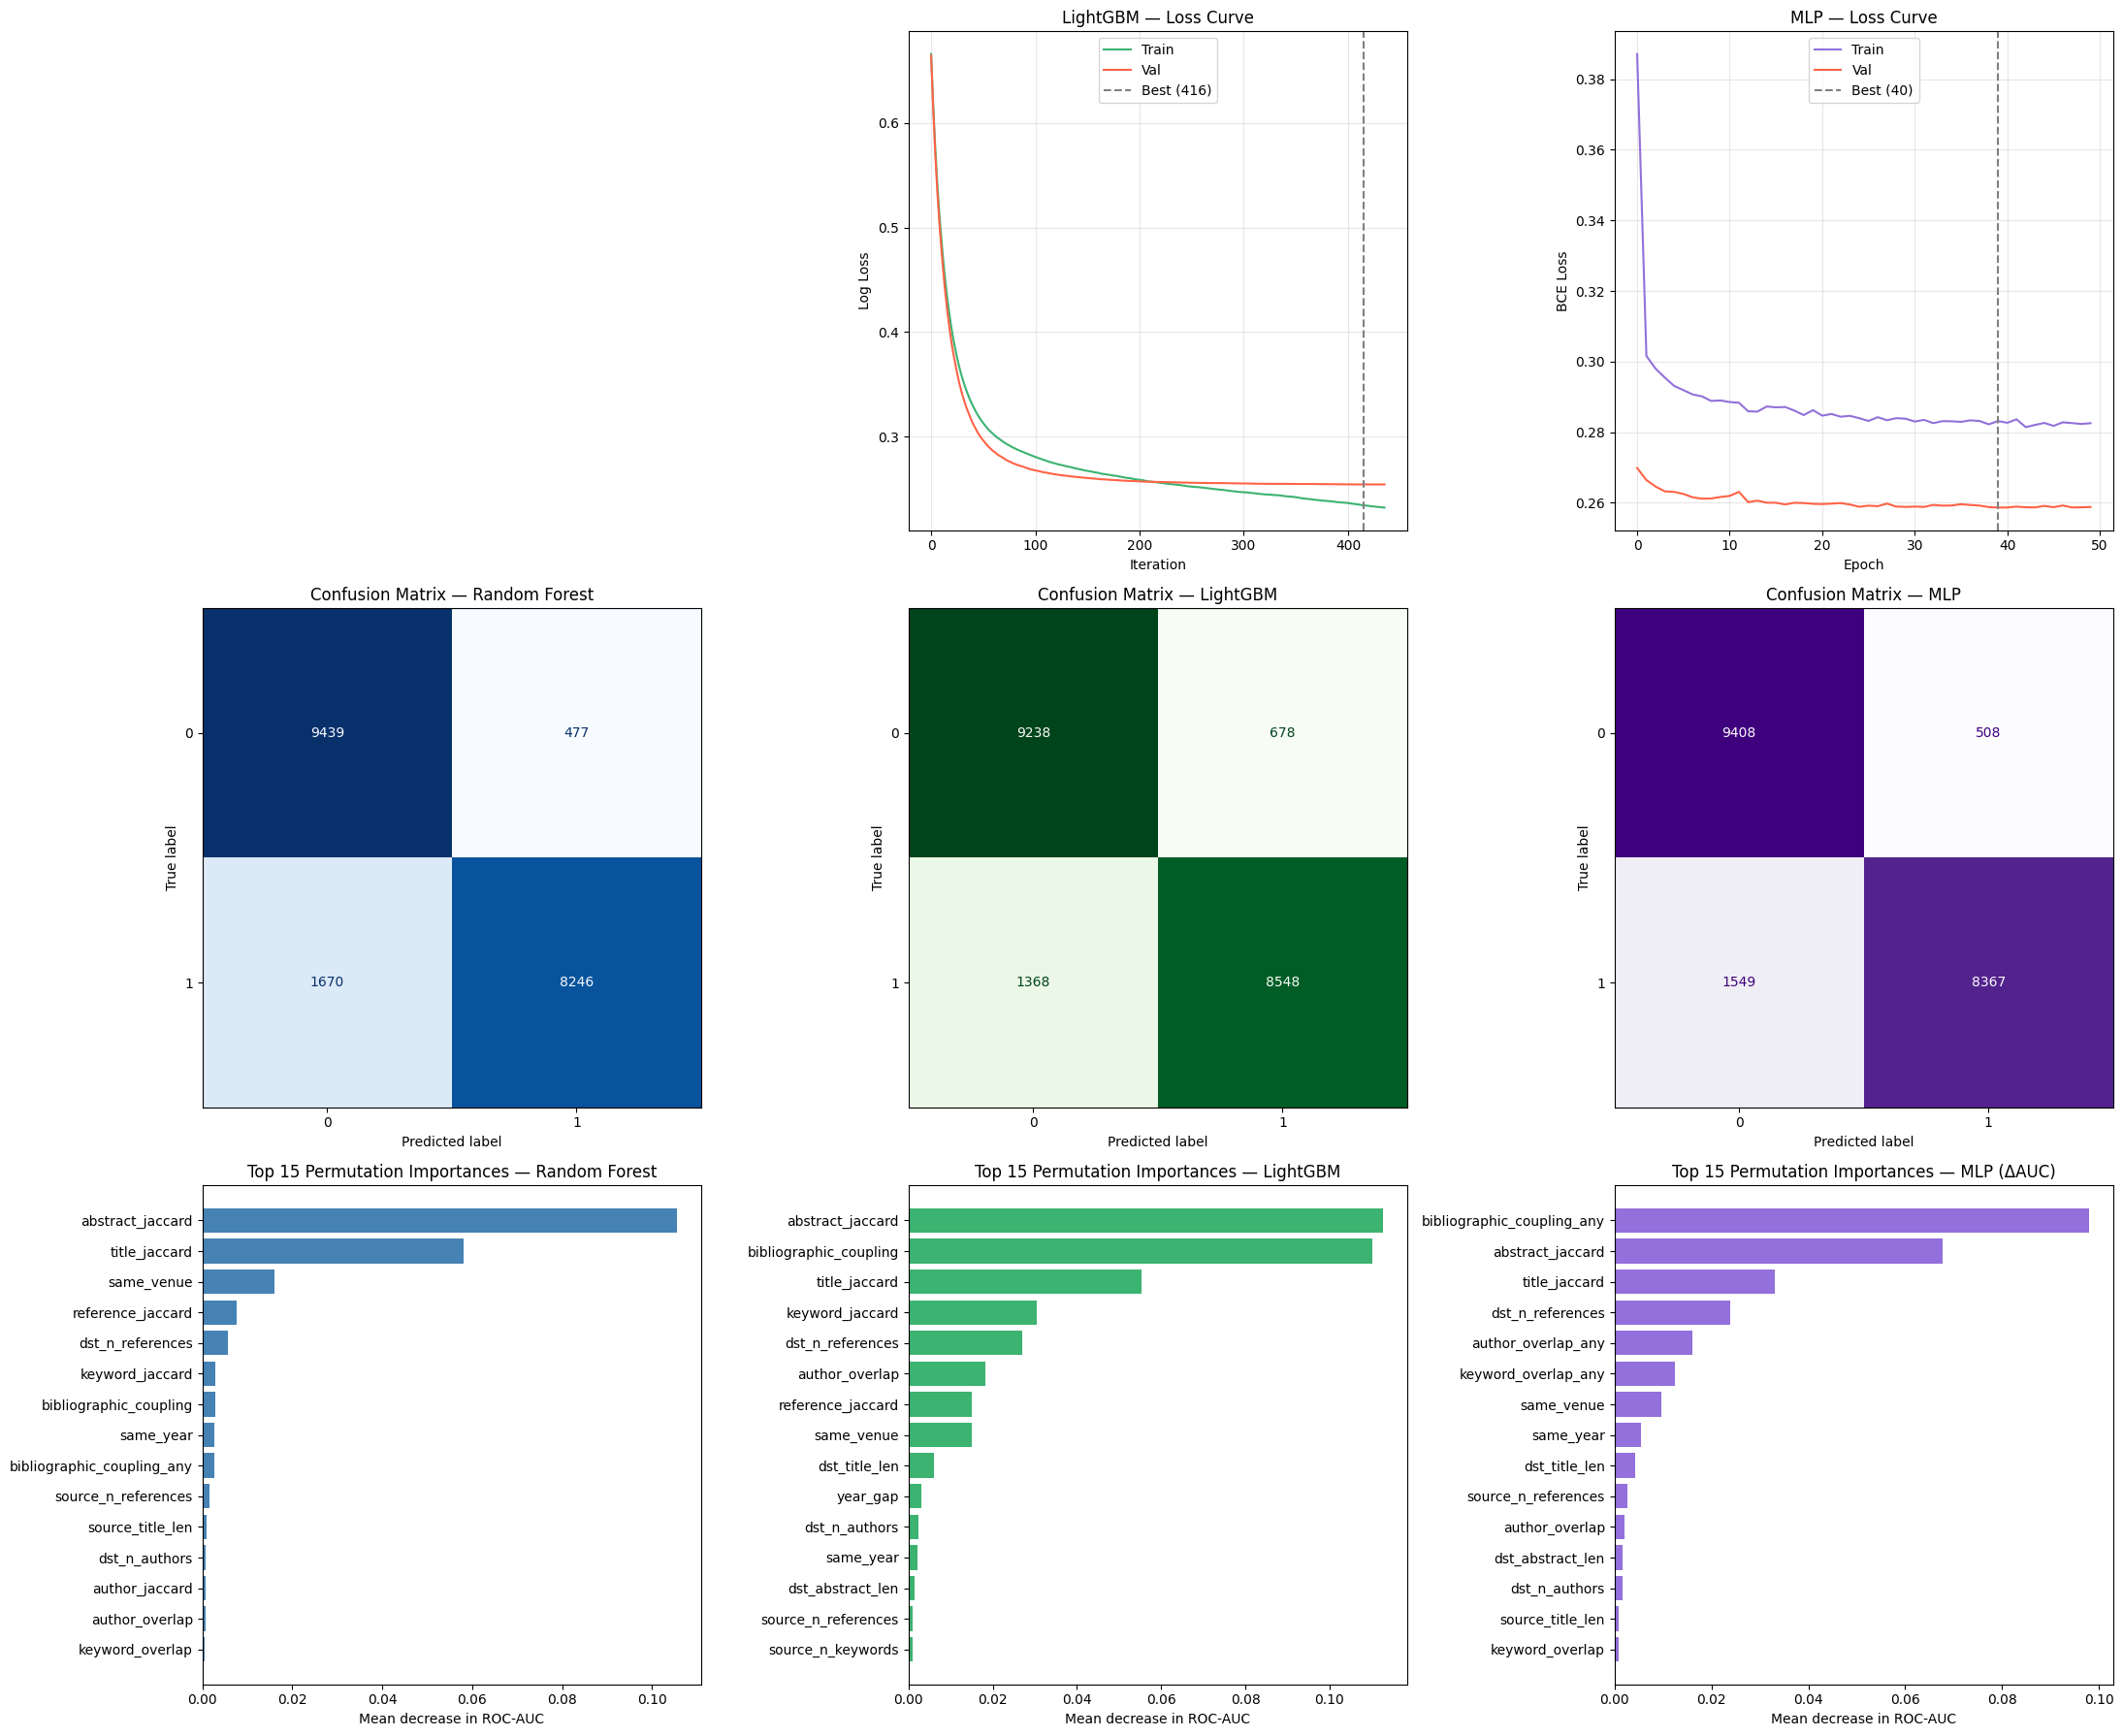


══════════════ FAIR COMPARISON (Pair Features) ══════════════
Metric           Random Forest   LightGBM        MLP
────────────────────────────────────────────────────
ROC-AUC                 0.9552     0.9583     0.9562
PR-AUC                  0.9639     0.9666     0.9652
Brier                   0.0800     0.0750     0.0764
Train time                9.3s       1.2s      53.1s


: 

In [ ]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt


# Convert temporal splits to numpy 
X_tr  = X_train.to_numpy(dtype=np.float32)
X_val = X_val.to_numpy(dtype=np.float32)
X_te  = X_test.to_numpy(dtype=np.float32)

y_tr  = y_train.to_numpy(dtype=np.int32)
y_val = y_val.to_numpy(dtype=np.int32)
y_te  = y_test.to_numpy(dtype=np.int32)

print(f"Train : {X_tr.shape}  Val : {X_val.shape}  Test : {X_te.shape}")
print(f"Pair features used ({len(feature_cols)}): {feature_cols}")


#
# 1. RANDOM FOREST  
# 
print("\n" + "="*60)
print("Training Random Forest...")
t0 = time.time()

rf_model_pair = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    max_depth=15,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
rf_model_pair.fit(X_tr, y_tr)

rf_train_time_pair = time.time() - t0

rf_probs_pair = rf_model_pair.predict_proba(X_te)[:, 1]
rf_preds_pair = (rf_probs_pair >= 0.5).astype(int)

print(f"Training time : {rf_train_time_pair:.1f}s")
print(f"\n--- Random Forest (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_te, rf_probs_pair):.4f}")
print(f"PR-AUC  : {average_precision_score(y_te, rf_probs_pair):.4f}")
print(f"Brier   : {brier_score_loss(y_te, rf_probs_pair):.4f}")
print(classification_report(y_te, rf_preds_pair, digits=4))


# 2. LIGHTGBM 
print("\n" + "="*60)
print("Training LightGBM...")
scale_pos_weight_lgbm = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

lgbm_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.9,
    min_child_samples=20,
    reg_lambda=1.0,
    objective="binary",
    metric="binary_logloss",
    scale_pos_weight=scale_pos_weight_lgbm,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgbm_evals_result = {}
t0 = time.time()
lgbm_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    eval_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=0),
        lgb.record_evaluation(lgbm_evals_result),
    ],
)
lgbm_train_time = time.time() - t0

lgbm_probs = lgbm_model.predict_proba(X_te)[:, 1]
lgbm_preds = (lgbm_probs >= 0.5).astype(int)

print(f"Best iteration : {lgbm_model.best_iteration_}  |  Training time: {lgbm_train_time:.1f}s")
print(f"\n--- LightGBM (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_te, lgbm_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_te, lgbm_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_te, lgbm_probs):.4f}")
print(classification_report(y_te, lgbm_preds, digits=4))


#
# 3. MLP  
print("\n" + "="*60)
print("Training MLP...")

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 512        # smaller: pair features dataset is tiny vs node-feature one
MAX_EPOCHS = 100
PATIENCE   = 10
LR         = 1e-3

# Scale features
scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_te_s  = scaler.transform(X_te).astype(np.float32)

def make_loader(X, y, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

train_loader = make_loader(X_tr_s,  y_tr,  shuffle=True)
val_loader   = make_loader(X_val_s, y_val, shuffle=False)
test_loader  = make_loader(X_te_s,  y_te,  shuffle=False)

class LinkMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

mlp_model = LinkMLP(X_tr_s.shape[1]).to(DEVICE)

pos_weight = torch.tensor(
    [(y_tr == 0).sum() / max((y_tr == 1).sum(), 1)],
    dtype=torch.float32,
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

mlp_train_losses, mlp_val_losses = [], []
best_val_loss, best_state, epochs_no_improve = float("inf"), None, 0

t0 = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    mlp_model.train()
    ep_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item() * len(yb)
    train_loss = ep_loss / len(y_tr)

    mlp_model.eval()
    vl = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            vl += criterion(mlp_model(xb), yb).item() * len(yb)
    val_loss = vl / len(y_val)

    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    scheduler.step(val_loss)

    tag = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in mlp_model.state_dict().items()}
        epochs_no_improve = 0
        tag = " ✓"
    else:
        epochs_no_improve += 1

    print(f"  Epoch {epoch:>3} | train={train_loss:.4f}  val={val_loss:.4f}{tag}")
    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

mlp_train_time = time.time() - t0
best_epoch = epoch - epochs_no_improve
mlp_model.load_state_dict(best_state)

def predict_proba_mlp(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for xb, _ in loader:
            probs.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
    return np.concatenate(probs)

mlp_probs = predict_proba_mlp(mlp_model, test_loader)
mlp_preds = (mlp_probs >= 0.5).astype(int)

print(f"Best epoch: {best_epoch}  |  Training time: {mlp_train_time:.1f}s")
print(f"\n--- MLP (Test Split) ---")
print(f"ROC-AUC : {roc_auc_score(y_te, mlp_probs):.4f}")
print(f"PR-AUC  : {average_precision_score(y_te, mlp_probs):.4f}")
print(f"Brier   : {brier_score_loss(y_te, mlp_probs):.4f}")
print(classification_report(y_te, mlp_preds, digits=4))


# 4. PLOTS
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
model_configs = [
    ("Random Forest", rf_probs_pair,   rf_preds_pair,   "Blues"),
    ("LightGBM",      lgbm_probs, lgbm_preds, "Greens"),
    ("MLP",           mlp_probs,  mlp_preds,  "Purples"),
]

# Row 0: Loss/learning curves
axes[0, 0].set_visible(False)   # RF has no loss curve

lgbm_tl = lgbm_evals_result["train"]["binary_logloss"]
lgbm_vl = lgbm_evals_result["val"]["binary_logloss"]
axes[0, 1].plot(lgbm_tl, color="mediumseagreen", label="Train")
axes[0, 1].plot(lgbm_vl, color="tomato",         label="Val")
axes[0, 1].axvline(lgbm_model.best_iteration_ - 1, color="gray", linestyle="--",
                   label=f"Best ({lgbm_model.best_iteration_})")
axes[0, 1].set_title("LightGBM — Loss Curve")
axes[0, 1].set_xlabel("Iteration"); axes[0, 1].set_ylabel("Log Loss")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(mlp_train_losses, color="mediumpurple", label="Train")
axes[0, 2].plot(mlp_val_losses,   color="tomato",       label="Val")
axes[0, 2].axvline(best_epoch - 1, color="gray", linestyle="--", label=f"Best ({best_epoch})")
axes[0, 2].set_title("MLP — Loss Curve")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("BCE Loss")
axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)

# Row 1: Confusion matrices
for col, (name, _, preds_, cmap) in enumerate(model_configs):
    cm = confusion_matrix(y_te, preds_)
    ConfusionMatrixDisplay(cm).plot(cmap=cmap, ax=axes[1, col], colorbar=False)
    axes[1, col].set_title(f"Confusion Matrix — {name}")

# Row 2: Feature importances
# RF — built-in
# Row 2: Feature importances — all models use same subsample for comparability
N_IMP     = min(2000, len(X_te))
rng_imp   = np.random.default_rng(42)
idx_imp   = rng_imp.choice(len(X_te), N_IMP, replace=False)
X_imp     = X_te[idx_imp]       # unscaled — for RF and LGBM
X_imp_s   = X_te_s[idx_imp]     # scaled   — for MLP
y_imp     = y_te[idx_imp]

# RF
rf_perm = permutation_importance(
    rf_model_pair, X_imp, y_imp, n_repeats=10, random_state=42, n_jobs=1
)
rf_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_perm.importances_mean,
}).sort_values("importance", ascending=False).head(15)
axes[2, 0].barh(rf_imp["feature"][::-1], rf_imp["importance"][::-1], color="steelblue")
axes[2, 0].set_title("Top 15 Permutation Importances — Random Forest")
axes[2, 0].set_xlabel("Mean decrease in ROC-AUC")

# LGBM
lgbm_perm = permutation_importance(
    lgbm_model, X_imp, y_imp, n_repeats=10, random_state=42, n_jobs=1
)
lgbm_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": lgbm_perm.importances_mean,
}).sort_values("importance", ascending=False).head(15)
axes[2, 1].barh(lgbm_imp["feature"][::-1], lgbm_imp["importance"][::-1], color="mediumseagreen")
axes[2, 1].set_title("Top 15 Permutation Importances — LightGBM")
axes[2, 1].set_xlabel("Mean decrease in ROC-AUC")

# MLP — manual loop
def mlp_roc(X, y):
    loader = DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.float32)),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    return roc_auc_score(y, predict_proba_mlp(mlp_model, loader))

base = mlp_roc(X_imp_s, y_imp)
mlp_imp_scores = np.zeros(len(feature_cols))
rng_mlp = np.random.default_rng(42)
for i in range(len(feature_cols)):
    Xp = X_imp_s.copy()
    Xp[:, i] = rng_mlp.permutation(Xp[:, i])
    mlp_imp_scores[i] = base - mlp_roc(Xp, y_imp)

mlp_imp = pd.DataFrame({
    "feature": feature_cols, "importance": mlp_imp_scores
}).sort_values("importance", ascending=False).head(15)
axes[2, 2].barh(mlp_imp["feature"][::-1], mlp_imp["importance"][::-1], color="mediumpurple")
axes[2, 2].set_title("Top 15 Permutation Importances — MLP (ΔAUC)")
axes[2, 2].set_xlabel("Mean decrease in ROC-AUC")


plt.tight_layout()
plt.show()


# 5. FAIR COMPARISON   
print("\n══════════════ FAIR COMPARISON (Pair Features) ══════════════")
print(f"{'Metric':<14} {'Random Forest':>15} {'LightGBM':>10} {'MLP':>10}")
print("─" * 52)
print(f"{'ROC-AUC':<14} {roc_auc_score(y_te, rf_probs_pair):>15.4f} {roc_auc_score(y_te, lgbm_probs):>10.4f} {roc_auc_score(y_te, mlp_probs):>10.4f}")
print(f"{'PR-AUC':<14} {average_precision_score(y_te, rf_probs_pair):>15.4f} {average_precision_score(y_te, lgbm_probs):>10.4f} {average_precision_score(y_te, mlp_probs):>10.4f}")
print(f"{'Brier':<14} {brier_score_loss(y_te, rf_probs_pair):>15.4f} {brier_score_loss(y_te, lgbm_probs):>10.4f} {brier_score_loss(y_te, mlp_probs):>10.4f}")
print(f"{'Train time':<14} {rf_train_time_pair:>14.1f}s {lgbm_train_time:>9.1f}s {mlp_train_time:>9.1f}s")

In [ ]:
import shap
shap.initjs()

N_SHAP = min(500, len(X_te))

# 1. Random Forest
print("Computing SHAP values — Random Forest...")
rf_explainer   = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_te[:N_SHAP])
rf_sv = rf_shap_values[1] if isinstance(rf_shap_values, list) else rf_shap_values

print("Random Forest — Beeswarm")
shap.summary_plot(rf_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="dot")

print("Random Forest — Mean |SHAP|")
shap.summary_plot(rf_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="bar")


# 2. LightGBM 
print("Computing SHAP values — LightGBM...")
lgbm_explainer   = shap.TreeExplainer(lgbm_model)
lgbm_shap_values = lgbm_explainer.shap_values(X_te[:N_SHAP])
lgbm_sv = lgbm_shap_values[1] if isinstance(lgbm_shap_values, list) else lgbm_shap_values

print("LightGBM — Beeswarm")
shap.summary_plot(lgbm_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="dot")

print("LightGBM — Mean |SHAP|")
shap.summary_plot(lgbm_sv, X_te[:N_SHAP], feature_names=feature_cols, plot_type="bar")


# 3. MLP 
print("Computing SHAP values — MLP (may take a minute)...")
N_BG   = min(100, len(X_tr_s))
bg_idx = np.random.default_rng(42).choice(len(X_tr_s), N_BG, replace=False)
background = X_tr_s[bg_idx]

def mlp_predict(X):
    mlp_model.eval()
    with torch.no_grad():
        logits = mlp_model(torch.tensor(X, dtype=torch.float32).to(DEVICE))
        return torch.sigmoid(logits).cpu().numpy()

mlp_explainer   = shap.KernelExplainer(mlp_predict, background)
mlp_shap_values = mlp_explainer.shap_values(X_te_s[:N_SHAP], nsamples=128)

print("MLP — Beeswarm")
shap.summary_plot(mlp_shap_values, X_te_s[:N_SHAP], feature_names=feature_cols, plot_type="dot")

print("MLP — Mean |SHAP|")
shap.summary_plot(mlp_shap_values, X_te_s[:N_SHAP], feature_names=feature_cols, plot_type="bar")

Computing SHAP values — Random Forest...


: 

In [ ]:
from sklearn.calibration import calibration_curve

UNCERTAINTY_THRESH = (0.4, 0.6)   # predictions in this range = uncertain
MC_PASSES          = 50           # forward passes for MC Dropout

# Uncertainty Estimations

# 1. Random Forest — std across trees
print("Computing RF uncertainty (per-tree std)...")
tree_preds = np.array([t.predict_proba(X_te)[:, 1] for t in rf_model.estimators_])
rf_mean    = tree_preds.mean(axis=0)   # == rf_probs
rf_std     = tree_preds.std(axis=0)


# 2. LightGBM — conformal prediction (split conformal)
print("Computing LightGBM conformal prediction intervals...")

# Calibrate on val set: compute nonconformity scores = |y - p_hat|
lgbm_val_probs = lgbm_model.predict_proba(X_val)[:, 1]
nc_scores      = np.abs(y_val.astype(float) - lgbm_val_probs)

ALPHA           = 0.10   # target 90% coverage
q_level         = np.ceil((1 - ALPHA) * (len(nc_scores) + 1)) / len(nc_scores)
q_level         = min(q_level, 1.0)
conformal_q     = np.quantile(nc_scores, q_level)

lgbm_probs_te   = lgbm_model.predict_proba(X_te)[:, 1]
lgbm_lower      = np.clip(lgbm_probs_te - conformal_q, 0, 1)
lgbm_upper      = np.clip(lgbm_probs_te + conformal_q, 0, 1)
lgbm_interval   = lgbm_upper - lgbm_lower
print(f"  Conformal quantile q={conformal_q:.4f}  →  avg interval width: {lgbm_interval.mean():.4f}")


# 3. MLP — MC Dropout
print(f"Computing MLP uncertainty (MC Dropout, {MC_PASSES} passes)...")

def enable_dropout(model):
    """Switch Dropout layers to train mode while keeping rest in eval."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

mlp_model.eval()
enable_dropout(mlp_model)

mc_preds = []
with torch.no_grad():
    for _ in range(MC_PASSES):
        pass_probs = []
        for xb, _ in DataLoader(
            TensorDataset(torch.tensor(X_te_s, dtype=torch.float32),
                          torch.tensor(y_te,   dtype=torch.float32)),
            batch_size=512, shuffle=False,
        ):
            logits = mlp_model(xb.to(DEVICE))
            pass_probs.append(torch.sigmoid(logits).cpu().numpy())
        mc_preds.append(np.concatenate(pass_probs))

mlp_model.eval()   # restore full eval mode
mc_preds   = np.array(mc_preds)          # (MC_PASSES, N_test)
mlp_mean   = mc_preds.mean(axis=0)
mlp_std    = mc_preds.std(axis=0)


# 4. Uncertain predictions 
lo, hi = UNCERTAINTY_THRESH
rf_uncertain   = ((rf_mean   >= lo) & (rf_mean   <= hi)).mean() * 100
lgbm_uncertain = ((lgbm_probs_te >= lo) & (lgbm_probs_te <= hi)).mean() * 100
mlp_uncertain  = ((mlp_mean  >= lo) & (mlp_mean  <= hi)).mean() * 100

print(f"\nUncertain predictions ({lo}–{hi}):")
print(f"  Random Forest : {rf_uncertain:.1f}%")
print(f"  LightGBM      : {lgbm_uncertain:.1f}%")
print(f"  MLP           : {mlp_uncertain:.1f}%")


# 5. Plots
fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle("Uncertainty Analysis — Pair-Level Models", fontsize=15, fontweight="bold")

model_configs = [
    ("Random Forest", rf_mean,       rf_std,         "Blues"),
    ("LightGBM",      lgbm_probs_te, lgbm_interval,  "Greens"),
    ("MLP",           mlp_mean,      mlp_std,         "Purples"),
]
uncertainty_labels = ["Std across trees", "Conformal interval width", "MC Dropout std"]

for col, ((name, probs, uncert, cmap), u_label) in enumerate(zip(model_configs, uncertainty_labels)):

    # Col A: Confidence histogram 
    axes[0, col].hist(probs, bins=50, color=plt.get_cmap(cmap)(0.6), edgecolor="white")
    axes[0, col].axvspan(lo, hi, alpha=0.15, color="red", label=f"Uncertain ({lo}–{hi})")
    axes[0, col].set_title(f"{name} — Predicted Probability Distribution")
    axes[0, col].set_xlabel("Predicted Probability")
    axes[0, col].set_ylabel("Count")
    axes[0, col].legend()

    # Col B: Uncertainty vs confidence scatter 
    axes[1, col].scatter(probs, uncert, alpha=0.3, s=4, color=plt.get_cmap(cmap)(0.6))
    axes[1, col].axvspan(lo, hi, alpha=0.15, color="red")
    axes[1, col].set_title(f"{name} — Uncertainty vs Confidence")
    axes[1, col].set_xlabel("Predicted Probability")
    axes[1, col].set_ylabel(u_label)

    # Col C: Calibration curve
    frac_pos, mean_pred = calibration_curve(y_te, probs, n_bins=10, strategy="uniform")
    axes[2, col].plot(mean_pred, frac_pos, marker="o", color=plt.get_cmap(cmap)(0.7), label=name)
    axes[2, col].plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    axes[2, col].set_title(f"{name} — Calibration Curve")
    axes[2, col].set_xlabel("Mean Predicted Probability")
    axes[2, col].set_ylabel("Fraction of Positives")
    axes[2, col].legend()

plt.tight_layout()
plt.show()


# 6. Summary table 
print("\n══════════════ UNCERTAINTY SUMMARY ══════════════")
print(f"{'Model':<15} {'Avg uncertainty':>17} {'% uncertain preds':>18}")
print("─" * 53)
print(f"{'Random Forest':<15} {rf_std.mean():>17.4f} {rf_uncertain:>17.1f}%")
print(f"{'LightGBM':<15} {lgbm_interval.mean():>17.4f} {lgbm_uncertain:>17.1f}%")
print(f"{'MLP':<15} {mlp_std.mean():>17.4f} {mlp_uncertain:>17.1f}%")

### Why this baseline is a better fit

This section is aligned with the target because each example is explicitly a paper pair. It is also easier to explain:
- SHAP highlights which pair-level signals drive a citation decision,
- uncertainty from the forest shows which predictions are ambiguous,
- the features are interpretable and do not rely on citation-count leakage.

So the narrative is: the GCN is a graph-native approach, but the tabular pair model is the clean supervised baseline for the actual link-classification task.

# Graph Convolutional Network (GCN) — Does Graph Topology Matter?

## Research Question
**How much does structural graph topology matter compared to simple content similarity?**

Our tabular baselines (Random Forest, LightGBM, MLP) predict citation links using only pairwise content features (Jaccard similarities, year gaps, metadata counts). They have **zero knowledge** of the citation network's structure.

A Graph Convolutional Network (GCN), by contrast, propagates information through the citation graph via message-passing. Each node's representation is enriched by the features of its neighbors. If the GCN significantly outperforms the tabular baselines, it means graph topology carries predictive signal beyond what content similarity alone can provide.

### Leakage-Free Design
- **Node features**: We use the exact same 17 safe, non-leaky content features used in the tabular pipeline (text statistics, metadata counts). We explicitly exclude `n_citation`, `impact_score`, `pagerank`, `hub_score`, `authority_score`, and all venue/author citation metrics.
- **Graph edges (message-passing)**: The GCN only sees **training-era edges** (≤ 2020) during training. Validation and test edges are never included in the message-passing graph—they are the edges we try to predict.
- **Temporal split**: Identical to the tabular pipeline (Train ≤ 2020, Val 2021–2022, Test ≥ 2023).


In [ ]:

!pip install torch-geometric


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score
import time

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GCN device: {DEVICE}")


# 1. GCN Model 

class LinkGCN(nn.Module):
    def __init__(self, input_dim, hidden=128, out=64, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden)
        self.bn1   = nn.BatchNorm1d(hidden)
        self.conv2 = GCNConv(hidden, out)
        self.bn2   = nn.BatchNorm1d(out)
        self.conv3 = GCNConv(out, out)
        self.drop  = nn.Dropout(dropout)
        self.W     = nn.Linear(out, out, bias=False)

    def encode(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = self.drop(h)
        h2 = self.conv2(h, edge_index)
        h2 = self.bn2(h2)
        h2 = F.relu(h2)
        h2 = self.drop(h2)
        h3 = self.conv3(h2, edge_index)
        return h2 + h3

    def decode(self, z, edge_label_index):
        src = self.W(z[edge_label_index[0]])
        dst = z[edge_label_index[1]]
        return (src * dst).sum(dim=-1)

    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)


# 2. Sanitize & build tensors

x_all     = torch.tensor(node_feats_test, dtype=torch.float32)
num_nodes = x_all.size(0)

print(f"  Nodes        : {num_nodes:,}")
print(f"  Node features: {x_all.size(1)}")

def sanitize_edges(ei, num_nodes, name="edges"):
    ei = ei.cpu()
    mask = (ei[0] >= 0) & (ei[0] < num_nodes) & \
           (ei[1] >= 0) & (ei[1] < num_nodes)
    n_dropped = (~mask).sum().item()
    if n_dropped:
        print(f"  WARNING: dropped {n_dropped} out-of-bounds edges from {name}")
    return ei[:, mask]

train_pos = sanitize_edges(train_pos, num_nodes, "train_pos")
val_pos   = sanitize_edges(val_pos,   num_nodes, "val_pos")
test_pos  = sanitize_edges(test_pos,  num_nodes, "test_pos")
neg_train = sanitize_edges(neg_train, num_nodes, "neg_train")
neg_val   = sanitize_edges(neg_val,   num_nodes, "neg_val")
neg_test  = sanitize_edges(neg_test,  num_nodes, "neg_test")

msg_edge_index = train_pos

def build_labels(pos_ei, neg_ei):
    ei  = torch.cat([pos_ei, neg_ei], dim=1)
    lbl = torch.cat([torch.ones(pos_ei.size(1)),
                     torch.zeros(neg_ei.size(1))])
    return ei, lbl

val_ei,  val_lbl  = build_labels(val_pos,  neg_val)
test_ei, test_lbl = build_labels(test_pos, neg_test)

print(f"  Msg-pass edges : {msg_edge_index.size(1):,}")
print(f"  Train pos edges: {train_pos.size(1):,}")
print(f"  Val   pairs    : {val_ei.size(1):,}")
print(f"  Test  pairs    : {test_ei.size(1):,}")


# 3. Training loop 
#
# Gradient strategy:
#   - encode() runs once per epoch to get z
#   - z is DETACHED from the graph before the decode mini-batches
#   - z also requires_grad so decoder gradients can flow into it
#   - after all decode batches, we do ONE backward through encode
#     using z.grad as the upstream gradient (manual chain rule)
#   - this avoids the inplace-modification conflict entirely

EPOCHS   = 30
LR       = 1e-3
PATIENCE = 5
BATCH    = 2**16

model     = LinkGCN(input_dim=x_all.size(1))
optim_obj = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optim_obj, mode='max', factor=0.5, patience=3)

best_val_auc, patience_ctr, best_state = 0.0, 0, None
history = {"epoch": [], "train_loss": [], "val_auc": []}

print(f"\nTraining GCN for up to {EPOCHS} epochs (patience={PATIENCE})...\n")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()

    # Dynamic negatives
    neg_ei_epoch = negative_sampling(
        edge_index      = msg_edge_index,
        num_nodes       = num_nodes,
        num_neg_samples = train_pos.size(1),
    )

    sup_ei  = torch.cat([train_pos, neg_ei_epoch], dim=1)
    sup_lbl = torch.cat([
        torch.ones (train_pos.size(1)),
        torch.zeros(neg_ei_epoch.size(1)),
    ])
    perm    = torch.randperm(sup_ei.size(1))
    sup_ei  = sup_ei[:, perm]
    sup_lbl = sup_lbl[perm]

    # ── Encode once, detach, then give z its own grad ────────────
    # We encode with no_grad first, then reattach requires_grad
    # so decode batches can accumulate z.grad without touching the
    # encoder computation graph (which would conflict with optim.step)
    with torch.no_grad():
        z_nograd = model.encode(x_all, msg_edge_index)

    # z is a leaf tensor that will collect gradients from decode batches
    z = z_nograd.detach().requires_grad_(True)

    epoch_loss, n_batches = 0.0, 0

    for i in range(0, sup_ei.size(1), BATCH):
        batch_ei  = sup_ei[:, i : i + BATCH]
        batch_lbl = sup_lbl[i : i + BATCH]

        scores = model.decode(z, batch_ei)
        loss   = F.binary_cross_entropy_with_logits(scores, batch_lbl)

        # Only backprop through decoder + accumulate z.grad
        # Do NOT step the optimizer yet
        loss.backward()
        epoch_loss += loss.item()
        n_batches  += 1

    assert n_batches > 0, "No batches — check train_pos."
    avg_loss = epoch_loss / n_batches

    # ── Now do ONE encoder backward using accumulated z.grad ─────
    # Re-encode with grad enabled, then backprop using z.grad
    # as the upstream signal. This updates ALL model parameters
    # (encoder + decoder) in one clean pass.
    optim_obj.zero_grad()
    z_reenc = model.encode(x_all, msg_edge_index)
    z_reenc.backward(z.grad)                        # chain rule: dL/dθ_enc
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optim_obj.step()

    # Validation 
    model.eval()
    with torch.no_grad():
        z_val      = model.encode(x_all, msg_edge_index)
        val_scores = model.decode(z_val, val_ei)
        val_auc    = roc_auc_score(val_lbl.numpy(),
                                   torch.sigmoid(val_scores).numpy())

    scheduler.step(val_auc)

    elapsed = time.time() - t0
    history["epoch"].append(epoch)
    history["train_loss"].append(avg_loss)
    history["val_auc"].append(val_auc)
    print(f"  Epoch {epoch:02d}  loss={avg_loss:.4f}  "
          f"val_AUC={val_auc:.4f}  "
          f"lr={optim_obj.param_groups[0]['lr']:.2e}  "
          f"({elapsed:.1f}s)")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_ctr = 0
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}.")
            break

model.load_state_dict(best_state)
print(f"\n✓ Best validation AUC: {best_val_auc:.4f}")


# 4. Test evaluation

model.eval()
with torch.no_grad():
    z_test      = model.encode(x_all, msg_edge_index)
    test_scores = model.decode(z_test, test_ei)
    test_probs  = torch.sigmoid(test_scores).numpy()
    test_labels = test_lbl.numpy()

test_auc = roc_auc_score(test_labels, test_probs)
print(f"✓ Test AUC: {test_auc:.4f}")

In [ ]:
# ── 4. Test-set evaluation ────────────────────────────────────────
model.eval()
with torch.no_grad():
    test_scores = model(x_all, msg_edge_index, test_ei).cpu()
    test_probs  = torch.sigmoid(test_scores).numpy()
    test_preds  = (test_probs >= 0.5).astype(int)
    y_true      = test_lbl.cpu().numpy().astype(int)

gcn_roc  = roc_auc_score(y_true, test_probs)
gcn_pr   = average_precision_score(y_true, test_probs)
gcn_f1   = f1_score(y_true, test_preds)
gcn_prec = precision_score(y_true, test_preds)
gcn_rec  = recall_score(y_true, test_preds)

print("═" * 55)
print("        GCN TEST-SET RESULTS")
print("═" * 55)
print(f"  ROC-AUC   : {gcn_roc:.4f}")
print(f"  PR-AUC    : {gcn_pr:.4f}")
print(f"  F1        : {gcn_f1:.4f}")
print(f"  Precision : {gcn_prec:.4f}")
print(f"  Recall    : {gcn_rec:.4f}")
print("═" * 55)


# ── 5. Plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# A — Training curves
ax = axes[0]
ax.plot(history["epoch"], history["train_loss"], "o-", label="Train loss", color="#e74c3c")
ax2 = ax.twinx()
ax2.plot(history["epoch"], history["val_auc"], "s-", label="Val AUC", color="#2ecc71")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax2.set_ylabel("Val AUC")
ax.set_title("GCN Training Curves")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")

# B — Confidence histogram
axes[1].hist(test_probs[y_true == 1], bins=50, alpha=0.6, label="Positive", color="#3498db")
axes[1].hist(test_probs[y_true == 0], bins=50, alpha=0.6, label="Negative", color="#e74c3c")
axes[1].set_title("GCN Predicted Probability Distribution")
axes[1].set_xlabel("Predicted Probability"); axes[1].legend()

# C — Confusion matrix
cm = confusion_matrix(y_true, test_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Citation", "Citation"]).plot(
    ax=axes[2], cmap="Blues", colorbar=False)
axes[2].set_title("GCN Confusion Matrix")

plt.tight_layout(); plt.show()





In [ ]:
# ── 6. Head-to-head comparison ────────────────────────────────────
# NOTE: Adjust the tabular scores below if your variable names differ.
# These assume rf_roc_auc, lgbm_roc_auc, mlp_roc_auc etc. exist from earlier cells.
# If they don't, just hardcode the numbers from your earlier outputs.

print("\n" + "═" * 65)
print("  MODEL COMPARISON — Content-Only vs Content+Graph")
print("═" * 65)
print(f"  {'Model':<20} {'ROC-AUC':>10} {'PR-AUC':>10} {'F1':>10}")
print("  " + "─" * 52)

# Try to pull tabular scores from notebook namespace; fall back to "N/A"
for name, roc_var, pr_var, f1_var in [
    ("Random Forest",  "rf_roc_auc",   "rf_pr_auc",   "rf_f1"),
    ("LightGBM",       "lgbm_roc_auc", "lgbm_pr_auc", "lgbm_f1"),
    ("MLP",            "mlp_roc_auc",  "mlp_pr_auc",  "mlp_f1"),
]:
    r = globals().get(roc_var, "N/A")
    p = globals().get(pr_var,  "N/A")
    f = globals().get(f1_var,  "N/A")
    r_s = f"{r:.4f}" if isinstance(r, float) else r
    p_s = f"{p:.4f}" if isinstance(p, float) else p
    f_s = f"{f:.4f}" if isinstance(f, float) else f
    print(f"  {name:<20} {r_s:>10} {p_s:>10} {f_s:>10}")

print(f"  {'GCN (ours)':<20} {gcn_roc:>10.4f} {gcn_pr:>10.4f} {gcn_f1:>10.4f}")
print("═" * 65)